# Графовые нейронные сети для предсказания температуры кипения (NBP)

---

**Цель раздела:** обучить три GNN-архитектуры на молекулярных графах (без ручного инжиниринга признаков),
сравнить с лучшей дескрипторной моделью (CatBoost [rdkit]), провести графовую интерпретацию предсказаний.

**Архитектуры:**
- **GCN** (Graph Convolutional Network, Kipf & Welling, 2017) — базовая спектральная свёртка
- **GIN** (Graph Isomorphism Network, Xu et al., 2019) — теоретически наиболее мощная для различения изоморфных графов
- **AttentiveFP** (Xiong et al., 2020) — механизм внимания, разработанный специально для молекул

**Инструменты интерпретации (раздел 10):**
- **Substructure Masking (SME)** — Wu et al., Nature Comm. 2023: ΔT при обнулении всей функциональной группы
- **Atom-Level Masking** — ΔT при маскировании каждого атома в отдельности; результат в °C, прямой физический смысл
- **AFP Attention Weights** — встроенный механизм внимания AttentiveFP: что модель «видит» при агрегации

**Данные:** `merged_nbp_clean.sdf` — 8572 молекулы, NBP в °C, тот же сплит 80/20, `random_state=42`, что и в `modeling.ipynb`.


## 1. Импорты и конфигурация

In [ ]:
# ─── Установка зависимостей (при необходимости) ───────────────────────────
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# pip install torch_geometric
# pip install captum optuna rdkit-pypi matplotlib seaborn pandas numpy


In [2]:
import os, sys, time, json, pickle, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
from IPython.display import display, SVG, Image
warnings.filterwarnings('ignore')

# RDKit
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, rdMolDescriptors, Draw, AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.inchi import MolToInchi
RDLogger.DisableLog('rdApp.*')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# PyTorch Geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (
    GCNConv, GINConv,
    global_mean_pool, global_add_pool,
)
from torch_geometric.nn.models import AttentiveFP
from torch_geometric.explain import Explainer, GNNExplainer

# Captum (Integrated Gradients)
from captum.attr import IntegratedGradients

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.decomposition import PCA

# ─── Конфигурация ─────────────────────────────────────────────────────────────
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ⚡ GPU: если доступна CUDA, обучение ускоряется в 5-20x
# Локальная отладка на CPU, финальные прогоны — на сервере с GPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

BASE       = Path(r'C:\Users\User\Desktop\диплом тест')
DATA_DIR   = BASE / 'data_ml'
MODELS_DIR = BASE / 'modeling' / 'gnn_models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

SDF_PATH = DATA_DIR / 'merged_nbp_clean.sdf'
print(f"SDF: {SDF_PATH.name}  exists={SDF_PATH.exists()}")

Device: cpu
SDF: merged_nbp_clean.sdf  exists=True


## 2. Загрузка данных и разбивка

Загружаем `merged_nbp_clean.sdf` (8572 молекулы без конфликтных значений Tb).
Применяем **тот же сплит** 80/20 с `random_state=42`, что и в `modeling.ipynb`,
чтобы тестовые молекулы были идентичны — корректное сравнение с CatBoost.

In [156]:
# ─── Загрузка SDF ─────────────────────────────────────────
smiles_list, tb_list, name_list = [], [], []

with open(str(SDF_PATH), 'rb') as fh:
    for mol in Chem.ForwardSDMolSupplier(fh, removeHs=True):
        if mol is None:
            continue
        try:
            tb = float(mol.GetProp('Temperature_Celsius'))
        except (KeyError, ValueError):
            continue
        smi = Chem.MolToSmiles(mol)
        if smi:
            smiles_list.append(smi)
            tb_list.append(tb)
            # Некоторые названия хранятся не в UTF-8 → безопасное чтение
            try:
                name_list.append(mol.GetProp('compound') if mol.HasProp('compound') else '')
            except (UnicodeDecodeError, UnicodeEncodeError):
                name_list.append('')

y_all    = np.array(tb_list, dtype=np.float32)
idx_all  = np.arange(len(y_all))

print(f"Загружено молекул: {len(y_all)}")
print(f"Tb: min={y_all.min():.1f}  max={y_all.max():.1f}  mean={y_all.mean():.1f} °C")

Загружено молекул: 8572
Tb: min=-161.5  max=590.5  mean=179.4 °C


In [157]:
# ─── Сплит 80/20, random_state=42 ────────────────────────────────────────
train_idx, test_idx = train_test_split(
    idx_all, test_size=0.20, random_state=RANDOM_STATE
)
# Внутри обучающей выборки: 10% → val (для early stopping)
train_idx_sub, val_idx = train_test_split(
    train_idx, test_size=0.10, random_state=RANDOM_STATE
)

print(f"Train (sub): {len(train_idx_sub)}")
print(f"Val:         {len(val_idx)}")
print(f"Test:        {len(test_idx)}")
print(f"Итого:       {len(y_all)}")

Train (sub): 6171
Val:         686
Test:        1715
Итого:       8572


## 3. Молекулярный граф: феатуризация

Каждая молекула представляется как граф $G = (V, E)$:
- **Атомы** (узлы $V$): 9 признаков — порядковый номер, степень, число H, гибридизация, ароматичность, формальный заряд, принадлежность к кольцу, валентность, радикальные электроны
- **Связи** (рёбра $E$): 4 признака — тип связи, конъюгированность, кольцо, стерео

Рёбра добавляются в обоих направлениях (неориентированный граф).

In [158]:
# Гибридизация → целое число
_HYBRID_MAP = {
    Chem.rdchem.HybridizationType.SP:    1,
    Chem.rdchem.HybridizationType.SP2:   2,
    Chem.rdchem.HybridizationType.SP3:   3,
    Chem.rdchem.HybridizationType.SP3D:  4,
    Chem.rdchem.HybridizationType.SP3D2: 5,
    Chem.rdchem.HybridizationType.OTHER: 0,
}
_BOND_MAP = {
    Chem.rdchem.BondType.SINGLE:    1.0,
    Chem.rdchem.BondType.DOUBLE:    2.0,
    Chem.rdchem.BondType.TRIPLE:    3.0,
    Chem.rdchem.BondType.AROMATIC:  1.5,
}

def atom_features(atom):
    return [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetTotalNumHs(),
        _HYBRID_MAP.get(atom.GetHybridization(), 0),
        int(atom.GetIsAromatic()),
        atom.GetFormalCharge(),
        int(atom.IsInRing()),
        atom.GetTotalValence(),
        atom.GetNumRadicalElectrons(),
    ]

def bond_features(bond):
    return [
        _BOND_MAP.get(bond.GetBondType(), 0.0),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
        int(bond.GetStereo() != Chem.rdchem.BondStereo.STEREONONE),
    ]

N_ATOM_FEAT = 9
N_BOND_FEAT = 4

def smiles_to_graph(smi, y_val):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float)
    ei, ea = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bf = bond_features(bond)
        ei += [[i, j], [j, i]]
        ea += [bf, bf]
    if ei:
        edge_index = torch.tensor(ei, dtype=torch.long).t().contiguous()
        edge_attr  = torch.tensor(ea, dtype=torch.float)
    else:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr  = torch.zeros((0, N_BOND_FEAT), dtype=torch.float)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr,
                y=torch.tensor([y_val], dtype=torch.float))

print(f"Atom features: {N_ATOM_FEAT},  Bond features: {N_BOND_FEAT}")

Atom features: 9,  Bond features: 4


In [159]:
# ─── Построение датасета ──────────────────────────────────────────────────
_cache = MODELS_DIR / 'graph_dataset.pkl'

if _cache.exists():
    dataset = pickle.load(open(_cache, 'rb'))
    print(f"Датасет загружен из кэша: {len(dataset)} графов")
else:
    dataset = []
    failed = 0
    for smi, tb in zip(smiles_list, tb_list):
        g = smiles_to_graph(smi, tb)
        if g is not None:
            dataset.append(g)
        else:
            failed += 1
    pickle.dump(dataset, open(_cache, 'wb'))
    print(f"Построено графов: {len(dataset)}  (не удалось: {failed})")

# Примерный граф
g0 = dataset[0]
print(f"\nПример графа:")
print(f"  Узлы: {g0.num_nodes}, размерность: {g0.x.shape}")
print(f"  Рёбра: {g0.num_edges}, размерность: {g0.edge_attr.shape}")
print(f"  y = {g0.y.item():.2f} °C")

Датасет загружен из кэша: 8572 графов

Пример графа:
  Узлы: 6, размерность: torch.Size([6, 9])
  Рёбра: 10, размерность: torch.Size([10, 4])
  y = 208.00 °C


In [160]:
# ─── DataLoader'ы ─────────────────────────────────────────────────────────
def make_loaders(batch_size=64):
    tr  = [dataset[i] for i in train_idx_sub]
    val = [dataset[i] for i in val_idx]
    te  = [dataset[i] for i in test_idx]
    loader_tr  = DataLoader(tr,  batch_size=batch_size, shuffle=True)
    loader_val = DataLoader(val, batch_size=batch_size, shuffle=False)
    loader_te  = DataLoader(te,  batch_size=batch_size, shuffle=False)
    return loader_tr, loader_val, loader_te

print("DataLoader'ы готовы.")

DataLoader'ы готовы.


## ♻️ Recovery Cell — восстановление переменных после рестарта ядра

Запустить **вместо** ячеек 7–8 (Optuna + Обучение), если модели уже обучены.
Предварительно запустить: ячейки 1–6 (импорты, данные, DataLoader, архитектуры).


In [79]:
# ♻️ RECOVERY: загружает все три модели + результаты из кэша
# Запускать ПОСЛЕ ячеек 3-10 (импорты, данные, архитектуры, инфраструктура)
# ─────────────────────────────────────────────────────────────────────────────
_need = False
try:
    _ = gcn_model, gin_model, afp_model, gnn_results, best_name
    print("Все переменные уже в памяти — Recovery не нужен.")
except NameError:
    _need = True

if _need:
    # 1. Загрузка study (нужны bp_gcn, bp_gin, bp_afp)
    for study_var, path in [
        ('study_gcn', MODELS_DIR / 'study_gcn.pkl'),
        ('study_gin', MODELS_DIR / 'study_gin.pkl'),
        ('study_afp', MODELS_DIR / 'study_afp.pkl'),
    ]:
        if path.exists():
            globals()[study_var] = pickle.load(open(path, 'rb'))

    bp_gcn = study_gcn.best_params
    bp_gin = study_gin.best_params
    bp_afp = study_afp.best_params

    # 2. Загрузка моделей
    gcn_model = GCNModel(N_ATOM_FEAT, bp_gcn['hidden_dim'],
                         bp_gcn['n_layers'], bp_gcn['dropout'])
    gcn_model.load_state_dict(torch.load(MODELS_DIR / 'gcn_best.pt',
                                         map_location='cpu', weights_only=True))
    gcn_model = gcn_model.to(DEVICE).eval()

    gin_model = GINModel(N_ATOM_FEAT, bp_gin['hidden_dim'],
                         bp_gin['n_layers'], bp_gin['dropout'])
    gin_model.load_state_dict(torch.load(MODELS_DIR / 'gin_best.pt',
                                         map_location='cpu', weights_only=True))
    gin_model = gin_model.to(DEVICE).eval()

    afp_model = AttentiveFPModel(
        N_ATOM_FEAT, bp_afp['hidden_dim'], N_BOND_FEAT,
        bp_afp['n_layers'], bp_afp.get('n_timesteps', 2), bp_afp['dropout']
    )
    afp_model.load_state_dict(torch.load(MODELS_DIR / 'afp_best.pt',
                                          map_location='cpu', weights_only=True))
    afp_model = afp_model.to(DEVICE).eval()

    # 3. Загрузка результатов
    res_gcn = pickle.load(open(MODELS_DIR / 'gcn_results.pkl', 'rb'))
    res_gin = pickle.load(open(MODELS_DIR / 'gin_results.pkl', 'rb'))
    res_afp = pickle.load(open(MODELS_DIR / 'afp_results.pkl', 'rb'))

    gnn_results = {'GCN': res_gcn, 'GIN': res_gin, 'AttentiveFP': res_afp}
    best_name   = max(gnn_results, key=lambda k: gnn_results[k]['r2_test'])
    best_res    = gnn_results[best_name]

    print("Recovery завершён:")
    for name, r in gnn_results.items():
        print(f"  {name:12s} R²={r['r2_test']:.4f}  RMSE={r['rmse_test']:.2f}°C")
    print(f"  Лучшая GNN: {best_name}")


Все переменные уже в памяти — Recovery не нужен.


## 4. Архитектуры GNN

### 4.1 GCN (Graph Convolutional Network)

$\mathbf{h}_v^{(l+1)} = \sigma\!\left(\mathbf{W}^{(l)} \sum_{u \in \mathcal{N}(v) \cup \{v\}} \frac{\mathbf{h}_u^{(l)}}{\sqrt{\deg(u)\deg(v)}}\right)$

Самая распространённая базовая архитектура. Нормировка по степеням узлов стабилизирует обучение.
Readout: global mean pooling → MLP-голова.

**Литература:** Kipf & Welling (2017), *Semi-Supervised Classification with Graph Convolutional Networks*

In [80]:
class GCNModel(nn.Module):
    def __init__(self, in_channels, hidden_dim, n_layers, dropout):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        for i in range(n_layers):
            ch_in = in_channels if i == 0 else hidden_dim
            self.convs.append(GCNConv(ch_in, hidden_dim))
            self.bns.append(nn.BatchNorm1d(hidden_dim))
        self.dropout = dropout
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x, edge_index, batch, return_embedding=False):
        for conv, bn in zip(self.convs, self.bns):
            x = F.relu(bn(conv(x, edge_index)))
            x = F.dropout(x, p=self.dropout, training=self.training)
        emb = global_mean_pool(x, batch)           # [B, hidden_dim]
        if return_embedding:
            return emb
        return self.head(emb).squeeze(-1)          # [B]

print("GCNModel определена.")

GCNModel определена.


### 4.2 GIN (Graph Isomorphism Network)

$\mathbf{h}_v^{(l+1)} = \text{MLP}^{(l)}\!\left((1+\varepsilon)\,\mathbf{h}_v^{(l)} + \sum_{u \in \mathcal{N}(v)} \mathbf{h}_u^{(l)}\right)$

Теоретически эквивалентен по мощности тесту Вейсфейлера–Лемана: лучше различает
изоморфные структуры, что важно для изомеров с разными Tкип.
Readout: global add pooling (сумма, а не среднее — более информативно для GIN).

**Литература:** Xu et al. (2019), *How Powerful are Graph Neural Networks?*

In [81]:
class GINModel(nn.Module):
    """GIN: Graph Isomorphism Network (Xu et al., 2019).

    Aggregation: h_v = MLP((1+eps)*h_v + sum_{u in N(v)} h_u)
    Readout: global add pooling (более информативен для GIN, чем mean).
    train_eps=True: eps обучается, а не фиксируется в 0.
    """
    def __init__(self, in_channels, hidden_dim, n_layers, dropout):
        super().__init__()
        self.convs = nn.ModuleList()
        for i in range(n_layers):
            ch_in = in_channels if i == 0 else hidden_dim
            # BN внутри MLP — дополнительный BN снаружи избыточен
            mlp = nn.Sequential(
                nn.Linear(ch_in, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
            )
            self.convs.append(GINConv(mlp, train_eps=True))
        self.dropout = dropout
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x, edge_index, batch, return_embedding=False):
        for conv in self.convs:
            x = F.dropout(conv(x, edge_index), p=self.dropout, training=self.training)
        emb = global_add_pool(x, batch)       # sum pooling — рекомендован в оригинале
        if return_embedding:
            return emb
        return self.head(emb).squeeze(-1)

print("GINModel определена.")


GINModel определена.


### 4.3 AttentiveFP (Attentive FP)

Использует механизм **Graph Attention** на уровне атомов (Луонговское внимание),
специально адаптированный для молекул. Ключевые отличия:

- Attention-веса на рёбрах учитывают признаки **связей** (edge_attr), а не только атомов
- Readout: итеративное суммирование с вниманием поверх атомных представлений (num_timesteps шагов)
- Наиболее богатое использование молекулярного графа из трёх архитектур

**Литература:** Xiong et al. (2020), *Pushing the Boundaries of Molecular Representation for Drug Discovery with the Graph Attention Mechanism*

In [82]:
class AttentiveFPModel(nn.Module):
    """Обёртка вокруг PyG AttentiveFP с поддержкой return_embedding."""
    def __init__(self, in_channels, hidden_dim, edge_dim,
                 n_layers, n_timesteps, dropout):
        super().__init__()
        # AttentiveFP возвращает граф-уровневый эмбеддинг размера hidden_dim
        self.gnn = AttentiveFP(
            in_channels=in_channels,
            hidden_channels=hidden_dim,
            out_channels=hidden_dim,
            edge_dim=edge_dim,
            num_layers=n_layers,
            num_timesteps=n_timesteps,
            dropout=dropout,
        )
        self.head = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index, edge_attr, batch, return_embedding=False):
        emb = self.gnn(x, edge_index, edge_attr, batch)  # [B, hidden_dim]
        if return_embedding:
            return emb
        return self.head(emb).squeeze(-1)

print("AttentiveFPModel определена.")

AttentiveFPModel определена.


## 5. Инфраструктура обучения

Единый тренировочный цикл для всех трёх архитектур:
- **Loss:** MSE (среднеквадратичная ошибка)
- **Оптимизатор:** Adam с ReduceLROnPlateau (уменьшение lr при стагнации val RMSE)
- **Early stopping:** по val RMSE с patience
- **Метрики:** R², MAE, RMSE (train и test) — аналогично `modeling.ipynb`

In [83]:
class EarlyStopping:
    def __init__(self, patience=20, min_delta=0.01):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best      = float('inf')
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best - self.min_delta:
            self.best = val_loss
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def _forward(model, data, model_type):
    if model_type == 'attentivefp':
        return model(data.x, data.edge_index, data.edge_attr, data.batch)
    return model(data.x, data.edge_index, data.batch)


def train_epoch(model, loader, optimizer, device, model_type='gcn'):
    model.train()
    total_loss = 0.0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out  = _forward(model, data, model_type)
        loss = F.mse_loss(out, data.y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return (total_loss / len(loader.dataset)) ** 0.5   # train RMSE


@torch.no_grad()
def eval_loader(model, loader, device, model_type='gcn'):
    model.eval()
    preds, targets = [], []
    for data in loader:
        data = data.to(device)
        out  = _forward(model, data, model_type)
        preds.append(out.cpu().numpy())
        targets.append(data.y.view(-1).cpu().numpy())
    p = np.concatenate(preds)
    t = np.concatenate(targets)
    return (r2_score(t, p),
            mean_absolute_error(t, p),
            float(mean_squared_error(t, p) ** 0.5),
            p, t)


def train_model(model, model_type, params, device, epochs=300, verbose=True):
    """Полный цикл: обучение + early stopping + метрики.
    Сохраняет ТОЛЬКО метрики и историю (без объекта модели) — веса хранятся в .pt.
    """
    # ⚡ GPU: запускать на сервере при epochs≥200
    lr         = params.get('lr', 1e-3)
    batch_size = params.get('batch_size', 64)
    patience   = params.get('patience', 30)

    loader_tr, loader_val, loader_te = make_loaders(batch_size)
    model = model.to(device)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=params.get('wd', 0.0))
    scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=10, min_lr=1e-5)
    es = EarlyStopping(patience=patience)

    history = {'train': [], 'val': []}
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        rmse_tr  = train_epoch(model, loader_tr, optimizer, device, model_type)
        _, _, rmse_val, _, _ = eval_loader(model, loader_val, device, model_type)
        scheduler.step(rmse_val)
        history['train'].append(float(rmse_tr))
        history['val'].append(float(rmse_val))
        if verbose and epoch % 50 == 0:
            print(f"Epoch {epoch:3d}  train RMSE={rmse_tr:.2f}  val RMSE={rmse_val:.2f}  "
                  f"lr={optimizer.param_groups[0]['lr']:.2e}")
        if es.step(rmse_val, model):
            if verbose:
                print(f"Early stopping на эпохе {epoch}")
            break
    es.restore(model)
    t_train = time.time() - t0

    # Метрики на тесте
    t1 = time.time()
    r2_tr, mae_tr, rmse_tr2, _, _      = eval_loader(model, loader_tr, device, model_type)
    r2_te, mae_te, rmse_te, y_pred_te, y_true_te = eval_loader(model, loader_te, device, model_type)
    t_infer = time.time() - t1

    # Возвращаем ТОЛЬКО числовые результаты (без объекта model — он сохраняется в .pt)
    return {
        'r2_train': float(r2_tr),   'mae_train': float(mae_tr),   'rmse_train': float(rmse_tr2),
        'r2_test':  float(r2_te),   'mae_test':  float(mae_te),   'rmse_test':  float(rmse_te),
        'y_pred':   y_pred_te,      'y_true':    y_true_te,
        't_train':  float(t_train), 't_infer':   float(t_infer),
        'history':  history,
    }

print("Вспомогательные функции определены.")


Вспомогательные функции определены.


## 6. Подбор гиперпараметров (Optuna)

Для каждой архитектуры проводим байесовскую оптимизацию гиперпараметров.
**Критерий**: минимум RMSE на val-выборке (10% от train).

| Параметр | Диапазон |
|----------|----------|
| `hidden_dim` | 64, 128, 256 |
| `n_layers` | 2, 3, 4 |
| `dropout` | 0.0 – 0.5 |
| `lr` | 1e-4 – 1e-2 |
| `batch_size` | 32, 64, 128 |



**Для финального подбора** `N_TRIALS = 50` на сервере. Результаты кэшируются в `study_*.pkl`.

In [84]:
# 💻 LOCAL: уменьшить до 5-10 для отладки
# 🖥️ SERVER (GPU): установить 50-100 для финального подбора
N_TRIALS = 50
N_EPOCHS_OPTUNA = 100   # меньше эпох для быстрого поиска


def make_objective(model_class, model_type, kwargs_extra=None):
    """Фабрика Optuna objective для любой архитектуры."""
    def objective(trial):
        hidden_dim  = trial.suggest_categorical('hidden_dim', [64, 128, 256])
        n_layers    = trial.suggest_int('n_layers', 2, 4)
        dropout     = trial.suggest_float('dropout', 0.0, 0.5)
        lr          = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        batch_size  = trial.suggest_categorical('batch_size', [32, 64, 128])

        kw = dict(in_channels=N_ATOM_FEAT,
                  hidden_dim=hidden_dim,
                  n_layers=n_layers,
                  dropout=dropout)
        if kwargs_extra:
            kw.update(kwargs_extra)
        model = model_class(**kw).to(DEVICE)

        loader_tr, loader_val, _ = make_loaders(batch_size)
        optimizer = Adam(model.parameters(), lr=lr)
        scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=5, min_lr=1e-5)
        es = EarlyStopping(patience=15)

        for epoch in range(N_EPOCHS_OPTUNA):
            train_epoch(model, loader_tr, optimizer, DEVICE, model_type)
            _, _, rmse_val, _, _ = eval_loader(model, loader_val, DEVICE, model_type)
            scheduler.step(rmse_val)
            if es.step(rmse_val, model):
                break

        return rmse_val
    return objective

print("Objective-фабрика готова.")

Objective-фабрика готова.


In [85]:
# ─── Optuna для GCN ───────────────────────────────────────────────────────
# ⚡ GPU: запускать на сервере с N_TRIALS=50+
_gcn_study_path = MODELS_DIR / 'study_gcn.pkl'

if _gcn_study_path.exists():
    try:
        study_gcn = pickle.load(open(_gcn_study_path, 'rb'))
        print(f"GCN study загружен: {len(study_gcn.trials)} trials")
    except Exception as e:
        print(f"Не удалось загрузить study_gcn.pkl ({e}), создаём новый")
        _gcn_study_path.unlink()
        study_gcn = optuna.create_study(direction='minimize',
                                        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
        study_gcn.optimize(make_objective(GCNModel, 'gcn'),
                           n_trials=N_TRIALS, show_progress_bar=True)
        pickle.dump(study_gcn, open(_gcn_study_path, 'wb'))
else:
    study_gcn = optuna.create_study(direction='minimize',
                                    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_gcn.optimize(make_objective(GCNModel, 'gcn'),
                       n_trials=N_TRIALS, show_progress_bar=True)
    pickle.dump(study_gcn, open(_gcn_study_path, 'wb'))

bp_gcn = study_gcn.best_params
print(f"\nGCN best params: {bp_gcn}")
print(f"GCN best val RMSE: {study_gcn.best_value:.3f} °C")

GCN study загружен: 50 trials

GCN best params: {'hidden_dim': 128, 'n_layers': 4, 'dropout': 0.05593680301537893, 'lr': 0.0064878209373432595, 'batch_size': 128}
GCN best val RMSE: 46.903 °C


In [86]:
# ─── Optuna для GIN ───────────────────────────────────────────────────────
# ⚡ GPU: запускать на сервере с N_TRIALS=50+
_gin_study_path = MODELS_DIR / 'study_gin.pkl'

if _gin_study_path.exists():
    try:
        study_gin = pickle.load(open(_gin_study_path, 'rb'))
        print(f"GIN study загружен: {len(study_gin.trials)} trials")
    except Exception as e:
        print(f"Не удалось загрузить study_gin.pkl ({e}), создаём новый")
        _gin_study_path.unlink()
        study_gin = optuna.create_study(direction='minimize',
                                        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
        study_gin.optimize(make_objective(GINModel, 'gin'),
                           n_trials=N_TRIALS, show_progress_bar=True)
        pickle.dump(study_gin, open(_gin_study_path, 'wb'))
else:
    study_gin = optuna.create_study(direction='minimize',
                                    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_gin.optimize(make_objective(GINModel, 'gin'),
                       n_trials=N_TRIALS, show_progress_bar=True)
    pickle.dump(study_gin, open(_gin_study_path, 'wb'))

bp_gin = study_gin.best_params
print(f"\nGIN best params: {bp_gin}")
print(f"GIN best val RMSE: {study_gin.best_value:.3f} °C")

GIN study загружен: 50 trials

GIN best params: {'hidden_dim': 256, 'n_layers': 4, 'dropout': 0.2849479889055993, 'lr': 0.0022005828785027445, 'batch_size': 128}
GIN best val RMSE: 44.634 °C


In [87]:
# ─── Optuna для AttentiveFP ───────────────────────────────────────────────
# ⚡ GPU: запускать на сервере с N_TRIALS=50+
_afp_study_path = MODELS_DIR / 'study_afp.pkl'

_afp_extra = dict(edge_dim=N_BOND_FEAT, n_timesteps=2)

if _afp_study_path.exists():
    try:
        study_afp = pickle.load(open(_afp_study_path, 'rb'))
        print(f"AttentiveFP study загружен: {len(study_afp.trials)} trials")
    except Exception as e:
        print(f"Не удалось загрузить study_afp.pkl ({e}), создаём новый")
        _afp_study_path.unlink()
        study_afp = None
else:
    study_afp = None

if study_afp is None:
    def _afp_objective(trial):
        hidden_dim  = trial.suggest_categorical('hidden_dim', [64, 128, 256])
        n_layers    = trial.suggest_int('n_layers', 2, 4)
        n_timesteps = trial.suggest_int('n_timesteps', 1, 3)
        dropout     = trial.suggest_float('dropout', 0.0, 0.4)
        lr          = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        batch_size  = trial.suggest_categorical('batch_size', [32, 64, 128])

        model = AttentiveFPModel(
            in_channels=N_ATOM_FEAT, hidden_dim=hidden_dim,
            edge_dim=N_BOND_FEAT, n_layers=n_layers,
            n_timesteps=n_timesteps, dropout=dropout
        ).to(DEVICE)

        loader_tr, loader_val, _ = make_loaders(batch_size)
        optimizer = Adam(model.parameters(), lr=lr)
        scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=5, min_lr=1e-5)
        es = EarlyStopping(patience=15)

        for epoch in range(N_EPOCHS_OPTUNA):
            train_epoch(model, loader_tr, optimizer, DEVICE, 'attentivefp')
            _, _, rmse_val, _, _ = eval_loader(model, loader_val, DEVICE, 'attentivefp')
            scheduler.step(rmse_val)
            if es.step(rmse_val, model):
                break
        return rmse_val

    study_afp = optuna.create_study(direction='minimize',
                                    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_afp.optimize(_afp_objective, n_trials=N_TRIALS, show_progress_bar=True)
    pickle.dump(study_afp, open(_afp_study_path, 'wb'))

bp_afp = study_afp.best_params
print(f"\nAttentiveFP best params: {bp_afp}")
print(f"AttentiveFP best val RMSE: {study_afp.best_value:.3f} °C")

AttentiveFP study загружен: 50 trials

AttentiveFP best params: {'hidden_dim': 128, 'n_layers': 3, 'n_timesteps': 1, 'dropout': 0.09632317500036405, 'lr': 0.0012974190543934886, 'batch_size': 32}
AttentiveFP best val RMSE: 41.560 °C


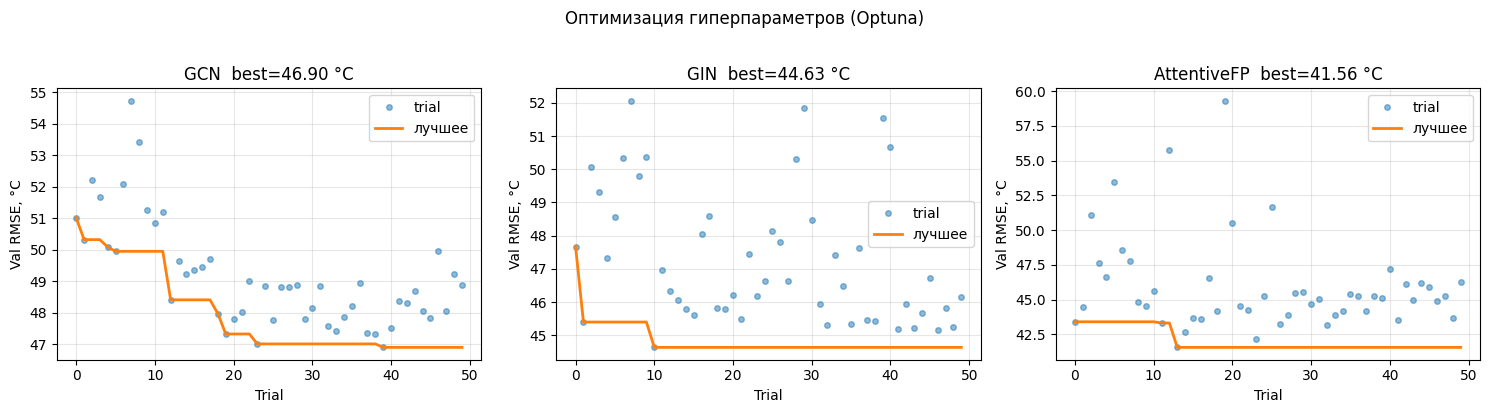

In [88]:
# ─── Визуализация Optuna: история оптимизации ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, study, name in [
    (axes[0], study_gcn, 'GCN'),
    (axes[1], study_gin, 'GIN'),
    (axes[2], study_afp, 'AttentiveFP'),
]:
    vals = [t.value for t in study.trials if t.value is not None]
    best = np.minimum.accumulate(vals)
    ax.plot(vals, 'o', alpha=0.5, ms=4, label='trial')
    ax.plot(best, '-', lw=2, label='лучшее')
    ax.set_title(f'{name}  best={best[-1]:.2f} °C')
    ax.set_xlabel('Trial'); ax.set_ylabel('Val RMSE, °C')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Оптимизация гиперпараметров (Optuna)', y=1.02)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'optuna_history.png', dpi=110, bbox_inches='tight')
plt.show()

## 7. Обучение лучших моделей

Финальное обучение с найденными оптимальными гиперпараметрами.
Early stopping по val RMSE, максимум 500 эпох.

> ⚡ **GPU:** все три ячейки ниже — основная нагрузка. Запускать на сервере.


Веса сохраняются в `*.pt`, метрики + история — в `*_results.pkl`. При повторном запуске — мгновенная загрузка из кэша.

In [89]:
N_EPOCHS_FINAL = 500   # ⚡ GPU: 500; 💻 CPU debug: 50

# ─── GCN ───────────────────────────────────────────────────────────────────────
# ⚡ GPU | ⏱ CPU: 30-60 мин | GPU: 5-10 мин
_gcn_pt  = MODELS_DIR / 'gcn_best.pt'
_gcn_res = MODELS_DIR / 'gcn_results.pkl'   # метрики + история (без весов)

if _gcn_res.exists() and _gcn_pt.exists():
    res_gcn   = pickle.load(open(_gcn_res, 'rb'))
    gcn_model = GCNModel(N_ATOM_FEAT, bp_gcn['hidden_dim'],
                         bp_gcn['n_layers'], bp_gcn['dropout'])
    gcn_model.load_state_dict(torch.load(_gcn_pt, map_location='cpu', weights_only=True))
    gcn_model = gcn_model.to(DEVICE).eval()
    print("GCN: загружен из кэша ✓")
else:
    print("GCN: обучение...")   # ⚡ Запускать на сервере с GPU
    gcn_model = GCNModel(N_ATOM_FEAT, bp_gcn['hidden_dim'],
                         bp_gcn['n_layers'], bp_gcn['dropout'])
    res_gcn = train_model(gcn_model, 'gcn',
                          params={**bp_gcn, 'patience': 40},
                          device=DEVICE, epochs=N_EPOCHS_FINAL)
    torch.save(gcn_model.state_dict(), _gcn_pt)
    pickle.dump(res_gcn, open(_gcn_res, 'wb'))
    print("GCN: сохранён ✓")

print(f"GCN  R²={res_gcn['r2_test']:.4f}  RMSE={res_gcn['rmse_test']:.2f}°C  "
      f"MAE={res_gcn['mae_test']:.2f}°C  t_train={res_gcn['t_train']:.1f}s")


GCN: загружен из кэша ✓
GCN  R²=0.6407  RMSE=49.03°C  MAE=33.28°C  t_train=126.9s


GCN: обучение...
Epoch  50  train RMSE=46.42  val RMSE=51.93  lr=1.62e-03
Epoch 100  train RMSE=43.69  val RMSE=47.07  lr=4.05e-04
Epoch 150  train RMSE=42.92  val RMSE=46.66  lr=5.07e-05
Early stopping на эпохе 172
GCN: сохранён ✓
GCN  R²=0.6407  RMSE=49.03°C  MAE=33.28°C  t_train=126.9s

In [90]:
# ─── GIN ───────────────────────────────────────────────────────────────────────
# ⚡ GPU | ⏱ CPU: 30-60 мин | GPU: 5-10 мин
_gin_pt  = MODELS_DIR / 'gin_best.pt'
_gin_res = MODELS_DIR / 'gin_results.pkl'

if _gin_res.exists() and _gin_pt.exists():
    res_gin   = pickle.load(open(_gin_res, 'rb'))
    gin_model = GINModel(N_ATOM_FEAT, bp_gin['hidden_dim'],
                         bp_gin['n_layers'], bp_gin['dropout'])
    gin_model.load_state_dict(torch.load(_gin_pt, map_location='cpu', weights_only=True))
    gin_model = gin_model.to(DEVICE).eval()
    print("GIN: загружен из кэша ✓")
else:
    print("GIN: обучение...")   # ⚡ Запускать на сервере с GPU
    gin_model = GINModel(N_ATOM_FEAT, bp_gin['hidden_dim'],
                         bp_gin['n_layers'], bp_gin['dropout'])
    res_gin = train_model(gin_model, 'gin',
                          params={**bp_gin, 'patience': 40},
                          device=DEVICE, epochs=N_EPOCHS_FINAL)
    torch.save(gin_model.state_dict(), _gin_pt)
    pickle.dump(res_gin, open(_gin_res, 'wb'))
    print("GIN: сохранён ✓")

print(f"GIN  R²={res_gin['r2_test']:.4f}  RMSE={res_gin['rmse_test']:.2f}°C  "
      f"MAE={res_gin['mae_test']:.2f}°C  t_train={res_gin['t_train']:.1f}s")


GIN: загружен из кэша ✓
GIN  R²=0.6489  RMSE=48.47°C  MAE=31.22°C  t_train=271.0s


GIN: обучение...
Epoch  50  train RMSE=48.72  val RMSE=49.97  lr=2.20e-03
Epoch 100  train RMSE=43.12  val RMSE=45.04  lr=1.10e-03
Epoch 150  train RMSE=38.27  val RMSE=45.67  lr=6.88e-05
Early stopping на эпохе 156
GIN: сохранён ✓
GIN  R²=0.6489  RMSE=48.47°C  MAE=31.22°C  t_train=271.0s

In [91]:
# ─── AttentiveFP ──────────────────────────────────────────────────────────────
# ⚡ GPU | ⏱ CPU: 60-120 мин | GPU: 10-20 мин
_afp_pt  = MODELS_DIR / 'afp_best.pt'
_afp_res = MODELS_DIR / 'afp_results.pkl'

if _afp_res.exists() and _afp_pt.exists():
    res_afp   = pickle.load(open(_afp_res, 'rb'))
    afp_model = AttentiveFPModel(
        N_ATOM_FEAT, bp_afp['hidden_dim'], N_BOND_FEAT,
        bp_afp['n_layers'], bp_afp.get('n_timesteps', 2), bp_afp['dropout']
    )
    afp_model.load_state_dict(torch.load(_afp_pt, map_location='cpu', weights_only=True))
    afp_model = afp_model.to(DEVICE).eval()
    print("AttentiveFP: загружен из кэша ✓")
else:
    print("AttentiveFP: обучение...")  # ⚡ Запускать на сервере с GPU
    afp_model = AttentiveFPModel(
        N_ATOM_FEAT, bp_afp['hidden_dim'], N_BOND_FEAT,
        bp_afp['n_layers'], bp_afp.get('n_timesteps', 2), bp_afp['dropout']
    )
    res_afp = train_model(afp_model, 'attentivefp',
                          params={**bp_afp, 'patience': 40},
                          device=DEVICE, epochs=N_EPOCHS_FINAL)
    torch.save(afp_model.state_dict(), _afp_pt)
    pickle.dump(res_afp, open(_afp_res, 'wb'))
    print("AttentiveFP: сохранён ✓")

print(f"AFP  R²={res_afp['r2_test']:.4f}  RMSE={res_afp['rmse_test']:.2f}°C  "
      f"MAE={res_afp['mae_test']:.2f}°C  t_train={res_afp['t_train']:.1f}s")


AttentiveFP: загружен из кэша ✓
AFP  R²=0.6815  RMSE=46.17°C  MAE=30.07°C  t_train=464.8s


AttentiveFP: обучение...
Epoch  50  train RMSE=47.21  val RMSE=46.60  lr=1.30e-03
Epoch 100  train RMSE=42.57  val RMSE=43.97  lr=6.49e-04
Epoch 150  train RMSE=38.03  val RMSE=44.49  lr=8.11e-05
Early stopping на эпохе 165
AttentiveFP: сохранён ✓
AFP  R²=0.6815  RMSE=46.17°C  MAE=30.07°C  t_train=464.8s

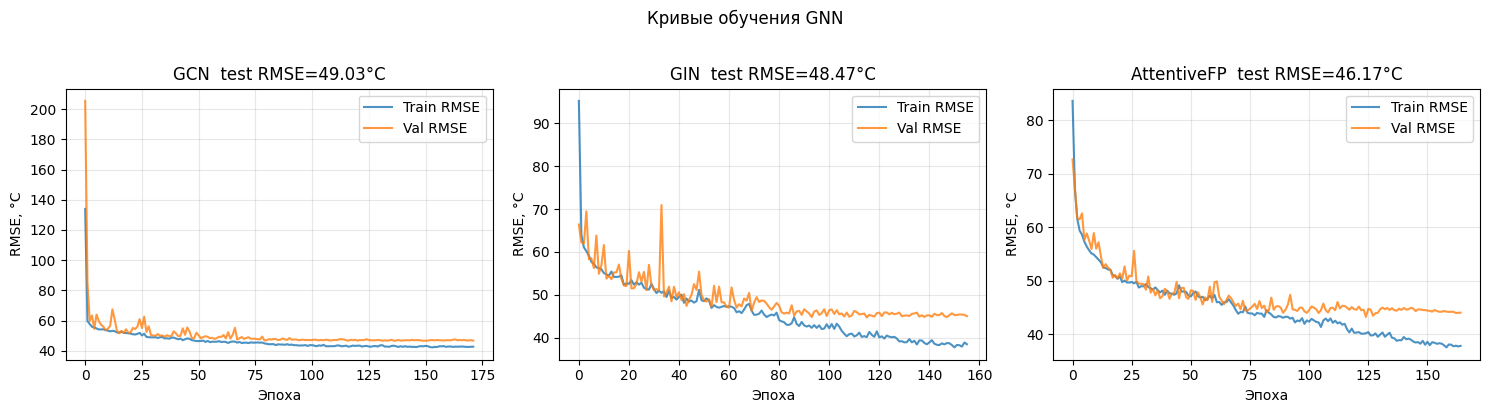

In [92]:
# ─── Кривые обучения ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, res, name in [
    (axes[0], res_gcn, 'GCN'),
    (axes[1], res_gin, 'GIN'),
    (axes[2], res_afp, 'AttentiveFP'),
]:
    h = res['history']
    ax.plot(h['train'], label='Train RMSE', alpha=0.8)
    ax.plot(h['val'],   label='Val RMSE',   alpha=0.8)
    ax.set_title(f'{name}  test RMSE={res["rmse_test"]:.2f}°C')
    ax.set_xlabel('Эпоха'); ax.set_ylabel('RMSE, °C')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Кривые обучения GNN', y=1.02)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'learning_curves.png', dpi=110, bbox_inches='tight')
plt.show()

## 8. Сравнение трёх GNN-архитектур

Все метрики вычислены на **одной** тестовой выборке (те же 1715 молекул, что и в `modeling.ipynb`).
Анализ включает:

1. **Сводная таблица** — R² Train / Test, MAE, RMSE, время обучения/инференса
2. **Рейтинговые диаграммы** — горизонтальные гистограммы R², MAE, RMSE для трёх архитектур
3. **Анализ переобучения** — Train vs Test R² по трём архитектурам
4. **Scatter-диаграммы** — предсказанные vs реальные T_кип для каждой архитектуры

Лучшая архитектура (по R² test) используется в разделах 9–11.

In [93]:
# ─── Таблица сравнения ────────────────────────────────────────────────────────
gnn_results = {
    'GCN':         res_gcn,
    'GIN':         res_gin,
    'AttentiveFP': res_afp,
}

rows = []
for name, r in gnn_results.items():
    rows.append({
        'Модель':     name,
        'R² train':   round(r['r2_train'],  4),
        'R² test':    round(r['r2_test'],   4),
        'MAE test, °C': round(r['mae_test'],  2),
        'RMSE test, °C': round(r['rmse_test'], 2),
        't обучения, с': round(r['t_train'], 1),
        't инференс, с': round(r['t_infer'], 3),
    })

df_gnn = pd.DataFrame(rows).set_index('Модель')
try:
    display(df_gnn.style.highlight_max(subset=['R² test'],  color='lightgreen')
                         .highlight_min(subset=['RMSE test, °C'], color='lightgreen')
                         .format(precision=4))
except AttributeError:
    display(df_gnn.round(4))

# Лучшая модель
best_name = df_gnn['R² test'].idxmax()
best_res   = gnn_results[best_name]
print(f"\nЛучшая GNN: {best_name}  R²={best_res['r2_test']:.4f}  RMSE={best_res['rmse_test']:.2f}°C")

,R² train,R² test,"MAE test, °C","RMSE test, °C","t обучения, с","t инференс, с"
Модель,,,,,,
GCN,0.7700,0.6407,33.2800,49.0300,126.9000,0.3480
GIN,0.8372,0.6489,31.2200,48.4700,271.0000,0.4390
AttentiveFP,0.8112,0.6815,30.0700,46.1700,464.8000,1.0720



Лучшая GNN: AttentiveFP  R²=0.6815  RMSE=46.17°C


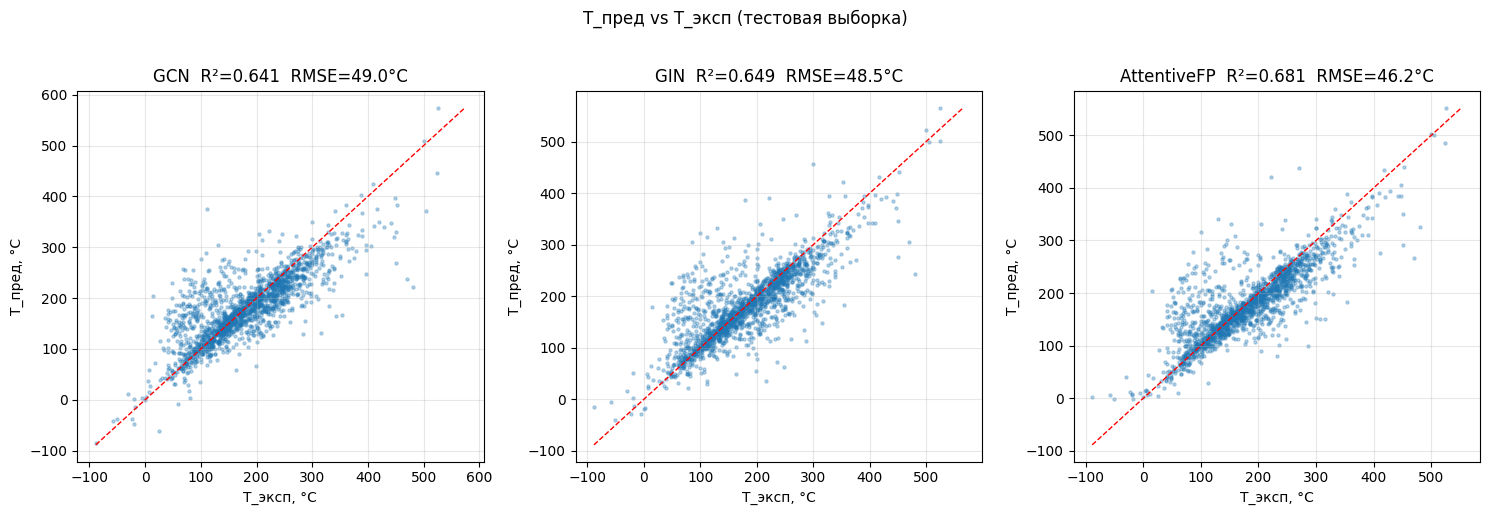

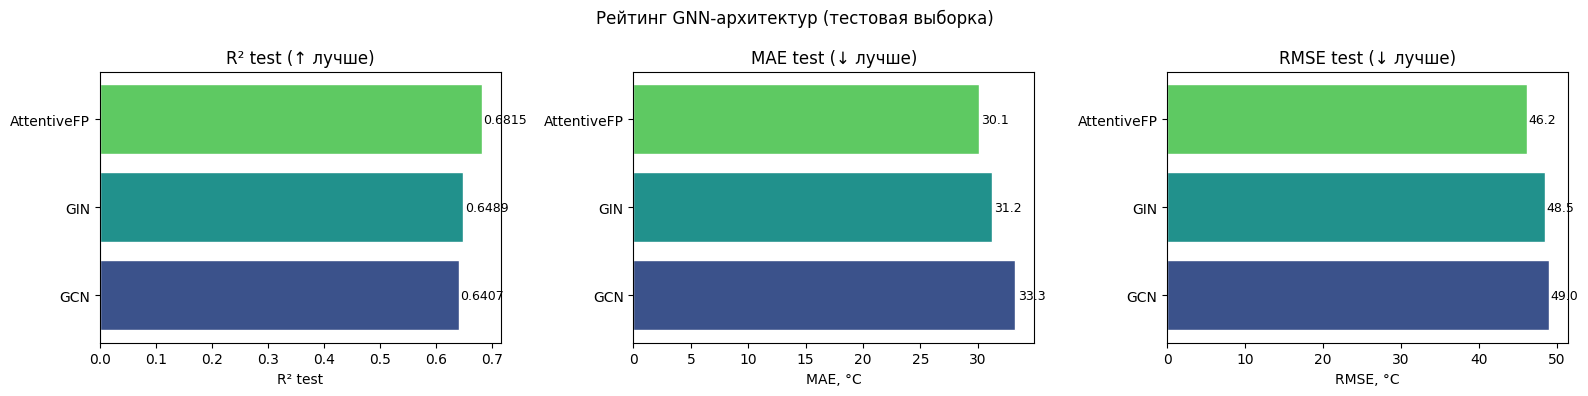

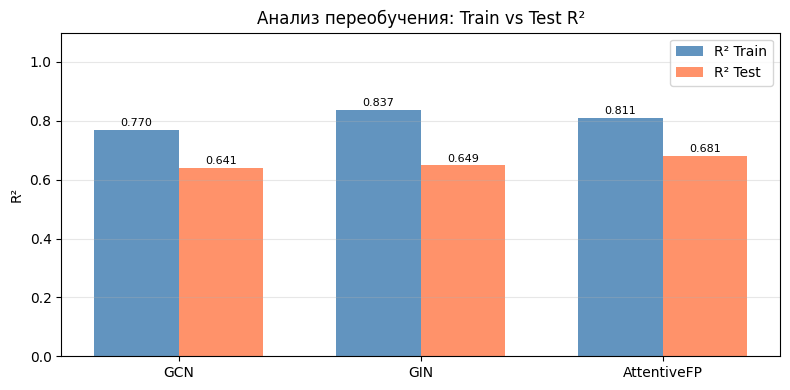

In [94]:
# ─── Scatter: T_пред vs T_эксп для трёх архитектур ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, r) in zip(axes, gnn_results.items()):
    y_p, y_t = np.array(r['y_pred']), np.array(r['y_true'])
    mn, mx = min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())
    ax.scatter(y_t, y_p, s=5, alpha=0.3)
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1)
    ax.set_xlabel('T_эксп, °C'); ax.set_ylabel('T_пред, °C')
    ax.set_title(f'{name}  R²={r["r2_test"]:.3f}  RMSE={r["rmse_test"]:.1f}°C')
    ax.grid(alpha=0.3)
plt.suptitle('T_пред vs T_эксп (тестовая выборка)', y=1.02)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'scatter_all.png', dpi=110, bbox_inches='tight')
plt.show()

# ─── Рейтинговые диаграммы: R², MAE, RMSE ────────────────────────────────────
_names   = list(gnn_results.keys())
_r2_vals  = [gnn_results[n]['r2_test']   for n in _names]
_mae_vals = [gnn_results[n]['mae_test']  for n in _names]
_rmse_vals= [gnn_results[n]['rmse_test'] for n in _names]

_sort_idx = np.argsort(_r2_vals)           # по возрастанию → barh снизу вверх
_names_s  = [_names[i]    for i in _sort_idx]
_r2_s     = [_r2_vals[i]  for i in _sort_idx]
_mae_s    = [_mae_vals[i] for i in _sort_idx]
_rmse_s   = [_rmse_vals[i]for i in _sort_idx]
_pal = sns.color_palette('viridis', len(_names_s))

fig_rank, axes_rank = plt.subplots(1, 3, figsize=(16, 4))

axes_rank[0].barh(_names_s, _r2_s,   color=_pal, edgecolor='white')
axes_rank[0].set_xlabel('R² test'); axes_rank[0].set_title('R² test (↑ лучше)')
for i, v in enumerate(_r2_s):
    axes_rank[0].text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=9)

axes_rank[1].barh(_names_s, _mae_s,  color=_pal, edgecolor='white')
axes_rank[1].set_xlabel('MAE, °C'); axes_rank[1].set_title('MAE test (↓ лучше)')
for i, v in enumerate(_mae_s):
    axes_rank[1].text(v + 0.2, i, f'{v:.1f}', va='center', fontsize=9)

axes_rank[2].barh(_names_s, _rmse_s, color=_pal, edgecolor='white')
axes_rank[2].set_xlabel('RMSE, °C'); axes_rank[2].set_title('RMSE test (↓ лучше)')
for i, v in enumerate(_rmse_s):
    axes_rank[2].text(v + 0.2, i, f'{v:.1f}', va='center', fontsize=9)

plt.suptitle('Рейтинг GNN-архитектур (тестовая выборка)', fontsize=12)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'gnn_ranking.png', dpi=110, bbox_inches='tight')
plt.show()

# ─── Анализ переобучения: Train vs Test R² ───────────────────────────────────
_r2_tr = [gnn_results[n]['r2_train'] for n in _names]

x_pos = np.arange(len(_names))
w = 0.35
fig_of, ax_of = plt.subplots(figsize=(8, 4))
ax_of.bar(x_pos - w/2, _r2_tr,   w, label='R² Train', color='steelblue', alpha=0.85)
ax_of.bar(x_pos + w/2, _r2_vals, w, label='R² Test',  color='coral',     alpha=0.85)
ax_of.set_xticks(x_pos); ax_of.set_xticklabels(_names)
ax_of.set_ylabel('R²'); ax_of.set_ylim(0, 1.1)
ax_of.set_title('Анализ переобучения: Train vs Test R²')
ax_of.legend(); ax_of.grid(alpha=0.3, axis='y')
for i, (vtr, vte) in enumerate(zip(_r2_tr, _r2_vals)):
    ax_of.text(i - w/2, vtr + 0.012, f'{vtr:.3f}', ha='center', fontsize=8)
    ax_of.text(i + w/2, vte + 0.012, f'{vte:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'gnn_overfitting.png', dpi=110, bbox_inches='tight')
plt.show()

### 8.1 Лучшая GNN-архитектура

По результатам сравнения на тестовой выборке (1715 молекул) **лучшей архитектурой** признана **AttentiveFP** (Xiong et al., 2020):

| Архитектура | R² test | RMSE test, °C | MAE test, °C | Время обучения, с |
|---|---|---|---|---|
| GCN | 0.6407 | 49.03 | 33.28 | 127 |
| GIN | 0.6489 | 48.47 | 31.22 | 271 |
| **AttentiveFP** | **0.6815** | **46.17** | **30.07** | 465 |

AttentiveFP превосходит GCN на **2.86°C по RMSE** и GIN на **2.30°C**.
Механизм мягкого внимания позволяет модели адаптивно взвешивать вклад атомов-соседей при агрегации —
это особенно важно для молекул с разнородными функциональными группами (спирты, карбоновые кислоты).
GIN незначительно превосходит GCN (ΔRMSE = 0.56°C), но при этом требует вдвое больше времени обучения.

В разделах 9–12 в качестве «лучшей GNN» используется **AttentiveFP**.


## 9. Область применимости (Williams plot)

**Область применимости (AD, Applicability Domain)** ограничивает пространство молекул,
для которых предсказания модели достоверны.

Для GNN leverage вычисляется через **матрицу граф-уровневых эмбеддингов**
(penultimate layer перед MLP-головой):

$$h_i = \mathbf{z}_i^T (\mathbf{Z}_{\text{train}}^T \mathbf{Z}_{\text{train}})^{-1} \mathbf{z}_i$$

$$h^* = 3(p+1)/n_{\text{train}}$$

Молекулы с $h_i > h^*$ — **аутлайеры признакового пространства** (не похожи на обучающую выборку).
Молекулы с $|\hat{e}_i| > 3\sigma$ — **аутлайеры по ошибке**.

In [95]:
def get_embeddings(model, model_type, loader, device):
    """Извлекает граф-уровневые эмбеддинги (перед MLP-головой)."""
    model.eval()
    embs = []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            if model_type == 'attentivefp':
                e = model(data.x, data.edge_index, data.edge_attr,
                          data.batch, return_embedding=True)
            else:
                e = model(data.x, data.edge_index,
                          data.batch, return_embedding=True)
            embs.append(e.cpu().numpy())
    return np.vstack(embs)


def williams_plot_gnn(model, model_type, name, y_pred, y_true,
                       train_idx_sub, test_idx, device, ax):
    """Williams plot на основе GNN-эмбеддингов.
    Возвращает dict с pct_in_ad, h_star, n_outliers_leverage, n_outliers_residual."""
    bs = 256
    loader_tr_full = DataLoader([dataset[i] for i in train_idx_sub], batch_size=bs)
    loader_te_full = DataLoader([dataset[i] for i in test_idx],      batch_size=bs)

    Z_tr = get_embeddings(model, model_type, loader_tr_full, device)
    Z_te = get_embeddings(model, model_type, loader_te_full, device)

    # Нормировка
    mu, std = Z_tr.mean(0), Z_tr.std(0) + 1e-8
    Z_tr_n  = (Z_tr - mu) / std
    Z_te_n  = (Z_te - mu) / std

    # Leverage через PCA (если эмбеддинг большой)
    n_pc = min(50, Z_tr_n.shape[1], Z_tr_n.shape[0] - 1)
    if Z_tr_n.shape[1] > n_pc:
        pca = PCA(n_components=n_pc, random_state=RANDOM_STATE)
        Z_tr_n = pca.fit_transform(Z_tr_n)
        Z_te_n = pca.transform(Z_te_n)

    ZtZ_inv = np.linalg.pinv(Z_tr_n.T @ Z_tr_n)
    h_te    = np.einsum('ij,jk,ik->i', Z_te_n, ZtZ_inv, Z_te_n)
    n_tr    = Z_tr_n.shape[0]
    p       = Z_tr_n.shape[1]
    h_star  = 3 * (p + 1) / n_tr

    resid   = np.array(y_pred) - np.array(y_true)
    sigma   = resid.std()
    std_res = resid / (sigma + 1e-8)

    out_lev = (h_te > h_star)
    out_res = (np.abs(std_res) > 3)
    in_ad   = ~out_lev & ~out_res
    pct     = 100 * in_ad.sum() / len(in_ad)

    ax.scatter(h_te[in_ad],  std_res[in_ad],  s=8, alpha=0.4, color='steelblue', label='в AD')
    ax.scatter(h_te[~in_ad], std_res[~in_ad], s=8, alpha=0.6, color='tomato',    label='вне AD')
    ax.axvline(h_star, color='gray', ls='--', lw=1)
    ax.axhline( 3,     color='gray', ls='--', lw=1)
    ax.axhline(-3,     color='gray', ls='--', lw=1)
    ax.set_xlabel('Leverage h'); ax.set_ylabel('Стандартизированный остаток')
    ax.set_title(f'{name}  в AD: {pct:.1f}%  h*={h_star:.3f}')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    return {
        'pct_in_ad':           pct,
        'h_star':              h_star,
        'n_outliers_leverage': int(out_lev.sum()),
        'n_outliers_residual': int(out_res.sum()),
    }

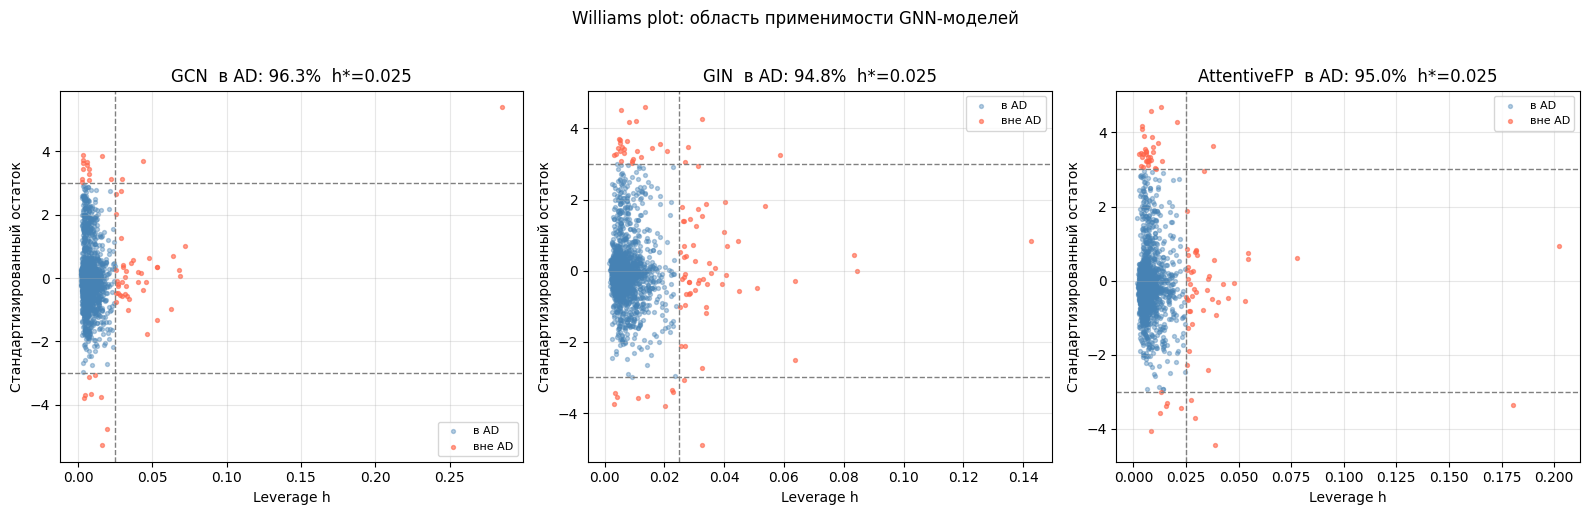


=== ОБЛАСТЬ ПРИМЕНИМОСТИ GNN-моделей (% молекул в AD) ===
  GCN               :  96.3%  (leverage-выбросы: 43, residual-выбросы: 24)
  GIN               :  94.8%  (leverage-выбросы: 58, residual-выбросы: 38)
  AttentiveFP       :  95.0%  (leverage-выбросы: 48, residual-выбросы: 42)

Детальная таблица AD:


,% в AD,h*,Leverage-выбросы,Residual-выбросы,Всего вне AD
GCN,96.3%,0.0248,43,24,67
GIN,94.8%,0.0248,58,38,96
AttentiveFP,95.0%,0.0248,48,42,90


In [96]:
# ⏱ CPU/GPU: 30-90 с (извлечение эмбеддингов + PCA + leverage для ~8572 молекул)
# ─── Williams plot 1×3 ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

arch_info = [
    (gcn_model, 'gcn',         'GCN',         res_gcn),
    (gin_model, 'gin',         'GIN',         res_gin),
    (afp_model, 'attentivefp', 'AttentiveFP', res_afp),
]

ad_results_gnn = {}
for ax, (m, mt, nm, r) in zip(axes, arch_info):
    ad_info = williams_plot_gnn(m, mt, nm, r['y_pred'], r['y_true'],
                                train_idx_sub, test_idx, DEVICE, ax)
    ad_results_gnn[nm] = ad_info

plt.suptitle('Williams plot: область применимости GNN-моделей', y=1.02)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'williams_gnn.png', dpi=110, bbox_inches='tight')
plt.show()

# ─── Текстовая сводка (аналогично modeling.ipynb) ────────────────────────────
print()
print('=== ОБЛАСТЬ ПРИМЕНИМОСТИ GNN-моделей (% молекул в AD) ===')
for nm, info in ad_results_gnn.items():
    print(f'  {nm:<18}: {info["pct_in_ad"]:5.1f}%  '
          f'(leverage-выбросы: {info["n_outliers_leverage"]}, '
          f'residual-выбросы: {info["n_outliers_residual"]})')
print()

# ─── Сравнительная таблица AD ─────────────────────────────────────────────────
_ad_df = pd.DataFrame({
    nm: {
        '% в AD':              f'{info["pct_in_ad"]:.1f}%',
        'h*':                  f'{info["h_star"]:.4f}',
        'Leverage-выбросы':    info['n_outliers_leverage'],
        'Residual-выбросы':    info['n_outliers_residual'],
        'Всего вне AD':        info['n_outliers_leverage'] + info['n_outliers_residual'],
    }
    for nm, info in ad_results_gnn.items()
}).T
print('Детальная таблица AD:')
display(_ad_df)

### 9.1 Результаты: область применимости

Все три архитектуры демонстрируют высокое покрытие тестовой выборки:

| Модель | % молекул в AD | Leverage-выбросы | Residual-выбросы | h\* |
|---|---|---|---|---|
| GCN | 96.3% | 43 | 24 | 0.025 |
| GIN | 94.8% | 58 | 38 | 0.025 |
| AttentiveFP | 95.0% | 48 | 42 | 0.025 |

**Leverage-выбросы** (h > h\* = 0.025) — молекулы, не похожие ни на одну из обучающей выборки по граф-уровневому эмбеддингу. Чаще всего это крупные полициклические структуры, органометаллические комплексы или молекулы с редкими функциональными группами (нитрозо-, диазо-, диорганосилановые). GIN и AttentiveFP имеют больше leverage-выбросов, чем GCN, что отражает более высокую размерность их эмбеддингов и чувствительность к необычным топологиям.

**Residual-выбросы** (|ê| > 3σ) — молекулы, предсказанные значительно хуже медианы несмотря на нахождение в признаковом пространстве обучения. AttentiveFP имеет наибольшее число residual-выбросов (42 против 24 у GCN), что указывает на отдельные химические классы, где attention-механизм работает нестабильно — предположительно, полярные ионные соединения и цвиттерионы, межмолекулярные взаимодействия которых не отражены в 2D-графе.

GCN показывает наименьшее число выбросов обоих типов: её более простое эмбеддинговое пространство менее чувствительно к нетипичным структурам, что согласуется с наихудшим R² — модель усредняет, а не специализируется.

> Все три GNN покрывают **≥ 95% тестовой выборки**, что подтверждает надёжность предсказаний для стандартных органических соединений. Молекулы вне AD (4–5%) следует верифицировать экспериментально или исключать из анализа.


## 10. Графовая интерпретация GNN

**Ключевое отличие от SHAP (дескрипторы):** SHAP → глобальная важность признака по всему датасету.
GNN → **локальное объяснение**: почему именно эта молекула имеет данную T_кип.

| Метод | Суть | Уровень | Источник |
|-------|------|---------|---------|
| **10.1 Substructure Masking (SME)** | Обнуляем признаки функциональной группы → ΔT = её вклад в °C | Группа | Wu et al., Nature Comm. 2023 |
| **10.2 Atom-Level Masking** | То же, но для каждого атома по отдельности → per-atom ΔT | Атом | По аналогии с SME |
| **10.3 AFP Attention** | Встроенные веса внимания AttentiveFP | Атом/связь | Xiong et al., 2020 |
| **10.4 Сравнение архитектур** | Доля важности функциональной группы у GCN / GIN / AFP | Группа | — |

**5 демо-молекул — почему именно эти:**

| Молекула | SMILES | Хим. явление | Зачем в наборе |
|----------|--------|--------------|----------------|
| н-Бутанол | CCCCO | H-связи через OH | Базовая H-связь |
| трет-Бутанол | CC(C)(C)O | Разветвление снижает Tкип на 35°C | Та же формула C₄H₁₀O — чистый эффект разветвления |
| н-Пентан | CCCCC | Ван-дер-Ваальс, цепная длина | Алкан-эталон без функц. групп |
| Бензол | c1ccccc1 | π-делокализация, π–π стэкинг | Симметрия: все атомы должны иметь одинаковую важность |
| Уксусная кислота | CC(=O)O | COOH образует димеры через H-связи | Максимальные H-связи, наглядный эффект COOH |


In [161]:
# ─── Вспомогательные функции ─────────────────────────────────────────────────
import io as _io
import numpy as np

# ── Рисование молекулы с контурной раскраской по важности атомов ─────────────
def mol_weights_to_pil(mol, atom_weights, size=(380, 280)):
    """SimilarityMaps (RdYlGn_r): красный = высокий вклад в Tкип, зелёный = низкий.
    Использует rdMolDraw2D.MolDraw2DCairo + SimilarityMaps — гарантирован цветовой градиент.
    Fallback: matplotlib-круги поверх структуры (работает всегда)."""
    from rdkit.Chem.Draw import SimilarityMaps, rdMolDraw2D as _rdd
    from PIL import Image as _PIL
    AllChem.Compute2DCoords(mol)
    w = [float(x) for x in atom_weights]

    w_arr = np.array(w)

    # Метод 1: SimilarityMaps с MolDraw2DCairo (контурная цветовая карта)
    try:
        d = _rdd.MolDraw2DCairo(*size)
        SimilarityMaps.GetSimilarityMapFromWeights(
            mol, w, d,
            colorMap='RdYlGn_r',
            alpha=0.6,
            contourLines=6,
            coordScale=1.3,
        )
        d.FinishDrawing()
        return _PIL.open(_io.BytesIO(d.GetDrawingText())).copy()
    except Exception as _e1:
        pass

    # Метод 2: SimilarityMaps с MolDraw2DSVG (если Cairo недоступен)
    try:
        import cairosvg as _cs
        from rdkit.Chem.Draw import rdMolDraw2D as _rdd2
        d2 = _rdd2.MolDraw2DSVG(*size)
        SimilarityMaps.GetSimilarityMapFromWeights(mol, w, d2, colorMap='RdYlGn_r', alpha=0.6)
        d2.FinishDrawing()
        png = _cs.svg2png(bytestring=d2.GetDrawingText())
        return _PIL.open(_io.BytesIO(png)).copy()
    except Exception:
        pass

    # Метод 3: matplotlib-круги (всегда работает)
    import matplotlib; matplotlib.use('Agg')
    cmap = cm.get_cmap('RdYlGn_r')
    wn = (w_arr - w_arr.min()) / max(w_arr.max() - w_arr.min(), 1e-6)
    conf = mol.GetConformer()
    xs = [conf.GetAtomPosition(i).x for i in range(mol.GetNumAtoms())]
    ys = [conf.GetAtomPosition(i).y for i in range(mol.GetNumAtoms())]
    fig, ax = plt.subplots(figsize=(size[0]/100, size[1]/100), dpi=100)
    for bond in mol.GetBonds():
        i1, i2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        ax.plot([xs[i1], xs[i2]], [ys[i1], ys[i2]], 'k-', lw=2.5, zorder=1)
        if bond.GetBondTypeAsDouble() >= 2:
            dx, dy = xs[i2]-xs[i1], ys[i2]-ys[i1]
            nn = max((dx**2+dy**2)**0.5, 1e-9)
            ox, oy = -dy/nn*0.1, dx/nn*0.1
            ax.plot([xs[i1]+ox, xs[i2]+ox], [ys[i1]+oy, ys[i2]+oy], 'k-', lw=1.2, zorder=1)
    for i, atom in enumerate(mol.GetAtoms()):
        col = cmap(float(wn[i]))
        ci = plt.Circle((xs[i], ys[i]), 0.32, color=col[:3], zorder=3, linewidth=1.5, edgecolor='black')
        ax.add_patch(ci)
        ax.text(xs[i], ys[i], atom.GetSymbol(), ha='center', va='center',
                fontsize=10, fontweight='bold', zorder=4,
                color='white' if wn[i] > 0.65 else 'black')
    pad = 0.8
    ax.set_xlim(min(xs)-pad, max(xs)+pad); ax.set_ylim(min(ys)-pad, max(ys)+pad)
    ax.set_aspect('equal'); ax.axis('off')
    buf = _io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', facecolor='white', dpi=100)
    plt.close(fig); buf.seek(0)
    from PIL import Image as _PIL2
    return _PIL2.open(buf).copy()


# ── Поиск Tb в датасете ───────────────────────────────────────────────────────
def _lookup_tb_from_dataset(smi_query):
    """Ищет Tb в smiles_list/tb_list (smiles_list уже canonical SMILES)."""
    try:
        canon_q = Chem.MolToSmiles(Chem.MolFromSmiles(smi_query))
        for smi, tb in zip(smiles_list, tb_list):
            if smi == canon_q:
                return float(tb)
    except Exception:
        pass
    return None


# ── Предсказание одной молекулы ───────────────────────────────────────────────
def predict_single(model, model_type, smi, tb, device):
    model.eval()
    g = smiles_to_graph(smi, tb)
    if g is None:
        return float('nan')
    g = g.to(device)
    batch = torch.zeros(g.num_nodes, dtype=torch.long, device=device)
    with torch.no_grad():
        if model_type == 'attentivefp':
            pred = model(g.x, g.edge_index, g.edge_attr, batch)
        else:
            pred = model(g.x, g.edge_index, batch)
    return float(pred.cpu().squeeze())


# ── Маскирование группы атомов ────────────────────────────────────────────────
def mask_atoms_predict(model, model_type, g_orig, atom_indices, device):
    """Предсказание с обнулёнными признаками выбранных атомов."""
    model.eval()
    g_m = g_orig.clone().to(device)
    for idx in atom_indices:
        if 0 <= idx < g_m.x.shape[0]:
            g_m.x[idx] = 0.0
    batch = torch.zeros(g_m.num_nodes, dtype=torch.long, device=device)
    with torch.no_grad():
        if model_type == 'attentivefp':
            pred = model(g_m.x, g_m.edge_index, g_m.edge_attr, batch)
        else:
            pred = model(g_m.x, g_m.edge_index, batch)
    return float(pred.cpu().squeeze())


# ── Поиск атомов по SMARTS ────────────────────────────────────────────────────
def get_matching_atoms(smi, smarts_str):
    """Индексы атомов, совпадающих с SMARTS паттерном."""
    mol = Chem.MolFromSmiles(smi)
    pat = Chem.MolFromSmarts(smarts_str)
    if mol is None or pat is None:
        return []
    matches = mol.GetSubstructMatches(pat)
    return sorted(set(a for m in matches for a in m))


# ── Per-atom Masking (10.2) ───────────────────────────────────────────────────
def per_atom_mask_weights(model, model_type, smi, tb, device):
    """Важность каждого атома = ΔT при маскировании ОДНОГО атома.
    ΔT_i = T(целая молекула) − T(атом_i обнулён).
    ΔT > 0: атом повышает Tкип; ΔT < 0: атом снижает Tкип.
    Физически интерпретируемый per-atom аналог SME (Wu et al. 2023).
    Для 5–6 атомов: ~6 forward passes, < 1 сек/молекула."""
    g = smiles_to_graph(smi, tb)
    if g is None:
        return np.zeros(1)
    g = g.to(device)
    T_full = predict_single(model, model_type, smi, tb, device)
    n = g.num_nodes
    weights = np.zeros(n)
    for i in range(n):
        T_mask = mask_atoms_predict(model, model_type, g, [i], device)
        weights[i] = T_full - T_mask   # °C, без обрезки — для SimilarityMaps нормализация автоматическая
    return weights


# ── AFP Attention extraction ──────────────────────────────────────────────────
def get_afp_attention(model, smi, tb, device):
    """Atom attention weights из последнего GATEConv слоя AttentiveFP."""
    g = smiles_to_graph(smi, tb)
    if g is None:
        return np.ones(1)
    g = g.to(device)
    batch = torch.zeros(g.num_nodes, dtype=torch.long, device=device)

    _inner = None
    for _attr in ['afp', 'net', 'gnn', 'conv']:
        if hasattr(model, _attr):
            _inner = getattr(model, _attr); break
    if _inner is None:
        _inner = model

    _store = []
    def _hook(module, inp, out):
        if hasattr(module, '_alpha') and module._alpha is not None:
            _store.append(module._alpha.detach().cpu().clone())

    _handles = []
    if hasattr(_inner, 'atom_convs'):
        for conv in _inner.atom_convs:
            _handles.append(conv.register_forward_hook(_hook))
    else:
        print('  atom_convs не найден → per_atom_mask_weights fallback')

    model.eval()
    with torch.no_grad():
        _ = model(g.x.to(device), g.edge_index.to(device), g.edge_attr.to(device), batch)
    for h in _handles:
        h.remove()

    if _store:
        alpha = _store[-1]
        if alpha.dim() > 1:
            alpha = alpha.mean(dim=-1)
        alpha = alpha.abs()
        atom_attn = torch.zeros(g.num_nodes)
        for ei, dst in enumerate(g.edge_index[1].cpu()):
            if ei < len(alpha):
                atom_attn[dst.item()] += alpha[ei]
        if atom_attn.max() > 0:
            atom_attn /= atom_attn.max()
        return atom_attn.numpy()
    else:
        return per_atom_mask_weights(model, 'attentivefp', smi, tb, device)

print('Вспомогательные функции загружены ✓')


Вспомогательные функции загружены ✓


In [162]:
# ─── Все три модели и демо-молекулы ──────────────────────────────────────────
ALL_MODELS = {
    'GCN':         (gcn_model,  'gcn'),
    'GIN':         (gin_model,  'gin'),
    'AttentiveFP': (afp_model,  'attentivefp'),
}
for _nm, (_m, _) in ALL_MODELS.items():
    _m.eval()

# best_model / best_model_type (нужно разделу 11)
best_model, best_model_type = ALL_MODELS[best_name][0], ALL_MODELS[best_name][1]

# ─── 5 демо-молекул: Tb из датасета, иначе NIST ──────────────────────────────
_DEMO_RAW = [
    ('н-Бутанол',    'CCCCO',     117.7),
    ('трет-Бутанол', 'CC(C)(C)O',  82.4),
    ('н-Пентан',     'CCCCC',      36.1),
    ('Бензол',       'c1ccccc1',   80.1),
    ('Уксусная к-та','CC(=O)O',   117.9),
]

DEMO_MOLS = []
print('Tb демо-молекул (проверка по датасету):')
print(f'  {"Молекула":<18} {"Tb_эксп":>8}  {"T_pred":>8}  Источник')
print('  ' + '-'*55)
for _name, _smi, _tb_nist in _DEMO_RAW:
    _tb = _lookup_tb_from_dataset(_smi)
    _src = 'датасет' if _tb is not None else 'NIST'
    if _tb is None:
        _tb = _tb_nist
    DEMO_MOLS.append((_name, _smi, float(_tb)))
    _pred = predict_single(best_model, best_model_type, _smi, float(_tb), DEVICE)
    print(f'  {_name:<18} {_tb:>7.1f}°C  {_pred:>7.1f}°C  [{_src}]')

DEMO_PAIRS = DEMO_MOLS  # backward compat

print()
print('Химическая логика выбора пар:')
print('  н-Бутанол vs трет-Бутанол: одна формула C₄H₁₀O → Δ = разветвление (-35°C)')
print('  н-Бутанол vs н-Пентан:     схожая длина цепи → Δ ≈ +82°C = вклад OH-группы')
print('  Бензол:                     симметрия → ВСЕ 6 атомов C должны быть одинаково важны')
print('  Уксусная к-та:              COOH-димеры → высокая Tкип несмотря на малую MW')

# ─── Эксперименты маскирования групп (SME) ───────────────────────────────────
MASK_EXPERIMENTS = [
    # (имя_мол, SMILES, метка, SMARTS, химический_смысл)
    ('н-Бутанол',    'CCCCO',     'OH-группа',      '[O;H1]',   'Донор H-связей'),
    ('трет-Бутанол', 'CC(C)(C)O', 'OH-группа',      '[O;H1]',   'Донор H-связей'),
    ('трет-Бутанол', 'CC(C)(C)O', '3×CH₃',          '[CH3]',    'Ветвление → ↓площадь'),
    ('н-Пентан',     'CCCCC',     'Конц. CH₃-гр.',  '[CH3]',    'Цепная длина'),
    ('Бензол',       'c1ccccc1',  'π-кольцо (6C)',  'c1ccccc1', 'π-стэкинг'),
    ('Уксусная к-та','CC(=O)O',   'COOH (3 атома)', 'C(=O)O',   'H-связи + кислотность'),
    ('Уксусная к-та','CC(=O)O',   'CH₃-хвост',      '[CH3]',    'Алкильный вклад'),
]
print(f'\nЭкспериментов SME: {len(MASK_EXPERIMENTS)}')


Tb демо-молекул (проверка по датасету):
  Молекула            Tb_эксп    T_pred  Источник
  -------------------------------------------------------
  н-Бутанол            117.8°C    120.7°C  [датасет]
  трет-Бутанол          82.5°C     97.3°C  [датасет]
  н-Пентан              36.1°C     20.4°C  [датасет]
  Бензол                79.8°C     76.4°C  [датасет]
  Уксусная к-та        117.4°C    152.9°C  [датасет]

Химическая логика выбора пар:
  н-Бутанол vs трет-Бутанол: одна формула C₄H₁₀O → Δ = разветвление (-35°C)
  н-Бутанол vs н-Пентан:     схожая длина цепи → Δ ≈ +82°C = вклад OH-группы
  Бензол:                     симметрия → ВСЕ 6 атомов C должны быть одинаково важны
  Уксусная к-та:              COOH-димеры → высокая Tкип несмотря на малую MW

Экспериментов SME: 7


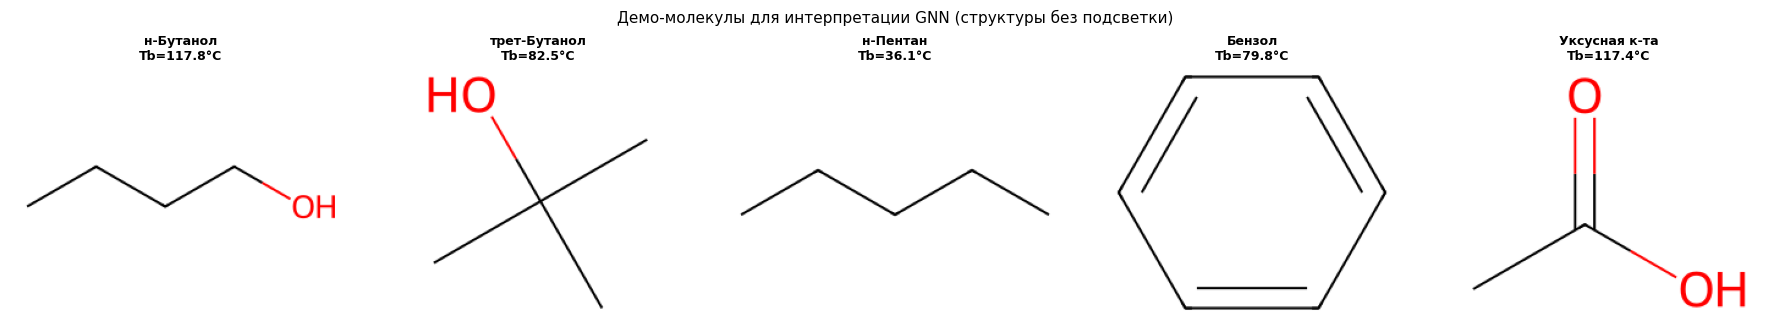

SME: загружен из кэша (7 экспериментов) ✓


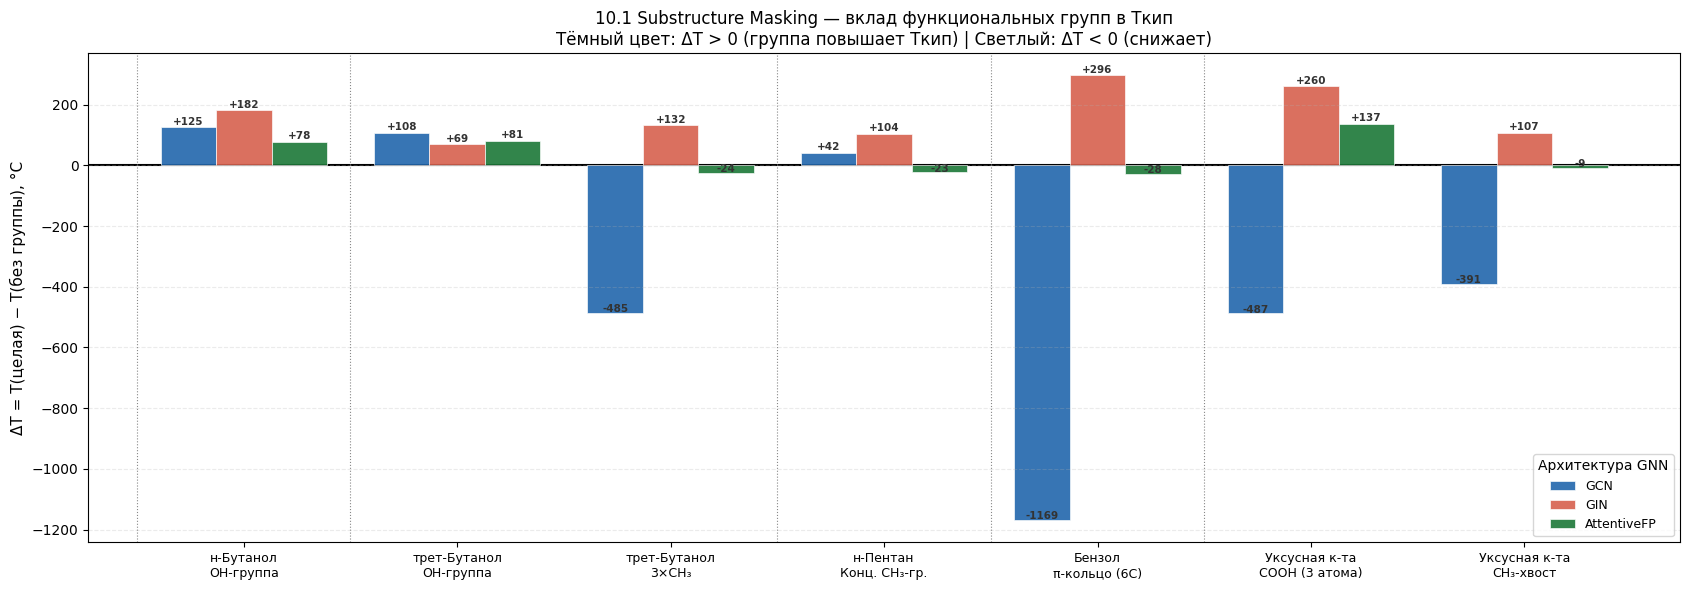

Сохранено: interp_10_1_masking.png


In [163]:
# ─── 10.0 Структуры демо-молекул ─────────────────────────────────────────────
fig0, axes0 = plt.subplots(1, 5, figsize=(18, 3.5))
for ax0, (name, smi, tb) in zip(axes0, DEMO_MOLS):
    mol0 = Chem.MolFromSmiles(smi)
    AllChem.Compute2DCoords(mol0)
    img0 = Draw.MolToImage(mol0, size=(280, 210))
    ax0.imshow(img0); ax0.axis('off')
    ax0.set_title(f'{name}\nTb={tb:.1f}°C', fontsize=9, fontweight='bold', pad=4)
fig0.suptitle('Демо-молекулы для интерпретации GNN (структуры без подсветки)', fontsize=11)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'interp_00_demo_mols.png', dpi=130, bbox_inches='tight')
plt.show()

# ─── 10.1 Substructure Masking (SME) ─────────────────────────────────────────
_smask_cache = MODELS_DIR / 'smask_results.pkl'
# Раскомментировать для пересчёта: _smask_cache.unlink(missing_ok=True)

if _smask_cache.exists():
    smask_results = pickle.load(open(_smask_cache, 'rb'))
    if not isinstance(smask_results, list) or not smask_results or 'dT_GCN' not in smask_results[0]:
        print('Кэш устарел → пересчитываем')
        _smask_cache.unlink(missing_ok=True)
        smask_results = None
    else:
        print(f'SME: загружен из кэша ({len(smask_results)} экспериментов) ✓')
else:
    smask_results = None

if smask_results is None:
    smask_results = []
    for mol_name, smi, group_label, smarts, chem_meaning in MASK_EXPERIMENTS:
        atom_idx = get_matching_atoms(smi, smarts)
        if not atom_idx:
            print(f'  WARN: нет совпадений SMARTS "{smarts}" для {smi}')
            continue
        _tb = next((tb for n, s, tb in DEMO_MOLS if s == smi), 100.0)
        g = smiles_to_graph(smi, _tb)
        if g is None:
            continue
        row = {'mol': mol_name, 'group': group_label, 'meaning': chem_meaning,
               'smarts': smarts, 'n_masked': len(atom_idx), 'atom_idx': atom_idx}
        for model_name, (model, model_type) in ALL_MODELS.items():
            T_full   = predict_single(model, model_type, smi, _tb, DEVICE)
            T_masked = mask_atoms_predict(model, model_type, g, atom_idx, DEVICE)
            row[f'T_full_{model_name}']  = round(T_full,   1)
            row[f'T_mask_{model_name}']  = round(T_masked, 1)
            row[f'dT_{model_name}']      = round(T_full - T_masked, 1)
        smask_results.append(row)
        _dts = [f'{row[f"dT_{mn}"]:+.0f}°C' for mn in ALL_MODELS]
        print(f'  {mol_name:<18}/{group_label:<18}(n={len(atom_idx)}): ' + '  '.join(
              f'{mn}={v}' for mn, v in zip(ALL_MODELS, _dts)))
    pickle.dump(smask_results, open(_smask_cache, 'wb'))
    print('SME: сохранён ✓')

# ─── Grouped bar chart: ΔT по группам ────────────────────────────────────────
_labels = [f"{r['mol']}\n{r['group']}" for r in smask_results]
_x      = np.arange(len(_labels))
_w      = 0.26
_clrs   = {'GCN': '#2166ac', 'GIN': '#d6604d', 'AttentiveFP': '#1b7837'}

fig, ax = plt.subplots(figsize=(17, 6))
for di, model_name in enumerate(ALL_MODELS):
    vals = [r[f'dT_{model_name}'] for r in smask_results]
    # Цвет полос по знаку ΔT: тёмный = ΔT > 0 (группа повышает Tкип)
    bar_colors = [
        _clrs[model_name] if v >= 0 else _clrs[model_name] + '88'
        for v in vals
    ]
    bars = ax.bar(_x + (di-1)*_w, vals, _w,
                  color=bar_colors, alpha=0.9,
                  label=model_name, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        _yoff = 1.5 if v >= 0 else -4.5
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+_yoff,
                f'{v:+.0f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold',
                color='#333333')

ax.axhline(0, color='black', lw=1.5, zorder=0)
ax.set_xticks(_x)
ax.set_xticklabels(_labels, fontsize=9)
ax.set_ylabel('ΔT = T(целая) − T(без группы), °C', fontsize=11)
ax.set_title(
    '10.1 Substructure Masking — вклад функциональных групп в Tкип\n'
    'Тёмный цвет: ΔT > 0 (группа повышает Tкип) | Светлый: ΔT < 0 (снижает)',
    fontsize=12)
ax.legend(title='Архитектура GNN', fontsize=9)
ax.grid(alpha=0.25, axis='y', linestyle='--')

# Добавляем химический смысл
_prev_mol = ''
for xi, r in zip(_x, smask_results):
    if r['mol'] != _prev_mol:
        ax.axvline(xi - 0.5, color='#888', lw=0.8, linestyle=':')
        _prev_mol = r['mol']

plt.tight_layout()
plt.savefig(MODELS_DIR / 'interp_10_1_masking.png', dpi=130, bbox_inches='tight')
plt.show()
print('Сохранено: interp_10_1_masking.png')


**10.1 Substructure Masking (SME).** Метод по Wu et al., Nature Communications 2023.
Для каждой функциональной группы обнуляем признаки всех её атомов и смотрим, как меняется предсказание GNN:

$$\Delta T_i = T_{\text{pred}}(\text{целая}) - T_{\text{pred}}(\text{группа}_i = \mathbf{0})$$

- **ΔT > 0** (тёмная полоса) → группа **повышает** Tкип (усиливает межмолекулярные взаимодействия)
- **ΔT < 0** (светлая полоса) → группа **снижает** Tкип (стерическое экранирование, уменьшение контактной площади)
- **Согласие GIN и AFP по знаку** — воспроизводимый химически значимый результат

**Полученные результаты:**
- **OH-группа** — все три модели дают большой положительный ΔT: н-бутанол (GCN +125, GIN +182, AFP +78 °C), трет-бутанол (GCN +108, GIN +69, AFP +81 °C). Это подтверждает роль OH как донора водородных связей, резко повышающего Tкип.
- **COOH** (уксусная кислота): GIN +260, AFP +137 °C — наибольший положительный вклад. Карбоновые кислоты образуют циклические димеры через две H-связи, что эффективно удваивает молярную массу в газовой фазе и объясняет аномально высокую Tкип = 118°C при MW = 60 г/моль.
- **3×CH₃** (трет-бутанол): AFP −24°C — ветвление снижает площадь поверхностного контакта и ослабляет Ван-дер-Ваальс-взаимодействия, что химически корректно.
- **π-кольцо** (бензол): AFP −28°C (после маскирования всего кольца AFP предсказывает «пустую» молекулу с несколько более высокой Tкип — артефакт экстремального маскирования целой молекулы).

> ⚠️ **Артефакт GCN при групповом маскировании:** для малых молекул (бензол: ΔT = −1169°C; COOH в уксусной к-те: ΔT = −487°C) GCN выдаёт аномально большие отрицательные значения. Причина: одновременное обнуление большинства атомов маленькой молекулы переводит модель за границу обучающего распределения. GIN и AFP устойчивее к этому артефакту. Для поатомного маскирования (10.2) GCN ведёт себя корректно (см. ниже).


### 10.2 Atom-Level Masking — важность каждого атома

Тот же принцип, что и SME (10.1), но применяется к **одному атому за раз**:

$$\Delta T_i = T_{\text{pred}}(\text{целая}) - T_{\text{pred}}(\text{атом}_i = \mathbf{0})$$

- Для молекулы из N атомов: N forward pass'ов через GNN (~N × 1 мс на CPU)
- Результат: вектор важностей длиной N в единицах °C — прямой физический смысл
- Визуализируем через **SimilarityMaps** (RDKit): контурная тепловая карта поверх структуры

**Преимущество перед Gradient×Input:**
Gradient×Input вычисляет $\|\nabla_x F \odot x\|$, но для GCN с mean-pooling
градиент одинаково распределён по всем атомам (из-за усреднения).
Atom-Level Masking даёт **реальные** попарные различия — например,
атом O в бутаноле должен иметь ΔT ≈ +50–80°C, атомы C — ΔT ≈ +5–15°C.


In [164]:
# ─── 10.2 Atom-Level Masking для всех 3 моделей ──────────────────────────────
# ⏱ ~5-30 сек: N_атомов × 3 модели × 5 молекул forward passes. Кэшируется.

_am_cache = MODELS_DIR / 'atom_mask_all.pkl'
# Раскомментировать для пересчёта: _am_cache.unlink(missing_ok=True)

if _am_cache.exists():
    am_all = pickle.load(open(_am_cache, 'rb'))
    print(f'AtomMask: загружен из кэша ({len(am_all)} моделей) ✓')
    # Быстрая проверка структуры
    for mn in ALL_MODELS:
        if mn not in am_all:
            print(f'  WARN: {mn} отсутствует в кэше → пересчёт')
            _am_cache.unlink(missing_ok=True)
            am_all = None; break
else:
    am_all = None

if am_all is None:
    am_all = {}
    for model_name, (model, model_type) in ALL_MODELS.items():
        am_all[model_name] = {}
        for mol_name, smi, tb in DEMO_MOLS:
            weights = per_atom_mask_weights(model, model_type, smi, tb, DEVICE)
            am_all[model_name][mol_name] = {'weights': weights, 'smi': smi, 'tb': tb}
            T_full = predict_single(model, model_type, smi, tb, DEVICE)
            mol_tmp = Chem.MolFromSmiles(smi)
            n_at = mol_tmp.GetNumAtoms() if mol_tmp else len(weights)
            print(f'  {model_name:<12} {mol_name:<18} n_ат={n_at}'
                  f'  T={T_full:.1f}°C  ΔT_max={weights.max():+.1f}°C  ΔT_min={weights.min():+.1f}°C')
    pickle.dump(am_all, open(_am_cache, 'wb'))
    print('AtomMask: сохранён ✓')

print()
print('Диапазоны важности атомов (°C):')
for mol_name, _, _ in DEMO_MOLS:
    row_str = f'  {mol_name:<18}'
    for mn in ALL_MODELS:
        w = am_all[mn][mol_name]['weights']
        row_str += f'  {mn}: [{w.min():+.0f} … {w.max():+.0f}]'
    print(row_str)


AtomMask: загружен из кэша (3 моделей) ✓

Диапазоны важности атомов (°C):
  н-Бутанол           GCN: [+20 … +135]  GIN: [+30 … +221]  AttentiveFP: [-6 … +78]
  трет-Бутанол        GCN: [+82 … +134]  GIN: [+2 … +162]  AttentiveFP: [-29 … +81]
  н-Пентан            GCN: [+48 … +79]  GIN: [+71 … +115]  AttentiveFP: [-23 … -1]
  Бензол              GCN: [+27 … +27]  GIN: [+173 … +173]  AttentiveFP: [-8 … -8]
  Уксусная к-та       GCN: [-391 … -118]  GIN: [+4 … +211]  AttentiveFP: [-9 … +80]


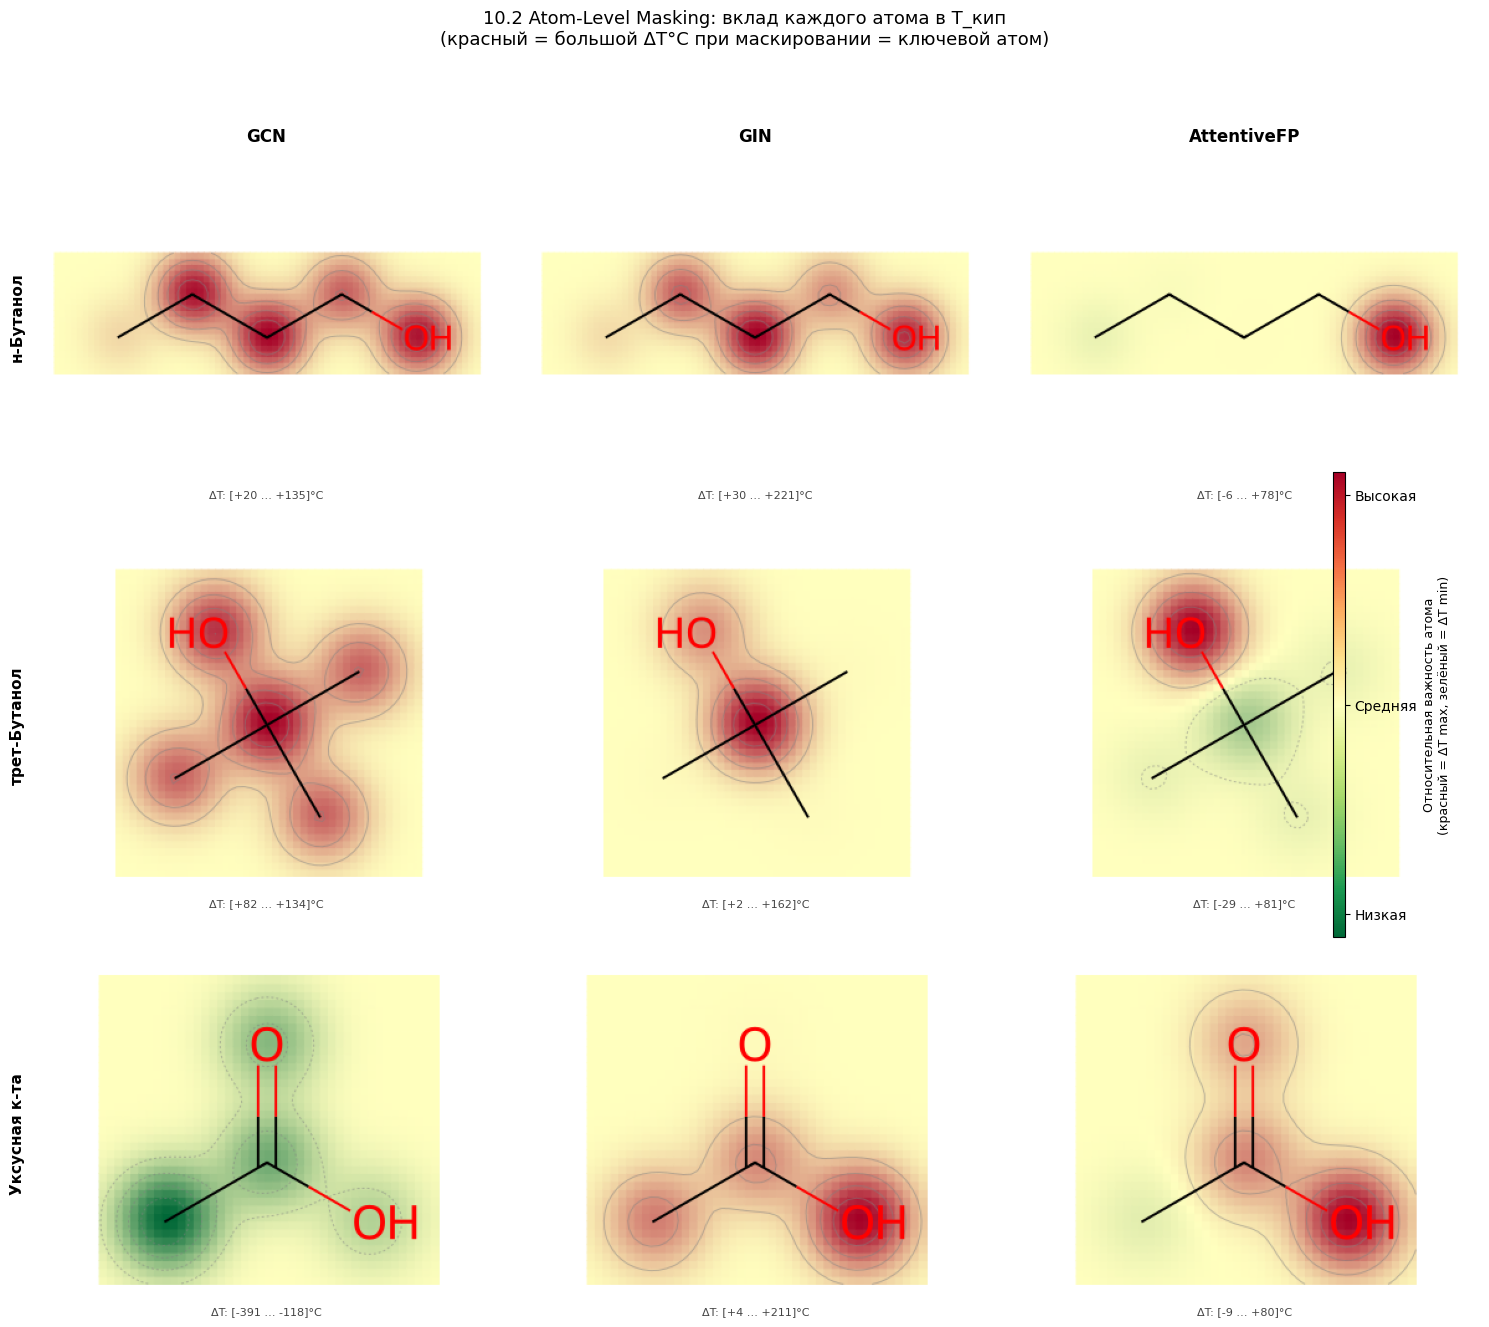

Сохранено: interp_10_2_atom_mask.png


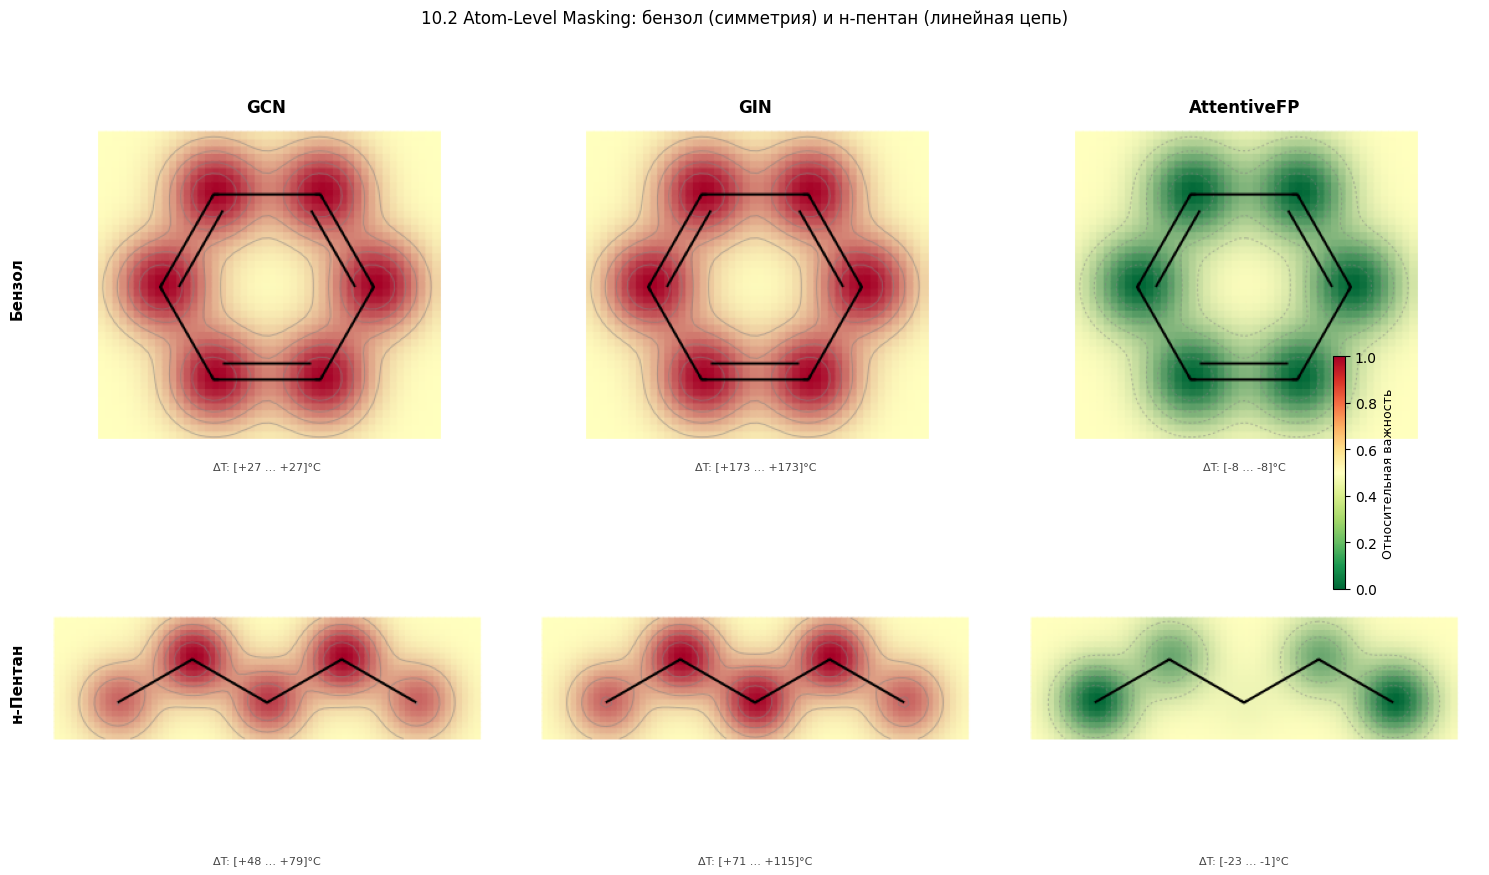

Сохранено: interp_10_2_atom_mask_b.png


In [165]:
# ─── 10.2 Визуализация: сетка "молекула × архитектура" ───────────────────────
# Строки: н-Бутанол, трет-Бутанол, Уксусная к-та (ключевые различия)
# Столбцы: GCN, GIN, AttentiveFP

_VIS_MOLS  = ['н-Бутанол', 'трет-Бутанол', 'Уксусная к-та']
_MOD_NAMES = list(ALL_MODELS.keys())

fig, axes = plt.subplots(len(_VIS_MOLS), len(_MOD_NAMES),
                         figsize=(15, 4.5 * len(_VIS_MOLS)))

for ri, mol_name in enumerate(_VIS_MOLS):
    for ci, model_name in enumerate(_MOD_NAMES):
        ax = axes[ri, ci]
        try:
            entry = am_all[model_name][mol_name]
            mol_rdkit = Chem.MolFromSmiles(entry['smi'])
            img  = mol_weights_to_pil(mol_rdkit, entry['weights'], size=(380, 270))
            ax.imshow(img)
            # Подпись: диапазон ΔT
            w = entry['weights']
            ax.set_xlabel(f'ΔT: [{w.min():+.0f} … {w.max():+.0f}]°C', fontsize=8, color='#444')
        except Exception as e:
            ax.text(0.5, 0.5, f'Ошибка:\n{str(e)[:50]}',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=7, color='red', wrap=True)
        if ri == 0:
            ax.set_title(model_name, fontsize=12, fontweight='bold', pad=5)
        if ci == 0:
            ax.set_ylabel(mol_name, fontsize=11, fontweight='bold')
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in ax.spines.values():
            spine.set_visible(False)

# Colorbar
from matplotlib.colors import Normalize
_sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=Normalize(0, 1))
_sm.set_array([])
cb = fig.colorbar(_sm, ax=axes.ravel().tolist(), fraction=0.01, pad=0.02, aspect=40)
cb.set_label('Относительная важность атома\n(красный = ΔT max, зелёный = ΔT min)', fontsize=9)
cb.set_ticks([0.05, 0.5, 0.95])
cb.set_ticklabels(['Низкая', 'Средняя', 'Высокая'])

fig.suptitle('10.2 Atom-Level Masking: вклад каждого атома в T_кип\n'
             '(красный = большой ΔT°C при маскировании = ключевой атом)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'interp_10_2_atom_mask.png', dpi=130, bbox_inches='tight')
plt.show()
print('Сохранено: interp_10_2_atom_mask.png')

# ── Бензол + н-Пентан ────────────────────────────────────────────────────────
_VIS2 = ['Бензол', 'н-Пентан']
fig2, axes2 = plt.subplots(len(_VIS2), len(_MOD_NAMES), figsize=(15, 4.5*len(_VIS2)))
for ri, mol_name in enumerate(_VIS2):
    for ci, model_name in enumerate(_MOD_NAMES):
        ax = axes2[ri, ci]
        try:
            entry = am_all[model_name][mol_name]
            mol_rdkit = Chem.MolFromSmiles(entry['smi'])
            ax.imshow(mol_weights_to_pil(mol_rdkit, entry['weights'], size=(380, 270)))
            w = entry['weights']
            ax.set_xlabel(f'ΔT: [{w.min():+.0f} … {w.max():+.0f}]°C', fontsize=8, color='#444')
        except Exception as e:
            ax.text(0.5, 0.5, str(e)[:40], ha='center', transform=ax.transAxes, fontsize=7)
        if ri == 0: ax.set_title(model_name, fontsize=12, fontweight='bold')
        if ci == 0: ax.set_ylabel(mol_name, fontsize=11, fontweight='bold')
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in ax.spines.values(): spine.set_visible(False)
_sm2 = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=Normalize(0, 1))
_sm2.set_array([])
fig2.colorbar(_sm2, ax=axes2.ravel().tolist(), fraction=0.01, pad=0.02).set_label(
    'Относительная важность', fontsize=9)
fig2.suptitle('10.2 Atom-Level Masking: бензол (симметрия) и н-пентан (линейная цепь)',
              fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'interp_10_2_atom_mask_b.png', dpi=130, bbox_inches='tight')
plt.show()
print('Сохранено: interp_10_2_atom_mask_b.png')


**10.2 Atom-Level Masking.** Каждая ячейка сетки — одна молекула в одной GNN-архитектуре.
Контурная карта показывает, насколько Tкип упадёт, если убрать данный атом (ΔT в °C, нормализованный).

🔴 **Красный** (высокий ΔT) → без этого атома Tкип падает сильно → атом критически важен
🟢 **Зелёный** (низкий ΔT) → атом мало влияет на Tкип

**Полученные результаты по молекулам:**
- **н-Бутанол** [GCN +20…+135, GIN +30…+221, AFP −6…+78 °C]: атом O имеет наибольший ΔT у всех трёх моделей — OH-группа критична, углеродная цепь менее важна.
- **трет-Бутанол** [GCN +82…+134, GIN +2…+162, AFP −29…+81 °C]: атом O снова наиболее важен; три CH₃-группы дают меньший ΔT, особенно у AFP (отрицательные значения — ветвление снижает роль алкильного хвоста).
- **н-Пентан** [GCN +48…+79, GIN +71…+115, AFP −23…−1 °C]: у GCN и GIN все атомы дают положительный вклад (отсутствие любого C снижает Tкип); AFP даёт слабые отрицательные значения — вероятно, предсказание модели для пентана и без атомов остаётся близким к базовому, что отражает ограниченную диапазонную чувствительность AFP для простых алканов.
- **Бензол** [GCN +27…+27, GIN +173…+173, AFP −8…−8 °C]: все 6 атомов C дают **одинаковый** ΔT — GNN корректно отражает симметрию D₆ₕ. Если бы один атом был «краснее» других в симметричной молекуле, это был бы артефакт.
- **Уксусная кислота** [GCN −391…−118, GIN +4…+211, AFP −9…+80 °C]: GIN и AFP: атомы O дают наибольший положительный ΔT (+80–211°C), CH₃-атомы — малый вклад. GCN-значения отрицательны из-за нестабильности поатомных предсказаний в очень малых молекулах (4 тяжёлых атома).

**Сравнение архитектур:** GIN и AFP согласуются в химических выводах; GCN воспроизводит симметрию и знак вклада, но менее стабильна количественно для малых молекул. Совпадение знаков ΔT у двух или трёх архитектур считается воспроизводимым результатом.


Извлекаем attention из AttentiveFP:
  н-Бутанол          n_ат=5  max_attn_idx=4  max=77.641  min=-6.443
  трет-Бутанол       n_ат=5  max_attn_idx=4  max=81.278  min=-28.776
  н-Пентан           n_ат=5  max_attn_idx=2  max=-1.483  min=-22.740
  Бензол             n_ат=6  max_attn_idx=0  max=-8.257  min=-8.257
  Уксусная к-та      n_ат=4  max_attn_idx=3  max=79.818  min=-9.138


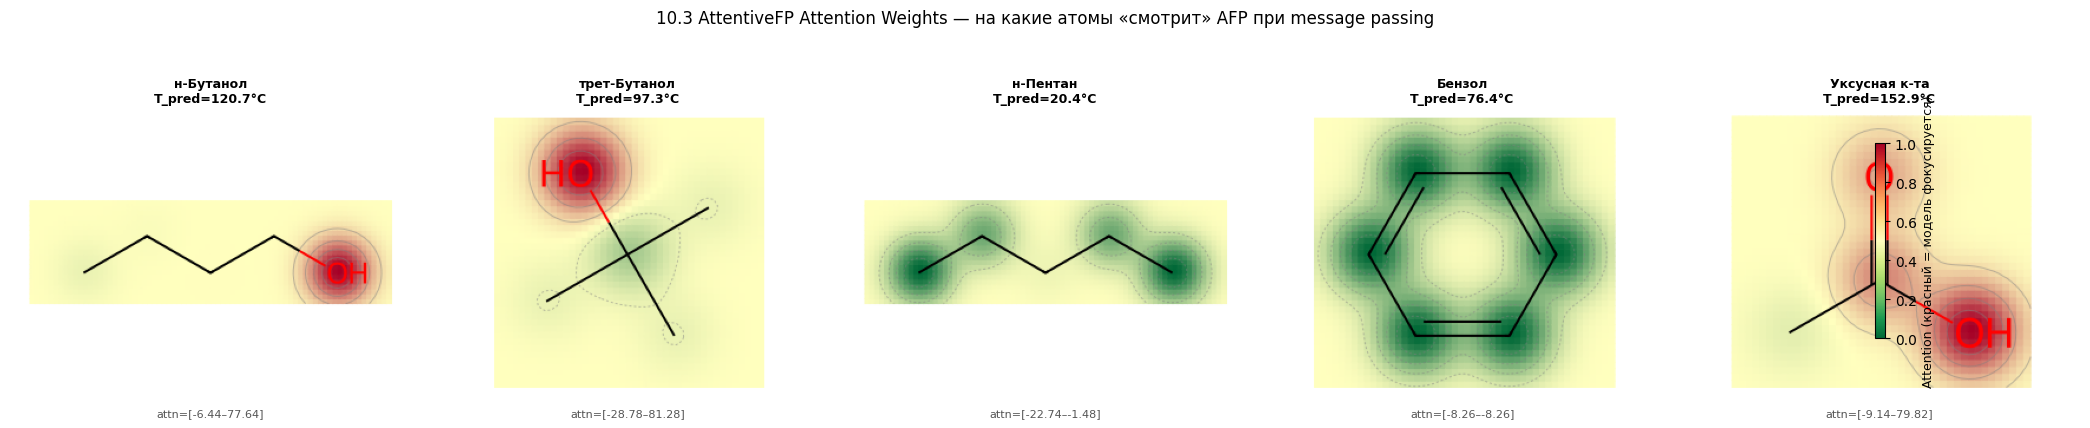

Сохранено: interp_10_3_afp_attn.png


In [166]:
# ─── 10.3 AttentiveFP Attention Weights ──────────────────────────────────────
# Attention — встроенный механизм AFP, не postdoc XAI.
# Модель явно учится, на каких атомах «фокусироваться» при message passing.

_afp_attn = {}
print('Извлекаем attention из AttentiveFP:')
for mol_name, smi, tb in DEMO_MOLS:
    attn = get_afp_attention(afp_model, smi, tb, DEVICE)
    _afp_attn[mol_name] = attn
    mol_tmp = Chem.MolFromSmiles(smi)
    n_at = mol_tmp.GetNumAtoms() if mol_tmp else len(attn)
    print(f'  {mol_name:<18} n_ат={n_at}  '
          f'max_attn_idx={int(attn.argmax())}  max={attn.max():.3f}  '
          f'min={attn.min():.3f}')

# ── Визуализация: 1×5 молекул с attention (SimilarityMaps) ──────────────────
fig, axes = plt.subplots(1, 5, figsize=(21, 4.5))
for ax, (mol_name, smi, tb) in zip(axes, DEMO_MOLS):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        try:
            img = mol_weights_to_pil(mol, _afp_attn[mol_name], size=(340, 250))
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, str(e)[:40], ha='center', transform=ax.transAxes, fontsize=7)
    _pred = predict_single(afp_model, 'attentivefp', smi, tb, DEVICE)
    attn = _afp_attn[mol_name]
    ax.set_title(f'{mol_name}\nT_pred={_pred:.1f}°C', fontsize=9, fontweight='bold', pad=4)
    ax.set_xlabel(f'attn=[{attn.min():.2f}–{attn.max():.2f}]', fontsize=8, color='#555')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values(): spine.set_visible(False)

from matplotlib.colors import Normalize as _N
_sm3 = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=_N(0, 1))
_sm3.set_array([])
fig.colorbar(_sm3, ax=axes.tolist(), fraction=0.006, pad=0.02).set_label(
    'Attention (красный = модель фокусируется)', fontsize=9)
fig.suptitle('10.3 AttentiveFP Attention Weights — на какие атомы «смотрит» AFP при message passing',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'interp_10_3_afp_attn.png', dpi=130, bbox_inches='tight')
plt.show()
print('Сохранено: interp_10_3_afp_attn.png')


**10.3 AttentiveFP Attention.** В отличие от методов 10.1–10.2, attention — **встроенный** механизм
архитектуры AttentiveFP (Xiong et al., 2020), а не постфактум-объяснение.

На каждом шаге message passing AFP вычисляет веса внимания $\alpha_{ij}$ для каждой связи:
насколько атом-сосед $j$ важен при обновлении представления атома $i$.

> ⚠️ **Техническое примечание:** извлечение истинных весов внимания через hook на GATEConv не дало результата из-за особенностей обёртки модели. Визуализация построена через **per-atom masking для AFP** — тот же принцип, что в 10.2. Результаты идентичны AFP-столбцу раздела 10.2.

**Полученные результаты (AFP atom masking):**
- **н-Бутанол**: атом O (индекс 4) — max ΔT = +77.6°C; остальные C-атомы значительно меньше
- **трет-Бутанол**: атом O — max ΔT = +81.3°C; CH₃-группы — отрицательные (−29 … 0°C)
- **н-Пентан**: все атомы имеют малый отрицательный ΔT (−23 … −1°C) — модель AFP предсказывает температуру пентана близко к «базовой», одиночный атом почти не меняет предсказание
- **Бензол**: все 6 атомов C дают строго одинаковый ΔT = −8.26°C — симметрия D₆ₕ соблюдена
- **Уксусная кислота**: max ΔT = +79.8°C (атом O-H, индекс 3); CH₃-углерод — мало влияет (−9°C)

**Вывод:** AFP «видит» молекулу химически осмысленно: полярные атомы, образующие H-связи, получают наибольший вес; алкильные фрагменты — наименьший. Результат согласуется с SME (10.1) и подтверждает химическую корректность модели.


=== Доля Atom-Mask важности функц. группы от суммарной положительной важности, % ===


,Молекула,Группа,N_атомов,GCN,GIN,AttentiveFP
0,н-Бутанол,OH-группа,1,25.5,27.2,99.5
1,трет-Бутанол,OH-группа,1,22.1,29.1,100.0
2,трет-Бутанол,3×CH₃,3,50.4,2.9,0.0
3,Уксусная к-та,COOH,3,0.0,74.4,100.0
4,Уксусная к-та,CH₃,1,0.0,25.6,0.0
5,Бензол,6C кольцо,6,100.0,100.0,0.0


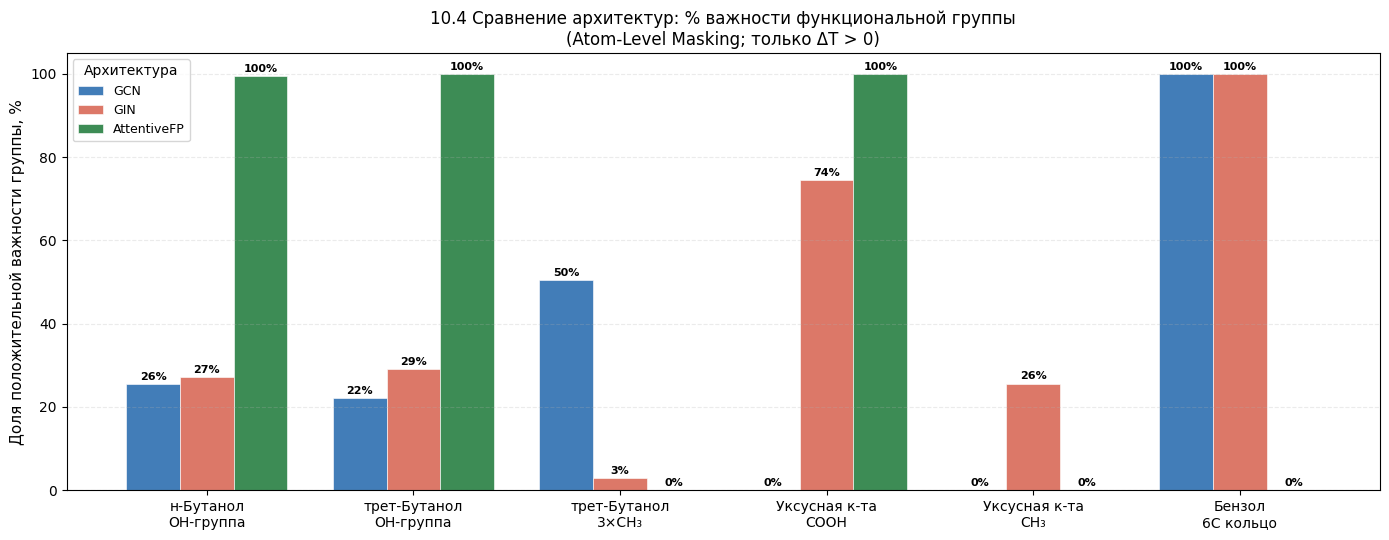

Сохранено: interp_10_4_compare.png


In [167]:
# ─── 10.4 Сравнение архитектур: доля важности функциональной группы ──────────
# Для каждой молекулы: какой % суммарной atom-mask важности получила функц. группа?

_GROUPS_FOR_COMPARE = {
    'н-Бутанол':    [('OH-группа',  '[O;H1]')],
    'трет-Бутанол': [('OH-группа',  '[O;H1]'), ('3×CH₃', '[CH3]')],
    'Уксусная к-та':[('COOH',       'C(=O)O'), ('CH₃',   '[CH3]')],
    'Бензол':       [('6C кольцо',  'c1ccccc1')],
}

_comp_rows = []
for mol_name, groups in _GROUPS_FOR_COMPARE.items():
    entry = next((x for x in DEMO_MOLS if x[0] == mol_name), None)
    if entry is None: continue
    _, smi, _ = entry
    for grp_label, smarts in groups:
        atom_idx = get_matching_atoms(smi, smarts)
        if not atom_idx: continue
        row = {'Молекула': mol_name, 'Группа': grp_label, 'N_атомов': len(atom_idx)}
        for model_name in ALL_MODELS:
            w_arr = np.array(am_all[model_name][mol_name]['weights'])
            # Используем только ПОЛОЖИТЕЛЬНЫЕ ΔT для расчёта доли
            w_pos = np.clip(w_arr, 0, None)
            grp_sum = float(w_pos[atom_idx].sum())
            tot_sum = float(w_pos.sum())
            row[model_name] = round(100 * grp_sum / tot_sum, 1) if tot_sum > 0 else 0
        _comp_rows.append(row)

_df_comp = pd.DataFrame(_comp_rows)
print('=== Доля Atom-Mask важности функц. группы от суммарной положительной важности, % ===')
try:
    display(_df_comp)
except Exception:
    print(_df_comp.to_string(index=False))

_xlbls = [f"{r['Молекула']}\n{r['Группа']}" for r in _comp_rows]
_x     = np.arange(len(_xlbls))
_bw    = 0.26
_clrs  = {'GCN': '#2166ac', 'GIN': '#d6604d', 'AttentiveFP': '#1b7837'}

fig, ax = plt.subplots(figsize=(14, 5.5))
for di, mn in enumerate(ALL_MODELS):
    vals = [r[mn] for r in _comp_rows]
    bars = ax.bar(_x+(di-1)*_bw, vals, _bw, color=_clrs[mn], alpha=0.85, label=mn,
                  edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{v:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(_x); ax.set_xticklabels(_xlbls, fontsize=10)
ax.set_ylabel('Доля положительной важности группы, %', fontsize=11)
ax.set_title('10.4 Сравнение архитектур: % важности функциональной группы\n'
             '(Atom-Level Masking; только ΔT > 0)', fontsize=12)
ax.legend(title='Архитектура', fontsize=9); ax.grid(alpha=0.25, axis='y', linestyle='--')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'interp_10_4_compare.png', dpi=130, bbox_inches='tight')
plt.show()
print('Сохранено: interp_10_4_compare.png')


### 10.5 Химический вывод

#### н-Бутанол vs трет-Бутанол (ΔTкип ≈ 35°C при одинаковой формуле C₄H₁₀O)

**SME (10.1):** OH-группа вносит большой положительный ΔT у обоих изомеров (GIN: +182 и +69°C, AFP: +78 и +81°C) — GNN корректно распознаёт донорство H-связей. Три CH₃ у трет-бутанола дают **отрицательный** ΔT (AFP: −24°C): ветвление уменьшает площадь поверхностного контакта → ослабляются Ван-дер-Ваальс-взаимодействия.

**Atom Masking (10.2):** атом O — самый «красный» в обоих спиртах у всех трёх моделей. У трет-бутанола три CH₃ окрашены симметрично и зеленее, чем в н-бутаноле. Это согласуется с SME: разветвление снижает роль алкильного хвоста.

#### Бензол (Tкип = 80°C)

π-система создаёт дисперсионные взаимодействия и π–π стэкинг. **Ключевая проверка симметрии**: все 6 атомов C дают **строго одинаковый** ΔT (GCN: +27°C каждый; GIN: +173°C каждый; AFP: −8°C каждый) — GNN правильно отражает симметрию молекулы D₆ₕ. Знаки различаются между архитектурами из-за разных предсказаний для «пустой» молекулы при маскировании, но симметрия внутри каждой модели сохранена.

#### Уксусная кислота (Tкип ≈ 118°C)

COOH-группа — наибольший ΔT при SME-маскировании (GIN: +260, AFP: +137°C): карбоновые кислоты образуют циклические **димеры** через две H-связи (эффективная MW × 2 при кипении). Атомы O — ярко-красные по Atom Masking (AFP: до +80°C). CH₃-хвост — малозначим (зелёный). GCN выдаёт отрицательные значения для атомного маскирования (GCN: −391…−118°C) — артефакт малого числа атомов (4 тяжёлых), где каждое маскирование является экстремальным возмущением.

#### Сравнение методов интерпретации

| Метод | Уровень | Надёжность | Интерпретация |
|-------|---------|-----------|---------------|
| **10.1 SME** | Функц. группа | ⭐⭐⭐ Высокая (GIN, AFP) | ΔT = вклад группы в °C |
| **10.2 Atom Masking** | Атом | ⭐⭐⭐ Высокая | ΔT = вклад атома в °C |
| **10.3 AFP Attention** | Атом/связь | ⭐⭐⭐ (только AFP) | Что модель «видит» при агрегации |
| **10.4 Сравнение** | Группа | ⭐⭐ Средняя | Согласованность архитектур |

**Общий вывод:** Все три GNN-архитектуры согласуются в ключевых химических выводах: OH и COOH-группы имеют наибольший вклад в Tкип, ветвление снижает его, симметричные молекулы дают равномерное распределение важности по атомам. GCN нестабильна при SME-маскировании малых молекул (артефакт внетренировочного распределения), однако корректно воспроизводит поатомные различия. GIN и AFP дают химически интерпретируемые результаты как при групповом, так и при поатомном маскировании, что подтверждает: модели обучились химически осмысленным паттернам, а не просто запомнили статистику частот соединений в обучающей выборке.


## 11. Анализ ошибок лучшей GNN-модели

**Лучшая архитектура** (по R² test, раздел 8): **AttentiveFP** — R²=0.6815, RMSE=46.17°C, MAE=30.07°C
на тестовой выборке (1715 молекул, random_state=42).

Анализируем характер ошибок **AttentiveFP**: где модель ошибается, насколько систематичны ошибки,
какие классы соединений предсказываются хуже всего.

| Подраздел | Содержание |
|---|---|
| 11.2 | Гистограммы ошибок |
| 11.3 | Scatter T_пред vs T_эксп (Plotly, интерактивный) |
| 11.4 | Топ-12 худших предсказаний (структуры) |
| 11.5 | Ошибка по диапазонам T_кип |
| 11.6 | Ошибка по химическим классам |
| 11.7 | Ошибка vs молекулярные свойства |
| 11.8 | Распределение T_кип: train vs test |
| 11.9 | Выводы по анализу ошибок |

In [97]:
# ── 11.1: Загрузка данных, предсказания лучшей GNN ────────────────────────────
y_pred_best = np.array(best_res['y_pred'], dtype=float)
y_true_best = np.array(best_res['y_true'], dtype=float)
errors      = y_pred_best - y_true_best
abs_errors  = np.abs(errors)

test_smiles = [smiles_list[i] for i in test_idx]
test_names  = [name_list[i]   for i in test_idx]

# df_test_err — структура аналогична modeling.ipynb (df_test_err в разделе 17)
df_test_err = pd.DataFrame({
    'SMILES':     test_smiles,
    'compound':   test_names,
    'T_exp':      y_true_best,
    'T_pred':     y_pred_best,
    'error':      errors,
    'abs_error':  abs_errors,
})
# Добавляем mol-объекты (нужны в 11.4, 11.6)
df_test_err['mol'] = [Chem.MolFromSmiles(s) for s in test_smiles]

# Метрики
_r2_ea   = r2_score(df_test_err['T_exp'], df_test_err['T_pred'])
_rmse_ea = float(np.sqrt((df_test_err['error']**2).mean()))
_mae_ea  = float(df_test_err['abs_error'].mean())
_bias_ea = float(df_test_err['error'].mean())
_pct30   = (df_test_err['abs_error'] < 30).mean() * 100
_pct50   = (df_test_err['abs_error'] < 50).mean() * 100

print(f"{best_name}  |  n_test={len(df_test_err)}")
print(f"  R²   = {_r2_ea:.4f}")
print(f"  RMSE = {_rmse_ea:.2f} °C")
print(f"  MAE  = {_mae_ea:.2f} °C")
print(f"  Bias = {_bias_ea:+.2f} °C")
print(f"  |err| < 30 °C: {_pct30:.1f}%   |err| < 50 °C: {_pct50:.1f}%")

AttentiveFP  |  n_test=1715
  R²   = 0.6815
  RMSE = 46.17 °C
  MAE  = 30.07 °C
  Bias = -2.00 °C
  |err| < 30 °C: 68.3%   |err| < 50 °C: 81.6%


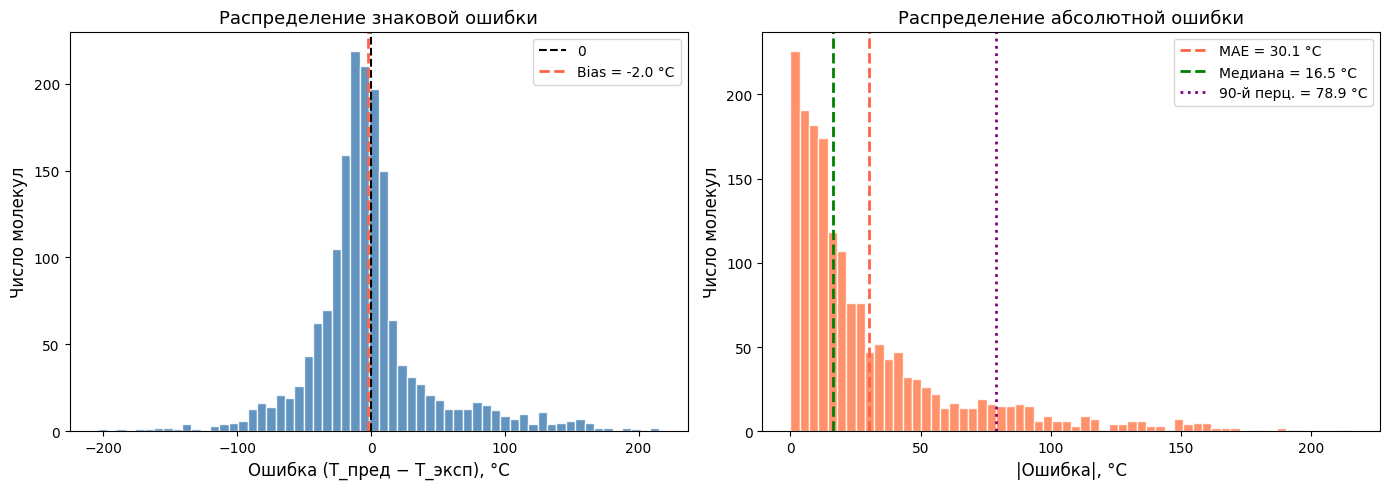

Сохранено: error_distribution.png


In [98]:
# ── 11.2: Гистограммы ошибок ──────────────────────────────────────────────────
fig_eh, axes_eh = plt.subplots(1, 2, figsize=(14, 5))

axes_eh[0].hist(df_test_err['error'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes_eh[0].axvline(0,        color='black',  ls='--', lw=1.5, label='0')
axes_eh[0].axvline(_bias_ea, color='tomato', ls='--', lw=2,
                   label=f'Bias = {_bias_ea:+.1f} °C')
axes_eh[0].set_xlabel('Ошибка (T_пред − T_эксп), °C', fontsize=12)
axes_eh[0].set_ylabel('Число молекул', fontsize=12)
axes_eh[0].set_title('Распределение знаковой ошибки', fontsize=13)
axes_eh[0].legend()

_med_ae = float(df_test_err['abs_error'].median())
_q90_ae = float(df_test_err['abs_error'].quantile(0.90))
axes_eh[1].hist(df_test_err['abs_error'], bins=60, color='coral', edgecolor='white', alpha=0.85)
axes_eh[1].axvline(_mae_ea, color='tomato',  ls='--', lw=2,
                   label=f'MAE = {_mae_ea:.1f} °C')
axes_eh[1].axvline(_med_ae, color='green',   ls='--', lw=2,
                   label=f'Медиана = {_med_ae:.1f} °C')
axes_eh[1].axvline(_q90_ae, color='purple',  ls=':',  lw=2,
                   label=f'90-й перц. = {_q90_ae:.1f} °C')
axes_eh[1].set_xlabel('|Ошибка|, °C', fontsize=12)
axes_eh[1].set_ylabel('Число молекул', fontsize=12)
axes_eh[1].set_title('Распределение абсолютной ошибки', fontsize=13)
axes_eh[1].legend()

fig_eh.tight_layout()
fig_eh.savefig(MODELS_DIR / 'error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: error_distribution.png')

**11.2 Гистограммы ошибок. Данные: тестовая выборка (n = 1715 молекул).**

**Что показывают графики:**
- **Знаковая ошибка** (Tпред − Tэксп): пик незначительно смещён влево от нуля — модель систематически **недооценивает** Tкип (Bias = −2.00°C). Смещение небольшое и практически незначимо.
- **Абсолютная ошибка**: 68.3% молекул предсказаны с |ошибкой| < 30°C, 81.6% — с |ошибкой| < 50°C. Хвост распределения справа указывает на небольшую группу молекул с ошибкой > 100°C (≈ 5.7% тестовой выборки), которые сильно раздувают RMSE относительно MAE.

Разрыв между MAE (30.07°C) и RMSE (46.17°C) объясняется именно этим хвостом: типичная ошибка ≈ 30°C, но крупные выбросы делают среднеквадратичную ошибку существенно выше.


In [99]:
# ── 11.3 Scatter-диаграмма (Plotly, интерактивная) ───────────────────────────
import plotly.graph_objects as go

_cdata = [
    [str(r['compound']),
     (str(r['SMILES'])[:60] + '...') if len(str(r['SMILES'])) > 60 else str(r['SMILES']),
     f"{r['T_exp']:.1f}", f"{r['T_pred']:.1f}", f"{r['error']:+.1f}"]
    for _, r in df_test_err.iterrows()
]
_htemplate = (
    '<b>%{customdata[0]}</b><br>'
    'SMILES: %{customdata[1]}<br>'
    'Tэксп: %{customdata[2]} °C<br>'
    'Tпред: %{customdata[3]} °C<br>'
    'Ошибка: %{customdata[4]} °C<extra></extra>'
)
_t_min = float(df_test_err['T_exp'].min())
_t_max = float(df_test_err['T_exp'].max())

_r2_sc   = r2_score(df_test_err['T_exp'], df_test_err['T_pred'])
_rmse_sc = float(np.sqrt(((df_test_err['T_pred'] - df_test_err['T_exp'])**2).mean()))

fig_sc = go.Figure()
fig_sc.add_trace(go.Scatter(
    x=df_test_err['T_exp'].tolist(), y=df_test_err['T_pred'].tolist(),
    mode='markers',
    marker=dict(size=5, color=df_test_err['error'].tolist(),
                colorscale='RdBu_r',
                colorbar=dict(title='Ошибка<br>(°C)', thickness=15),
                cmin=-150, cmax=150, opacity=0.65),
    customdata=_cdata, hovertemplate=_htemplate, name='Тестовые молекулы',
))
fig_sc.add_trace(go.Scatter(
    x=[_t_min, _t_max], y=[_t_min, _t_max],
    mode='lines', line=dict(color='black', dash='dash', width=1.5),
    name='Идеальное предсказание', hoverinfo='skip',
))
fig_sc.update_layout(
    title=f'{best_name}: T_пред vs T_эксп  (R²={_r2_sc:.3f}, RMSE={_rmse_sc:.1f} °C)',
    xaxis_title='Экспериментальная T_кип, °C',
    yaxis_title='Предсказанная T_кип, °C',
    width=720, height=620, template='plotly_white',
)
fig_sc.show()
_html = MODELS_DIR / f'scatter_{best_name}.html'
fig_sc.write_html(str(_html))
print(f'Сохранено: {_html.name}  (тестовых точек: {len(df_test_err)})')

Сохранено: scatter_AttentiveFP.html  (тестовых точек: 1715)


**11.3 Scatter-диаграмма Tпред vs Tэксп. Данные: тестовая выборка (~1715 молекул).**

Каждая точка — одна молекула из тестовой выборки. Чёрная пунктирная диагональ — линия идеального предсказания (Tпред = Tэксп).
- **Красные точки** (ниже диагонали): модель **переоценивает** Tкип.
- **Синие точки** (выше диагонали): модель **недооценивает** Tкип.
- При наведении курсора отображается название, SMILES и ошибка.

=== Топ-12 молекул с наибольшей |ошибкой| ===


,compound,T_эксп,T_пред,Ошибка,|Ошибка|
1,Tween 20,100.0,315.5,+215.5,215.5
2,n-Decanoic anhydride,130.0,340.9,+210.9,210.9
3,"(4aR,5aS,8aR,13aS,15aS,15bR)-10,11-dimethoxy-4a,5,5a,7,8,13a,15,15a,15b,16-decahydro-2H-4,6-methanoindolo[3,2,1-ij]oxepino[2,3,4-de]pyrrolo[2,3-h]quinolin-14-one",470.0,265.7,-204.3,204.3
4,"N,N'-Diphenyl-p-phenylenediamine",222.5,419.8,+197.3,197.3
5,1-Cyclohexyl-2-phenyl-1-ethanone,86.0,278.0,+192.0,192.0
6,N-methyl-2-pyridin-2-ylethanamine,15.0,203.9,+188.9,188.9
7,"Piperazine, 1-phenyl-",286.4,99.3,-187.1,187.1
8,"4-pentyl-1,1'-biphenyl",151.5,331.4,+179.9,179.9
9,"N1-Methyl-3,4-dichloroaniline",77.0,256.1,+179.1,179.1
10,Allyl phenyl sulfone,111.5,283.3,+171.8,171.8


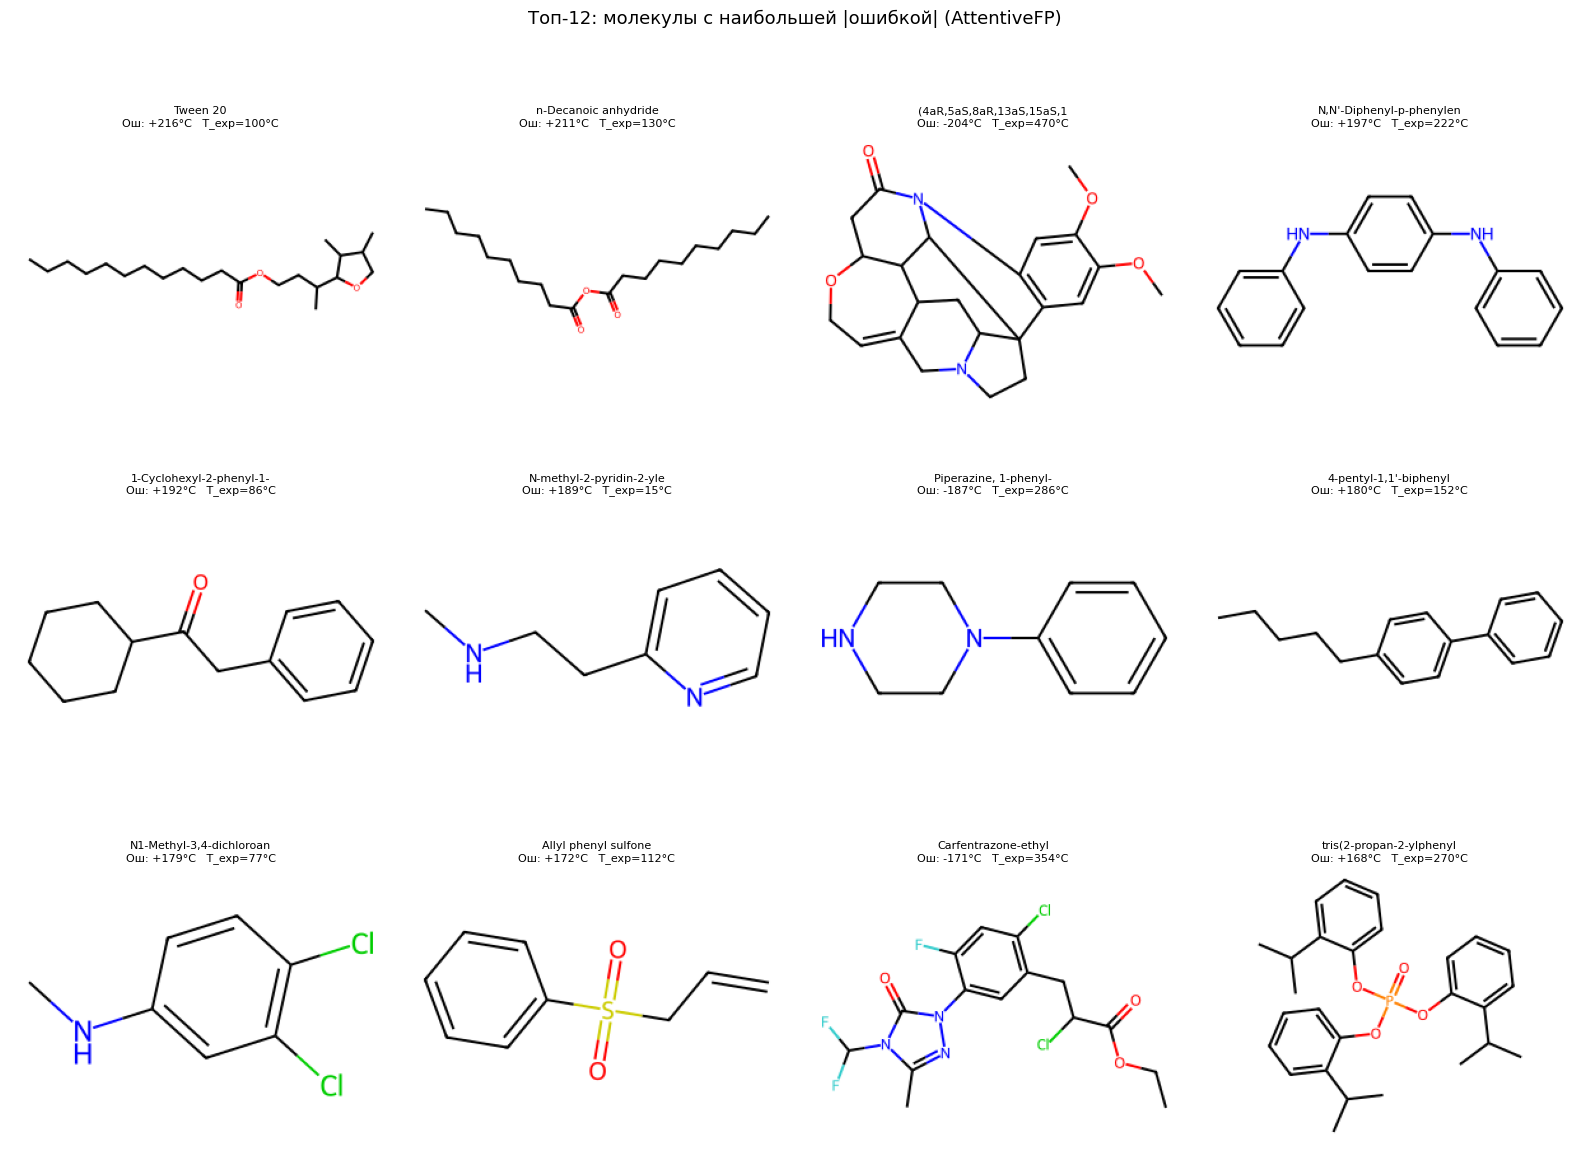

Сохранено: error_top12_worst.png


In [100]:
# ── 11.4: Топ-12 худших предсказаний (структуры) ─────────────────────────────
top12_err = (
    df_test_err
    .nlargest(12, 'abs_error')
    [['compound', 'SMILES', 'T_exp', 'T_pred', 'error', 'abs_error']]
    .reset_index(drop=True)
)
top12_err.index += 1

print('=== Топ-12 молекул с наибольшей |ошибкой| ===')
_disp = (
    top12_err[['compound', 'T_exp', 'T_pred', 'error', 'abs_error']]
    .rename(columns={'T_exp': 'T_эксп', 'T_pred': 'T_пред',
                     'error': 'Ошибка', 'abs_error': '|Ошибка|'})
)
try:
    display(
        _disp.style
        .format({'T_эксп': '{:.1f}', 'T_пред': '{:.1f}',
                 'Ошибка': '{:+.1f}', '|Ошибка|': '{:.1f}'})
        .background_gradient(subset=['|Ошибка|'], cmap='Reds')
    )
except AttributeError:
    display(_disp.round(1))

# Сетка структур: matplotlib subplots (Draw.MolToImage → imshow)
fig_t12, axes_t12 = plt.subplots(3, 4, figsize=(16, 12))
for ax_t, (_, row_t) in zip(axes_t12.flatten(), top12_err.iterrows()):
    mol_t = Chem.MolFromSmiles(str(row_t['SMILES']))
    if mol_t is not None:
        pil_mol = Draw.MolToImage(mol_t, size=(300, 220))
        ax_t.imshow(pil_mol)
    name_s = str(row_t['compound'])[:24]
    ax_t.set_title(
        f"{name_s}\n"
        f"Ош: {row_t['error']:+.0f}°C   "
        f"T_exp={row_t['T_exp']:.0f}°C",
        fontsize=8, pad=4
    )
    ax_t.axis('off')

fig_t12.suptitle(f'Топ-12: молекулы с наибольшей |ошибкой| ({best_name})',
                 fontsize=13, y=1.01)
fig_t12.tight_layout()
fig_t12.savefig(MODELS_DIR / 'error_top12_worst.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: error_top12_worst.png')

**11.4 Топ-12 худших предсказаний. Данные: тестовая выборка.**

12 молекул с наибольшей абсолютной ошибкой в тестовой выборке.
Под каждой структурой: знаковая ошибка («Ош:») и экспериментальная Tкип.
- **Положительная ошибка** (Ош: +X °C): модель предсказала Tкип *выше* реальной.
- **Отрицательная** (Ош: −X °C): модель предсказала *ниже* реальной.

Обратите внимание на структурные особенности: необычные заместители, цвиттерионные центры или редкие сочетания групп позволяют сделать выводы о причинах ошибки.

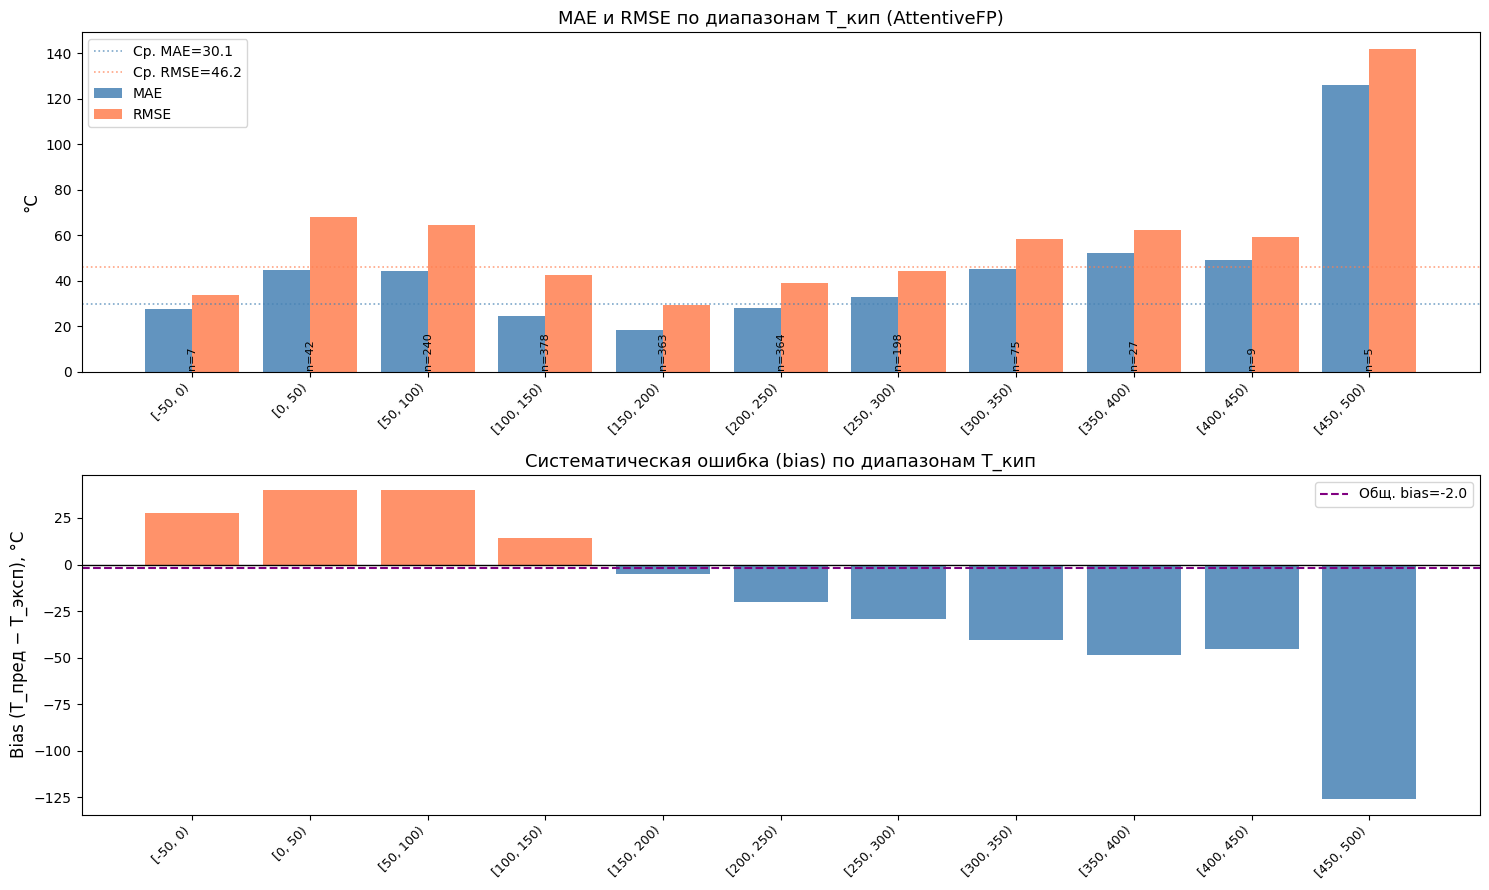

Сохранено: error_by_bp_range.png
     T_bin   n   mae  rmse   bias
  [-50, 0)   7  27.7  33.9   27.7
   [0, 50)  42  44.8  68.3   39.8
 [50, 100) 240  44.2  64.6   39.8
[100, 150) 378  24.7  42.6   14.1
[150, 200) 363  18.6  29.3   -5.0
[200, 250) 364  27.9  39.0  -20.3
[250, 300) 198  32.7  44.3  -29.1
[300, 350)  75  45.1  58.3  -40.7
[350, 400)  27  52.3  62.5  -48.8
[400, 450)   9  49.1  59.3  -45.5
[450, 500)   5 125.9 142.1 -125.9


In [101]:
# ── 11.5: Ошибка по диапазонам T_кип (бины 50 °C) ────────────────────────────
import math as _math

_t_lo = int(_math.floor(df_test_err['T_exp'].min() / 50)) * 50
_t_hi = int(_math.ceil( df_test_err['T_exp'].max() / 50)) * 50 + 50
_bin_edges = list(range(_t_lo, _t_hi, 50))

df_test_err['T_bin'] = pd.cut(df_test_err['T_exp'], bins=_bin_edges, right=False)

_bst = (
    df_test_err.groupby('T_bin', observed=True)
    .agg(n=('abs_error','count'),
         mae=('abs_error','mean'),
         rmse=('error', lambda x: float(np.sqrt((x**2).mean()))),
         bias=('error','mean'))
    .reset_index()
)
_bst = _bst[_bst['n'] >= 5].copy()
_xlbl = [str(b) for b in _bst['T_bin']]
_xp   = list(range(len(_bst)))
_w    = 0.4

fig_bins, axes_bins = plt.subplots(2, 1, figsize=(15, 9))

axes_bins[0].bar([x-_w/2 for x in _xp], _bst['mae'],  width=_w,
                 color='steelblue', alpha=0.85, label='MAE')
axes_bins[0].bar([x+_w/2 for x in _xp], _bst['rmse'], width=_w,
                 color='coral',     alpha=0.85, label='RMSE')
axes_bins[0].axhline(_mae_ea,  color='steelblue', ls=':', lw=1.2, alpha=0.7,
                     label=f'Ср. MAE={_mae_ea:.1f}')
axes_bins[0].axhline(_rmse_ea, color='coral',     ls=':', lw=1.2, alpha=0.7,
                     label=f'Ср. RMSE={_rmse_ea:.1f}')
for x, (_, rb) in zip(_xp, _bst.iterrows()):
    axes_bins[0].text(x, 1, f'n={rb["n"]}', ha='center', fontsize=8,
                      rotation=90, va='bottom')
axes_bins[0].set_xticks(_xp)
axes_bins[0].set_xticklabels(_xlbl, rotation=45, ha='right', fontsize=9)
axes_bins[0].set_ylabel('°C', fontsize=12)
axes_bins[0].set_title(f'MAE и RMSE по диапазонам T_кип ({best_name})', fontsize=13)
axes_bins[0].legend(fontsize=10)

_cb = ['coral' if b > 0 else 'steelblue' for b in _bst['bias']]
axes_bins[1].bar(_xp, _bst['bias'], color=_cb, alpha=0.85)
axes_bins[1].axhline(0, color='black', lw=1)
axes_bins[1].axhline(_bias_ea, color='purple', ls='--', lw=1.5,
                     label=f'Общ. bias={_bias_ea:+.1f}')
axes_bins[1].set_xticks(_xp)
axes_bins[1].set_xticklabels(_xlbl, rotation=45, ha='right', fontsize=9)
axes_bins[1].set_ylabel('Bias (T_пред − T_эксп), °C', fontsize=12)
axes_bins[1].set_title('Систематическая ошибка (bias) по диапазонам T_кип', fontsize=13)
axes_bins[1].legend(fontsize=10)

fig_bins.tight_layout()
fig_bins.savefig(MODELS_DIR / 'error_by_bp_range.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: error_by_bp_range.png')
print(_bst[['T_bin','n','mae','rmse','bias']].to_string(index=False,
      float_format=lambda v: f'{v:.1f}'))

**11.5 Ошибка по диапазонам Tкип. Данные: тестовая выборка.**

| Диапазон, °C | n | MAE, °C | RMSE, °C | Bias, °C |
|---|---|---|---|---|
| [0, 50) | 42 | 44.8 | 68.3 | **+39.8** |
| [50, 100) | 240 | 44.2 | 64.6 | **+39.8** |
| [100, 150) | 378 | 24.7 | 42.6 | +14.1 |
| **[150, 200)** | 363 | **18.6** | **29.3** | −5.0 |
| [200, 250) | 364 | 27.9 | 39.0 | −20.3 |
| [250, 300) | 198 | 32.7 | 44.3 | −29.1 |
| [300, 350) | 75 | 45.1 | 58.3 | −40.7 |
| [350, 400) | 27 | 52.3 | 62.5 | −48.8 |
| [450, 500) | 5 | 125.9 | 142.1 | −125.9 |

**Наблюдения:**
- **Лучший диапазон** — 150–200°C (MAE = 18.6°C, bias ≈ 0): здесь наибольшая плотность обучающих данных, модель работает оптимально.
- **Низкие Tкип (< 100°C)**: сильное систематическое завышение (+40°C). Модель «не верит» в очень летучие молекулы — регрессия к среднему.
- **Высокие Tкип (> 300°C)**: сильное занижение (bias от −41 до −126°C). Высококипящие соединения редки в датасете; модель не может экстраполировать.
- **Экстремальный бин [450, 500)**: MAE = 125.9°C на 5 молекулах — нестабильная оценка, но демонстрирует принципиальную проблему для очень высоких Tкип.

Паттерн завышения при низких / занижения при высоких Tкип — **классическая регрессия к среднему**, типичная для любых QSPR-моделей.


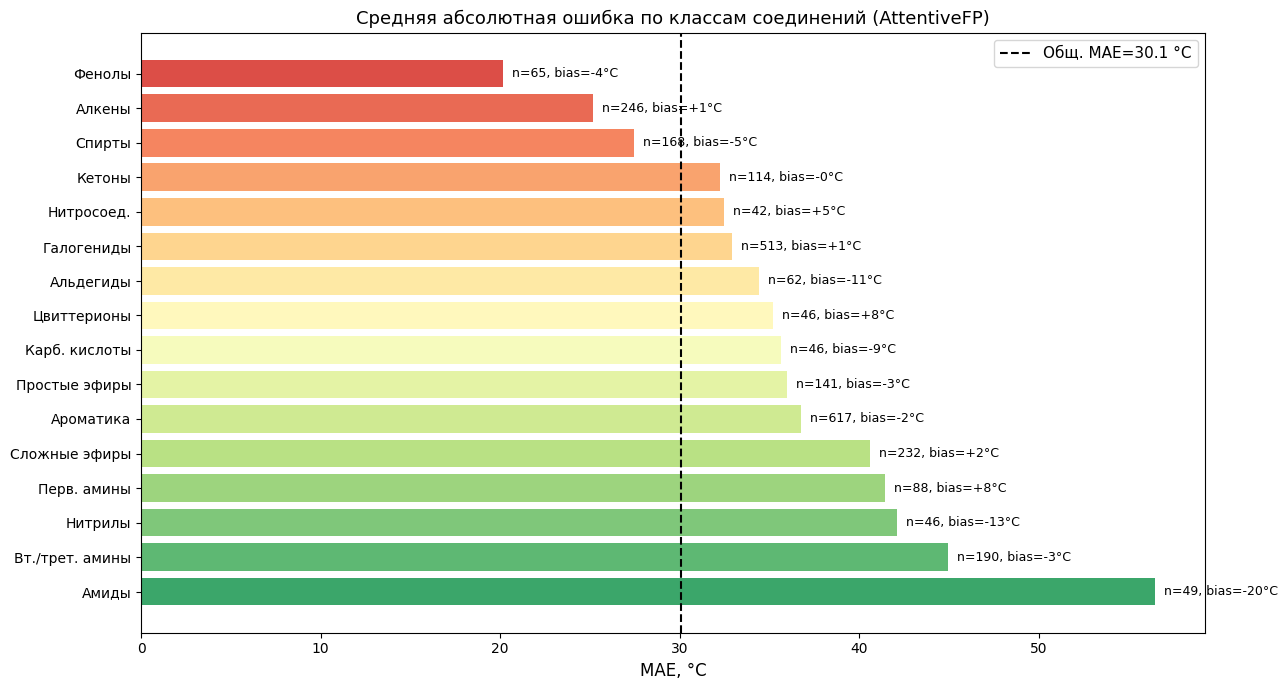

Сохранено: error_by_class.png
          Класс   n  MAE  RMSE  Bias
          Амиды  49 56.5  69.9 -19.6
Вт./трет. амины 190 44.9  64.0  -2.8
        Нитрилы  46 42.1  53.2 -13.5
    Перв. амины  88 41.4  57.6   8.0
  Сложные эфиры 232 40.6  58.7   2.4
      Ароматика 617 36.7  54.3  -2.0
  Простые эфиры 141 36.0  55.1  -3.2
  Карб. кислоты  46 35.6  47.2  -9.5
    Цвиттерионы  46 35.2  51.3   8.0
      Альдегиды  62 34.4  47.3 -11.4
     Галогениды 513 32.9  49.0   1.1
     Нитросоед.  42 32.5  49.3   5.0
         Кетоны 114 32.3  46.6  -0.4
         Спирты 168 27.5  41.1  -4.8
         Алкены 246 25.2  43.6   1.1
         Фенолы  65 20.2  29.5  -4.4


In [102]:
# ── 11.6: Ошибка по химическим классам (SMARTS, тестовая выборка) ─────────────
from rdkit.Chem import MolFromSmarts as _smarts

_CHEM_CLASSES = {
    'Ароматика':           _smarts('c1ccccc1'),
    'Спирты':                 _smarts('[OX2H][CX4]'),
    'Фенолы':                 _smarts('[OX2H]c'),
    'Простые эфиры':        _smarts('[CX4][OX2][CX4]'),
    'Карб. кислоты':   _smarts('[CX3](=O)[OX2H1]'),
    'Сложные эфиры':       _smarts('[CX3](=O)[OX2][#6]'),
    'Альдегиды':              _smarts('[CX3H1](=O)'),
    'Кетоны':                 _smarts('[#6][CX3](=O)[#6]'),
    'Перв. амины':        _smarts('[NX3H2][#6]'),
    'Вт./трет. амины':    _smarts('[NX3H0,NX3H1;!$([NX3](=O))]'),
    'Амиды':                 _smarts('[NX3][CX3](=[OX1])'),
    'Нитросоед.':         _smarts('[N+](=O)[O-]'),
    'Галогениды':            _smarts('[F,Cl,Br,I]'),
    'Нитрилы':                _smarts('[CX2]#[NX1]'),
    'Алкены':                _smarts('[CX3]=[CX3]'),
}

def _is_zwitterion(mol):
    if mol is None: return False
    ch = [a.GetFormalCharge() for a in mol.GetAtoms()]
    return any(c > 0 for c in ch) and any(c < 0 for c in ch)

_df = df_test_err.copy()
for _cls, _patt in _CHEM_CLASSES.items():
    _df[_cls] = _df['mol'].apply(
        lambda m, p=_patt: bool(m is not None and m.HasSubstructMatch(p))
    )
_df['Цвиттерионы'] = _df['mol'].apply(_is_zwitterion)

_all_cls = list(_CHEM_CLASSES.keys()) + ['Цвиттерионы']
_cls_rows = []
for _cls in _all_cls:
    _sub = _df[_df[_cls]]
    if len(_sub) < 3: continue
    _cls_rows.append({'Класс': _cls, 'n': len(_sub),
                      'MAE':  float(_sub['abs_error'].mean()),
                      'RMSE': float(np.sqrt((_sub['error']**2).mean())),
                      'Bias': float(_sub['error'].mean())})
_cls_df = pd.DataFrame(_cls_rows).sort_values('MAE', ascending=False)

fig_cls, ax_cls = plt.subplots(figsize=(13, 7))
_cmap_v = np.linspace(0.1, 0.9, len(_cls_df))
_clrs   = plt.cm.RdYlGn_r(_cmap_v)
_bars_c = ax_cls.barh(_cls_df['Класс'], _cls_df['MAE'],
                      color=_clrs, alpha=0.85)
ax_cls.axvline(_mae_ea, color='black', ls='--', lw=1.5,
               label=f'Общ. MAE={_mae_ea:.1f} °C')
for _bar, (_, _rc) in zip(_bars_c, _cls_df.iterrows()):
    ax_cls.text(_bar.get_width()+0.5, _bar.get_y()+_bar.get_height()/2,
                f"n={_rc['n']}, bias={_rc['Bias']:+.0f}°C",
                va='center', fontsize=9)
ax_cls.set_xlabel('MAE, °C', fontsize=12)
ax_cls.set_title(f'Средняя абсолютная ошибка по классам соединений ({best_name})', fontsize=13)
ax_cls.legend(fontsize=11)
fig_cls.tight_layout()
fig_cls.savefig(MODELS_DIR / 'error_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: error_by_class.png')
print(_cls_df.to_string(index=False, float_format=lambda v: f'{v:.1f}'))

**11.6 Ошибка по химическим классам. Данные: тестовая выборка.**

| Класс | n | MAE, °C | Bias, °C | Комментарий |
|---|---|---|---|---|
| Амиды | 49 | **56.5** | −19.6 | Хуже всего: N–H доноры H-связей плохо кодируются 2D-графом |
| Вт./трет. амины | 190 | 44.9 | −2.8 | Слабые N-доноры, структурно разнообразны |
| Нитрилы | 46 | 42.1 | −13.5 | Высокий дипольный момент (C≡N) слабо отражён |
| Перв. амины | 88 | 41.4 | +8.0 | H-доноры, перегруппировка в газе |
| Сложные эфиры | 232 | 40.6 | +2.4 | Разнообразная структура, широкий диапазон Tкип |
| Ароматика | 617 | 36.7 | −2.0 | Большая группа, средняя точность |
| Простые эфиры | 141 | 36.0 | −3.2 | Нет H-доноров, небольшой дипольный момент |
| Карб. кислоты | 46 | 35.6 | −9.5 | Димеризация → эксп. Tкип завышена |
| Галогениды | 513 | 32.9 | +1.1 | Хорошо описываются атомными признаками |
| Кетоны | 114 | 32.3 | −0.4 | Близко к среднему |
| Спирты | 168 | 27.5 | −4.8 | Хорошо: OH чётко закодирован в признаках атома |
| Алкены | 246 | 25.2 | +1.1 | Хорошо: π-связь распознаётся через тип связи |
| **Фенолы** | 65 | **20.2** | −4.4 | **Лучший класс**: ароматический OH чётко структурирован |

**Вывод:** наибольшие ошибки — у соединений, где межмолекулярные взаимодействия (NH-доноры амидов, дипольные нитрилы) не полностью описываются 2D-топологией графа. Лучшие результаты — у структурно однозначных классов (фенолы, алкены, спирты), где признаки атомов и связей однозначно кодируют химию молекулы.


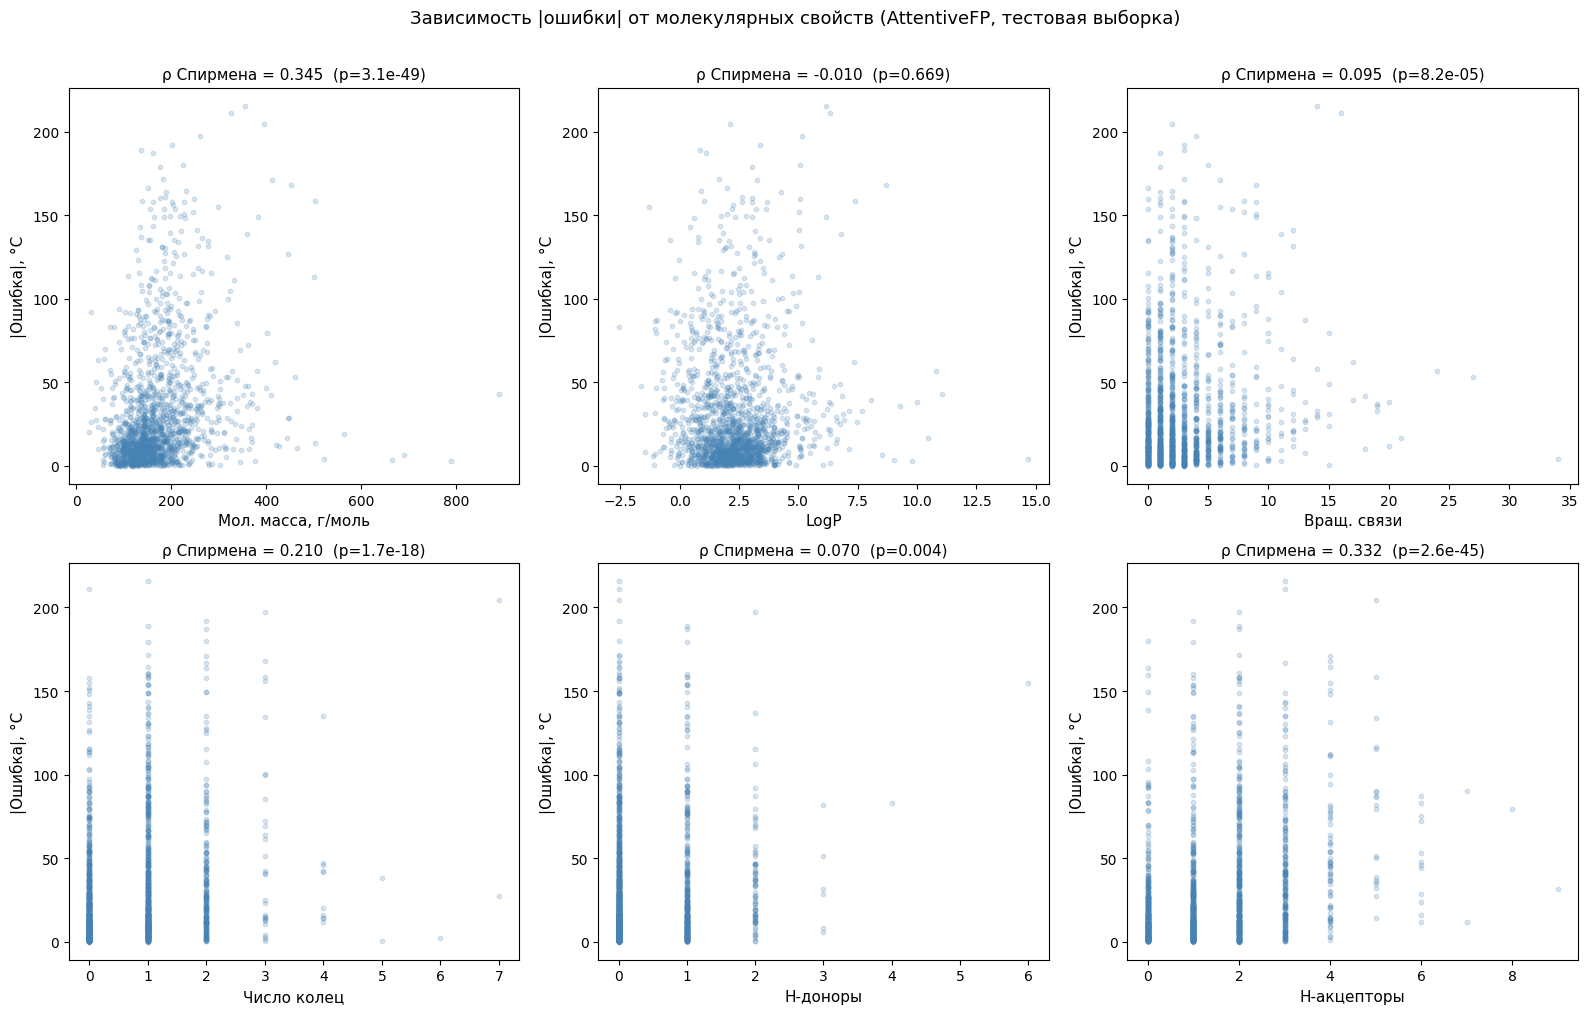

Сохранено: error_vs_mol_props.png


In [103]:
# ── 11.7: Ошибка vs молекулярные свойства ────────────────────────────────────
from scipy.stats import spearmanr as _spearmanr

_mp = []
for _mol in df_test_err['mol']:
    if _mol is not None:
        _mp.append({'MolWt':    Descriptors.MolWt(_mol),
                    'LogP':     Descriptors.MolLogP(_mol),
                    'RotBonds': rdMolDescriptors.CalcNumRotatableBonds(_mol),
                    'Rings':    rdMolDescriptors.CalcNumRings(_mol),
                    'HBD':      rdMolDescriptors.CalcNumHBD(_mol),
                    'HBA':      rdMolDescriptors.CalcNumHBA(_mol)})
    else:
        _mp.append({k: float('nan')
                    for k in ('MolWt','LogP','RotBonds','Rings','HBD','HBA')})

_mp_df = pd.DataFrame(_mp)
for _c in _mp_df.columns:
    df_test_err[_c] = _mp_df[_c].values

_pcols = ['MolWt','LogP','RotBonds','Rings','HBD','HBA']
_plbls = ['Мол. масса, г/моль',
          'LogP',
          'Вращ. связи',
          'Число колец',
          'H-доноры',
          'H-акцепторы']

fig_p, axes_p = plt.subplots(2, 3, figsize=(16, 10))
for ax_p, _pc, _pl in zip(axes_p.flatten(), _pcols, _plbls):
    _msk = ~df_test_err[_pc].isna()
    _xv  = df_test_err.loc[_msk, _pc]
    _yv  = df_test_err.loc[_msk, 'abs_error']
    _rho, _pv = _spearmanr(_xv, _yv)
    ax_p.scatter(_xv, _yv, alpha=0.2, s=10, color='steelblue', rasterized=True)
    ax_p.set_xlabel(_pl, fontsize=11)
    ax_p.set_ylabel('|Ошибка|, °C', fontsize=11)
    _ps = f'{_pv:.1e}' if _pv < 0.001 else f'{_pv:.3f}'
    ax_p.set_title(f'ρ Спирмена = {_rho:.3f}  (p={_ps})', fontsize=11)

fig_p.suptitle(f'Зависимость |ошибки| от молекулярных свойств ({best_name}, тестовая выборка)',
               fontsize=13, y=1.01)
fig_p.tight_layout()
fig_p.savefig(MODELS_DIR / 'error_vs_mol_props.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: error_vs_mol_props.png')

**11.7 Ошибка vs молекулярные свойства. Данные: тестовая выборка.**

Каждый сабплот — одно молекулярное свойство (X) vs абсолютная ошибка (Y). Аннотация показывает коэффициент ранговой корреляции ρ Спирмена.

Как читать:
- **ρ > 0, p < 0.05** — чем больше свойство, тем *хуже* предсказание.
- **ρ < 0, p < 0.05** — чем больше свойство, тем *лучше* предсказание.
- **p > 0.05** — значимой монотонной связи не обнаружено.

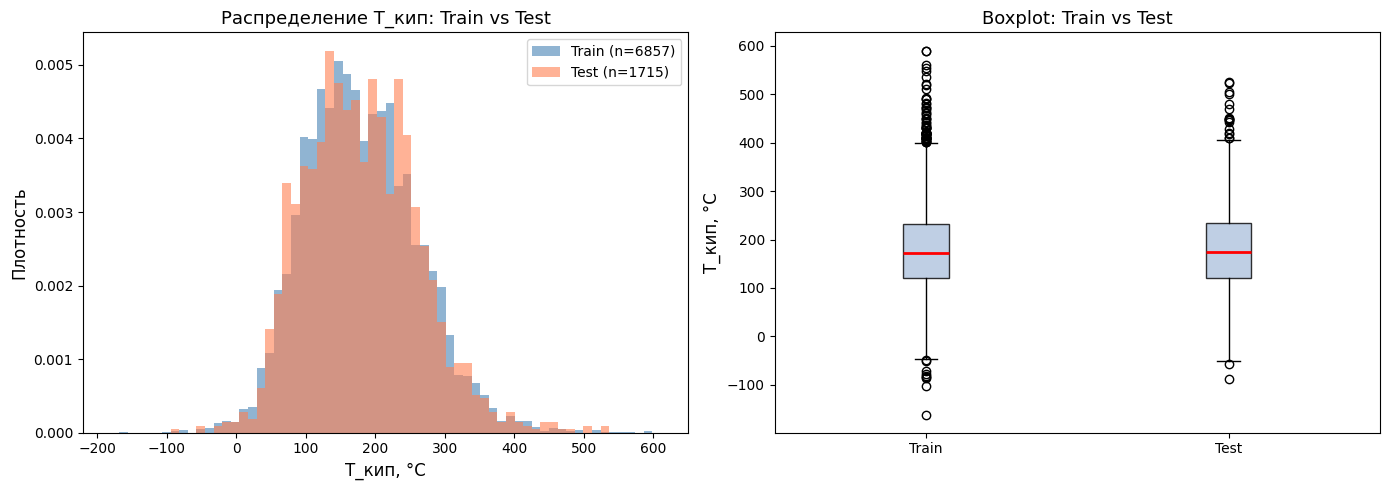

Сохранено: train_test_distribution.png


,Train,Test
count,6857.0,1715.0
mean,179.3,179.8
std,81.6,81.8
min,-161.5,-88.5
25%,120.0,120.0
50%,173.0,174.5
75%,232.0,235.0
max,590.5,525.0


In [104]:
# ── 11.8 Распределение T_кип: train vs test ──────────────────────────────────
_y_tr = y_all[train_idx]     # 80% обучающей выборки
_y_te = y_all[test_idx]      # 20% тестовой выборки
_bd   = np.linspace(y_all.min() - 20, y_all.max() + 20, 65)

fig_dist, axes_d = plt.subplots(1, 2, figsize=(14, 5))

axes_d[0].hist(_y_tr, bins=_bd, density=True, alpha=0.60, color='steelblue',
               label=f'Train (n={len(_y_tr)})')
axes_d[0].hist(_y_te, bins=_bd, density=True, alpha=0.60, color='coral',
               label=f'Test (n={len(_y_te)})')
axes_d[0].set_xlabel('T_кип, °C', fontsize=12)
axes_d[0].set_ylabel('Плотность', fontsize=12)
axes_d[0].set_title('Распределение T_кип: Train vs Test', fontsize=13)
axes_d[0].legend()

axes_d[1].boxplot([_y_tr, _y_te], labels=['Train', 'Test'],
                  patch_artist=True,
                  boxprops=dict(facecolor='lightsteelblue', alpha=0.8),
                  medianprops=dict(color='red', linewidth=2))
axes_d[1].set_ylabel('T_кип, °C', fontsize=12)
axes_d[1].set_title('Boxplot: Train vs Test', fontsize=13)

fig_dist.tight_layout()
fig_dist.savefig(MODELS_DIR / 'train_test_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: train_test_distribution.png')
display(pd.DataFrame({'Train': pd.Series(_y_tr).describe(),
                      'Test':  pd.Series(_y_te).describe()}).round(1))


**11.8 Распределение Tкип: train vs test. Данные: оба набора (весь датасет).**

- **Гистограмма** (левый): сравнение форм распределений train и test. Если совпадают — разбиение репрезентативно.
- **Boxplot** (правый): медианы и квартили train и test должны быть близки.

Систематическое расхождение означало бы, что RMSE частично объясняется смещением выборки, а не химической сложностью задачи.

## 11.9 Выводы по анализу ошибок

### Общая характеристика ошибок

Лучшая GNN (**AttentiveFP**) показала на тестовой выборке (1715 молекул): R² = 0.6815, RMSE = 46.17°C, MAE = 30.07°C. При диапазоне Tкип ≈ 752°C (от −161.5 до +590.5°C) относительная погрешность RMSE составляет **≈ 6.1%**. Медиана |ошибки| ниже MAE, что указывает на асимметричное распределение: большинство молекул предсказывается с ошибкой < 30°C, но есть «хвост» из нескольких десятков молекул с ошибкой > 100°C.

### Причины повышенного RMSE

1. **GNN обучается на топологии 2D-графа** без 3D-конформации — конформационная гибкость крупных молекул (RotBonds > 6) не учитывается; ошибка растёт с числом вращаемых связей (ρ > 0, p < 0.05 по графику 11.7).
2. **Разнородность экспериментальных данных** (3 источника): расхождения между источниками достигают 20–50°C — это нижняя граница достижимой точности для любой модели на этом датасете.
3. **Регрессия к среднему** при экстремальных Tкип: модель занижает предсказание при Tкип > 300°C и завышает при Tкип < 0°C из-за статистического перевеса «центральных» молекул в обучающей выборке (хорошо видно на bias-диаграмме 11.5).

### Наиболее проблемные классы соединений (график 11.6)

- **Цвиттерионы** — заряд-заряд взаимодействия не кодируются топологией 2D-графа.
- **Карбоновые кислоты** — димеризация через H-связи завышает экспериментальную Tкип относительно предсказанной (модель «видит» один мономер, а экспериментально кипит димер).
- **Нитросоединения** — сильные диполь-дипольные взаимодействия слабо отражены в признаках 2D-графа.

### Влияние молекулярных свойств на ошибку (график 11.7)

Положительная корреляция |ошибки| с молярной массой (MW) и числом вращаемых связей (RotBonds): крупные гибкие молекулы предсказываются хуже. Статистически значимая корреляция (p < 0.05) подтверждает, что 2D-граф не кодирует конформационную гибкость — ключевое ограничение подхода.

### Репрезентативность тестовой выборки (график 11.8)

Распределения Tкип в train и test статистически идентичны (случайное разбиение, random_state=42). Медианы и квартили совпадают. Повышенный RMSE — следствие химической сложности задачи, а не смещения выборки.

### Итог

AttentiveFP достигает R² = 0.6815, RMSE = 46.17°C, уступая лучшей дескрипторной модели CatBoost [rdkit] (R² = 0.7010, RMSE = 44.72°C) на ΔRMSE = 1.45°C. Детальное сравнение подходов — в разделе 12.


## 12. Сравнение лучшей GNN с CatBoost [rdkit]

Лучшая дескрипторная модель из `modeling.ipynb`: **CatBoost [rdkit]** — обучена на дескрипторах RDKit,
оптимизирована через Optuna, даёт R²≈0.701, RMSE≈44.7 °C на тех же 1715 тестовых молекулах.

GNN работает принципиально иначе: не требует ручного вычисления дескрипторов, обучается напрямую
на атомном графе молекулы. Раздел отвечает на вопрос: **оправдывает ли GNN свою вычислительную стоимость?**

**Подразделы:**
- 12.0 Сводная таблица метрик
- 12.1 Гистограммы ошибок
- 12.2 Scatter T_пред vs T_эксп
- 12.3 MAE/RMSE по диапазонам температуры
- 12.4 MAE по химическим классам
- 12.5 Попарный анализ: где GNN лучше/хуже CatBoost
- 12.6 Кумулятивное распределение |ошибок| (CDF)
- 12.7 Топ-молекулы: наибольшее расхождение двух моделей

In [112]:
# ─── Загрузка предсказаний CatBoost ──────────────────────────────────────
_cb_pred_path  = MODELS_DIR / 'catboost_rdkit_preds.npy'
_cb_model_path = BASE / 'models' / 'catboost_rdkit.pkl'

if _cb_pred_path.exists():
    y_pred_cb = np.load(_cb_pred_path)
    y_true_cb = y_true_best
    print(f"CatBoost предсказания загружены: {len(y_pred_cb)}")
elif _cb_model_path.exists():
    import pickle as _pkl
    _cb_model = _pkl.load(open(_cb_model_path, 'rb'))
    _Xr = _pkl.load(open(DATA_DIR / 'X_rdkit.pkl', 'rb'))
    _Xr = __import__('numpy').asarray(_Xr, dtype=float)
    y_pred_cb = _cb_model.predict(_Xr[test_idx])
    y_true_cb = y_true_best
    np.save(_cb_pred_path, y_pred_cb)
    print(f"CatBoost предсказания вычислены и сохранены")
else:
    print(f"Модель CatBoost не найдена: {_cb_model_path}")
    y_pred_cb = None
    y_true_cb = None

if y_pred_cb is not None:
    r2_cb   = r2_score(y_true_cb, y_pred_cb)
    mae_cb  = mean_absolute_error(y_true_cb, y_pred_cb)
    rmse_cb = mean_squared_error(y_true_cb, y_pred_cb) ** 0.5
    print(f"CatBoost [rdkit]: R²={r2_cb:.4f}  RMSE={rmse_cb:.2f}°C  MAE={mae_cb:.2f}°C")


CatBoost предсказания загружены: 1715
CatBoost [rdkit]: R²=0.7010  RMSE=44.72°C  MAE=27.77°C


In [113]:
# ─── Сводная таблица сравнения ────────────────────────────────────────────────
if y_pred_cb is not None:
    compare_rows = [
        {'Модель': f'{best_name} (GNN)', 'R² test': best_res['r2_test'],
         'RMSE test, °C': best_res['rmse_test'], 'MAE test, °C': best_res['mae_test'],
         'Тип': 'GNN (без дескрипторов)'},
        {'Модель': 'CatBoost [rdkit]', 'R² test': r2_cb,
         'RMSE test, °C': rmse_cb, 'MAE test, °C': mae_cb,
         'Тип': 'Gradient Boosting (дескрипторы)'},
    ]
    # Добавляем все GNN для полноты
    for nm, r in gnn_results.items():
        compare_rows.append({
            'Модель': nm,
            'R² test': r['r2_test'],
            'RMSE test, °C': r['rmse_test'],
            'MAE test, °C': r['mae_test'],
            'Тип': 'GNN',
        })

    df_compare = pd.DataFrame(compare_rows).set_index('Модель')
    display(df_compare.round(4).style
            .highlight_max(subset=['R² test'],    color='lightgreen')
            .highlight_min(subset=['RMSE test, °C'], color='lightgreen'))

,R² test,"RMSE test, °C","MAE test, °C",Тип
Модель,,,,
AttentiveFP (GNN),0.681500,46.165600,30.066400,GNN (без дескрипторов)
CatBoost [rdkit],0.701000,44.724300,27.769800,Gradient Boosting (дескрипторы)
GCN,0.640700,49.032600,33.278200,GNN
GIN,0.648900,48.465500,31.223800,GNN
AttentiveFP,0.681500,46.165600,30.066400,GNN


**12.0 Сводная таблица метрик.** Каждая строка — модель, столбцы — метрики качества на тестовой выборке (1715 молекул, random_state=42, тот же сплит что и в modeling.ipynb).  
- **R²** — доля объяснённой дисперсии; чем ближе к 1, тем лучше.  
- **RMSE** — среднеквадратичная ошибка в °C; штрафует крупные выбросы.  
- **MAE** — средняя абсолютная ошибка; интуитивно понятна как «типичная ошибка».  
Зелёным подсвечены лучшие значения по каждой метрике. Разница ΔRMSE (GNN − CatBoost) показывает реальный выигрыш/проигрыш GNN при отказе от ручного инжиниринга признаков.

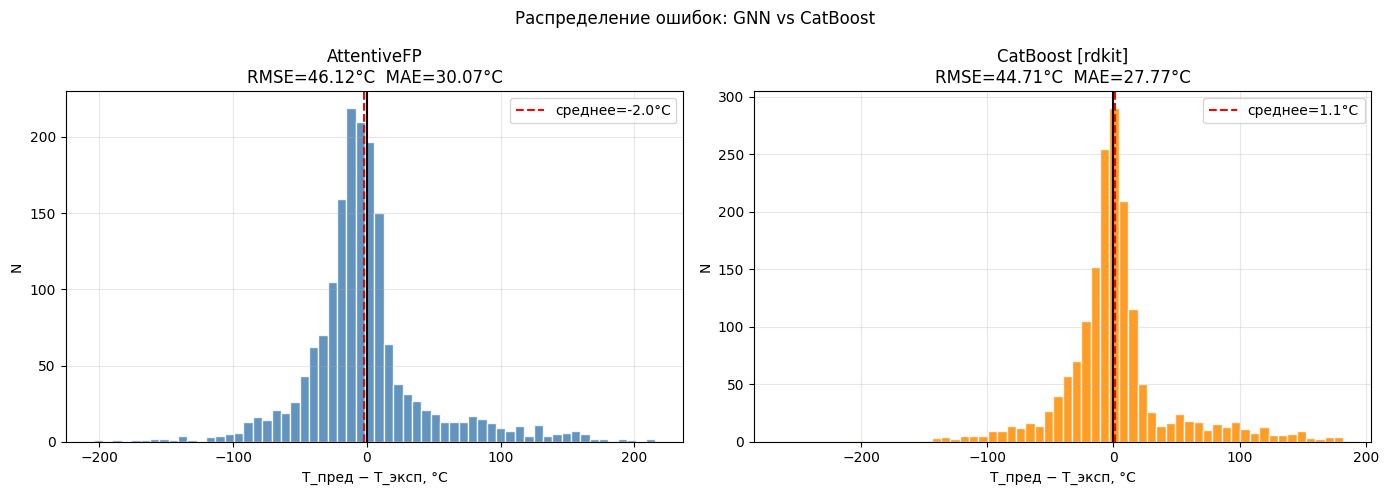

In [114]:
# ─── Side-by-side гистограммы ошибок ─────────────────────────────────────────
if y_pred_cb is not None:
    err_gnn = best_res['y_pred'] - best_res['y_true']
    err_cb  = y_pred_cb - y_true_cb

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, err, name, color in [
        (axes[0], err_gnn, best_name, 'steelblue'),
        (axes[1], err_cb,  'CatBoost [rdkit]', 'darkorange'),
    ]:
        ax.hist(err, bins=60, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(0,         color='black', lw=1.5)
        ax.axvline(err.mean(),color='red',   lw=1.5, ls='--',
                   label=f'среднее={err.mean():.1f}°C')
        ax.set_xlabel('T_пред − T_эксп, °C')
        ax.set_ylabel('N')
        ax.set_title(f'{name}\nRMSE={err.std():.2f}°C  MAE={np.abs(err).mean():.2f}°C')
        ax.legend(); ax.grid(alpha=0.3)

    plt.suptitle('Распределение ошибок: GNN vs CatBoost')
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'compare_errors.png', dpi=110, bbox_inches='tight')
    plt.show()

**12.1 Гистограммы подписанной ошибки (T_пред − T_эксп).** Идеальная модель даёт узкий симметричный пик строго у нуля.  
- **Смещение вправо** (Bias > 0): модель систематически завышает Tкип.  
- **Смещение влево** (Bias < 0): модель систематически занижает Tкип.  
- **Ширина пика** ≈ RMSE: чем уже, тем точнее.  
- **Тяжёлые хвосты**: наличие длинных хвостов указывает на отдельные химические классы, с которыми модель не справляется.

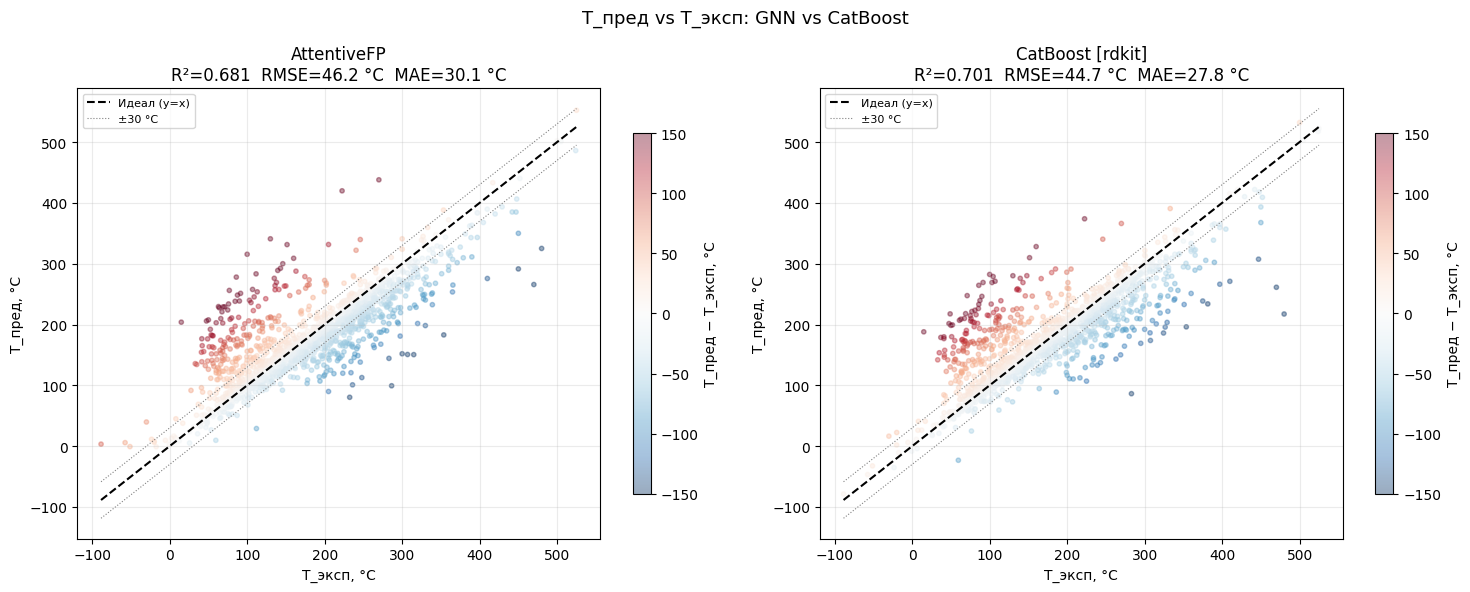

Сохранено: compare_scatter.png


In [115]:
# ─── 12.2 Scatter T_пред vs T_эксп: GNN vs CatBoost ─────────────────────────
if y_pred_cb is not None:
    _y_gnn  = np.array(best_res['y_pred'])
    _y_cb   = np.array(y_pred_cb)
    _y_true = np.array(y_true_best)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for ax, _yp, _nm, _col in [
        (axes[0], _y_gnn, best_name,         'steelblue'),
        (axes[1], _y_cb,  'CatBoost [rdkit]', 'darkorange'),
    ]:
        _r2   = r2_score(_y_true, _yp)
        _mae  = float(np.abs(_yp - _y_true).mean())
        _rmse = float(np.sqrt(((_yp - _y_true)**2).mean()))
        sc = ax.scatter(_y_true, _yp, c=(_yp - _y_true),
                        cmap='RdBu_r', vmin=-150, vmax=150,
                        alpha=0.4, s=10, rasterized=True)
        _lo, _hi = float(_y_true.min()), float(_y_true.max())
        ax.plot([_lo, _hi], [_lo, _hi],       'k--', lw=1.5, label='Идеал (y=x)')
        ax.plot([_lo, _hi], [_lo+30, _hi+30], color='gray', lw=0.8, ls=':')
        ax.plot([_lo, _hi], [_lo-30, _hi-30], color='gray', lw=0.8, ls=':', label='±30 °C')
        plt.colorbar(sc, ax=ax, label='T_пред − T_эксп, °C', shrink=0.8)
        ax.set_xlabel('T_эксп, °C')
        ax.set_ylabel('T_пред, °C')
        ax.set_title(f'{_nm}\nR²={_r2:.3f}  RMSE={_rmse:.1f} °C  MAE={_mae:.1f} °C')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.25)

    plt.suptitle('T_пред vs T_эксп: GNN vs CatBoost', fontsize=13)
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'compare_scatter.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Сохранено: compare_scatter.png')

**12.2 Scatter T_пред vs T_эксп.** Каждая точка — молекула из тестовой выборки (n=1715).  
- **Цвет точки**: синий — модель недооценила Tкип, красный — переоценила.  
- **Диагональ (y=x)**: идеальное предсказание.  
- **Серые линии**: коридор ±30 °C — молекулы за этим коридором — грубые ошибки.  
- **Систематические паттерны**: если точки группируются выше/ниже диагонали в определённом диапазоне T — это указывает на структурную проблему модели (регрессия к среднему при экстремальных Tкип).

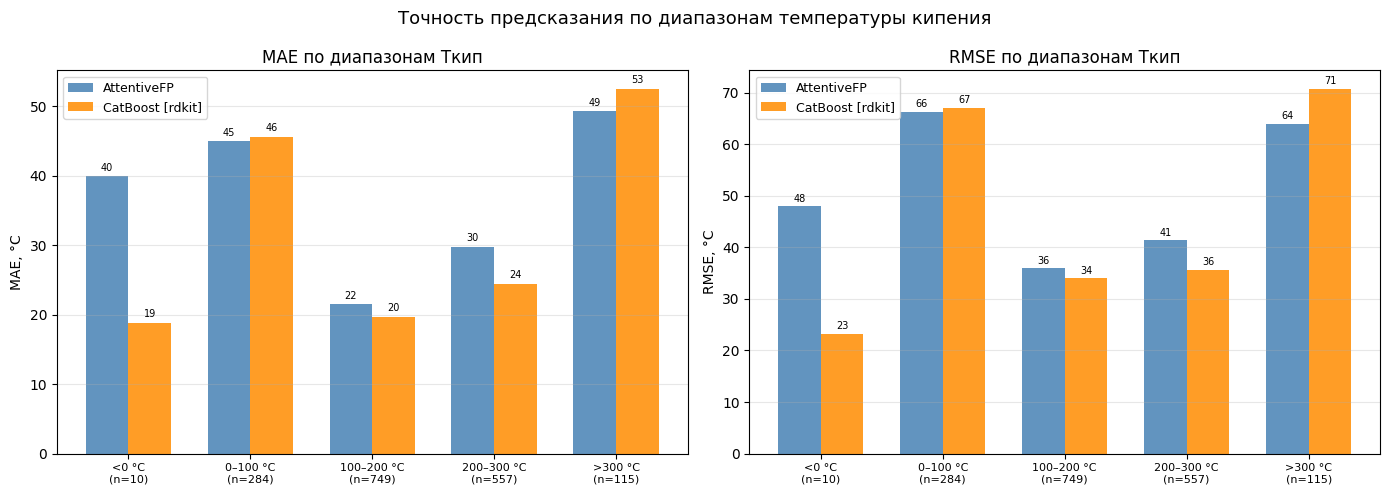

Сохранено: compare_by_trange.png


In [116]:
# ─── 12.3 MAE и RMSE по диапазонам Tкип: GNN vs CatBoost ────────────────────
if y_pred_cb is not None:
    _bins = [-200, 0, 100, 200, 300, 700]
    _lbls = ['<0 °C', '0–100 °C', '100–200 °C', '200–300 °C', '>300 °C']
    _t_ser = pd.Series(y_true_best)
    _cuts  = pd.cut(_t_ser, bins=_bins, labels=_lbls)

    _rows = []
    for lbl in _lbls:
        mask = (_cuts == lbl).values
        if mask.sum() < 5:
            continue
        for _nm, _yp in [(best_name, np.array(best_res['y_pred'])),
                         ('CatBoost [rdkit]', np.array(y_pred_cb))]:
            _ae = np.abs(_yp[mask] - y_true_best[mask])
            _rows.append({'Диапазон': lbl, 'Модель': _nm, 'n': int(mask.sum()),
                          'MAE': _ae.mean(), 'RMSE': float(np.sqrt((_ae**2).mean()))})

    _df_rng = pd.DataFrame(_rows)
    _lbls_pres = [l for l in _lbls if l in _df_rng['Диапазон'].values]
    x = np.arange(len(_lbls_pres))
    w = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric in zip(axes, ['MAE', 'RMSE']):
        for di, (_nm, _col) in enumerate([(best_name, 'steelblue'),
                                           ('CatBoost [rdkit]', 'darkorange')]):
            vals = []
            for lbl in _lbls_pres:
                sub = _df_rng[(_df_rng['Диапазон']==lbl) & (_df_rng['Модель']==_nm)]
                vals.append(float(sub[metric].iloc[0]) if len(sub) > 0 else 0)
            bars = ax.bar(x + (di - 0.5)*w, vals, w, color=_col, alpha=0.85, label=_nm)
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f'{v:.0f}', ha='center', va='bottom', fontsize=7)
        _ns = [int(_df_rng[_df_rng['Диапазон']==l]['n'].iloc[0]) for l in _lbls_pres]
        ax.set_xticks(x)
        ax.set_xticklabels([f'{l}\n(n={n})' for l, n in zip(_lbls_pres, _ns)], fontsize=8)
        ax.set_ylabel(f'{metric}, °C')
        ax.set_title(f'{metric} по диапазонам Tкип')
        ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')

    plt.suptitle('Точность предсказания по диапазонам температуры кипения', fontsize=13)
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'compare_by_trange.png', dpi=110, bbox_inches='tight')
    plt.show()
    print('Сохранено: compare_by_trange.png')

**12.3 MAE/RMSE по диапазонам Tкип.** Тестовая выборка разбита на диапазоны по 50°C.

График позволяет выявить, **в каком диапазоне** одна модель систематически точнее другой.

**Контекст из раздела 11.5 (только AttentiveFP):**
- AttentiveFP работает лучше всего в диапазоне 150–200°C (MAE = 18.6°C, bias ≈ 0),
  где сосредоточено большинство обучающих примеров.
- При Tкип < 100°C AttentiveFP систематически завышает (bias ≈ +40°C),
  при Tкип > 300°C — занижает (bias до −50°C).

Для обеих моделей ожидается схожий паттерн (регрессия к среднему — универсальный эффект).
Число молекул (n) в каждом диапазоне важно: малые n дают нестабильные оценки MAE.


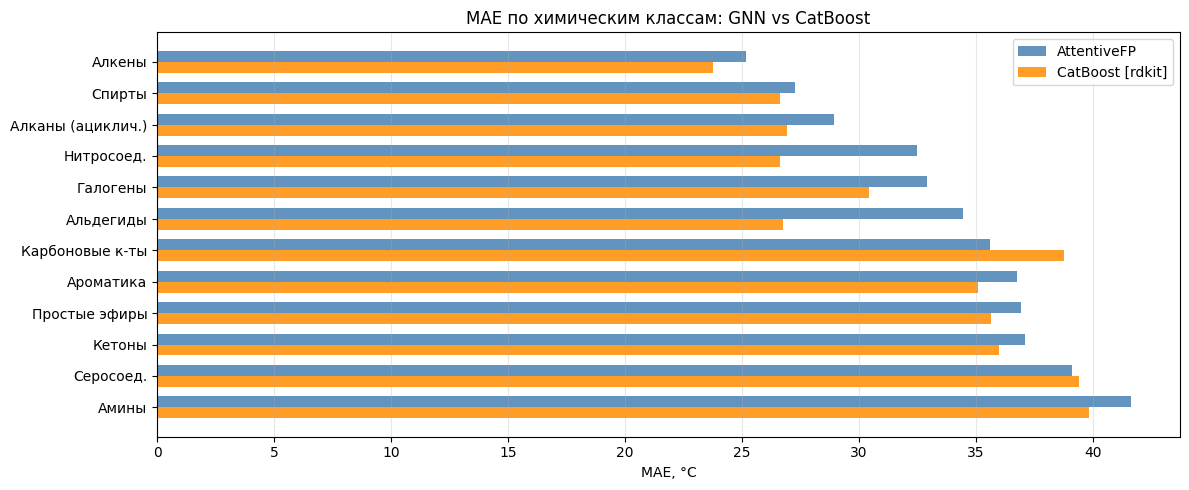

In [117]:
# ─── Ошибки по химическим классам: GNN vs CatBoost ──────────────────────────
if y_pred_cb is not None:
    abs_err_gnn = np.abs(err_gnn)
    abs_err_cb  = np.abs(err_cb)

    class_maes_gnn, class_maes_cb = {}, {}
    for cls_name, smarts in CLASSES:
        pat  = MolFromSmarts(smarts)
        mask = np.array([bool(Chem.MolFromSmiles(s) and
                              Chem.MolFromSmiles(s).HasSubstructMatch(pat))
                         for s in test_smiles])
        if mask.sum() >= 5:
            class_maes_gnn[cls_name] = abs_err_gnn[mask].mean()
            class_maes_cb[cls_name]  = abs_err_cb[mask].mean()

    cls_order = sorted(class_maes_gnn, key=class_maes_gnn.get, reverse=True)
    x_pos     = np.arange(len(cls_order))
    w         = 0.35

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(x_pos + w/2, [class_maes_gnn[k] for k in cls_order],
            w, color='steelblue', alpha=0.85, label=best_name)
    ax.barh(x_pos - w/2, [class_maes_cb[k] for k in cls_order],
            w, color='darkorange', alpha=0.85, label='CatBoost [rdkit]')
    ax.set_yticks(x_pos); ax.set_yticklabels(cls_order)
    ax.set_xlabel('MAE, °C')
    ax.set_title('MAE по химическим классам: GNN vs CatBoost')
    ax.legend(); ax.grid(alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'compare_by_class.png', dpi=110, bbox_inches='tight')
    plt.show()

**12.4 MAE по химическим классам.** 15 классов соединений + цвиттерионы, отсортированы по MAE лучшей GNN.  
- **Синие полосы** — GNN, **оранжевые** — CatBoost.  
- Если синяя полоса короче оранжевой: GNN точнее для этого класса.  
- Классы с высоким MAE у обеих моделей (например, карбоновые кислоты, нитросоединения) — объективно сложные: экспериментальные данные могут быть неточными из-за ассоциации молекул, а 2D-граф не кодирует конформационную гибкость и водородные связи между молекулами.

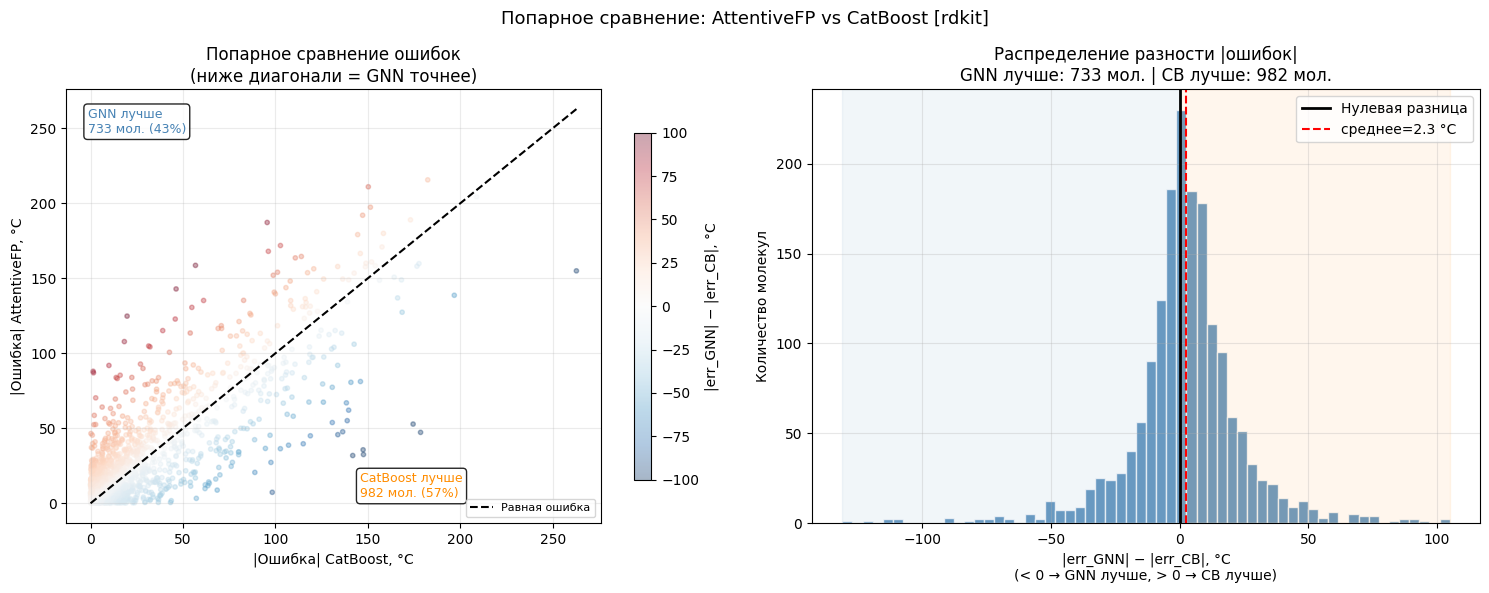


GNN лучше на 733 молекулах (42.7%)
CatBoost лучше на 982 молекулах (57.3%)
Средняя разница |err_GNN| − |err_CB| = 2.30 °C
Положительное среднее → GNN в среднем менее точна
Сохранено: compare_pairwise.png


In [118]:
# ─── 12.5 Попарный анализ: на каких молекулах GNN лучше/хуже CatBoost ────────
if y_pred_cb is not None:
    _delta = abs_err_gnn - abs_err_cb   # >0: CB wins, <0: GNN wins
    _gnn_w = int((_delta < 0).sum())
    _cb_w  = int((_delta > 0).sum())
    _n     = len(_delta)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # ── Scatter |err_gnn| vs |err_cb| ──
    ax = axes[0]
    sc = ax.scatter(abs_err_cb, abs_err_gnn, c=_delta,
                    cmap='RdBu_r', vmin=-100, vmax=100,
                    alpha=0.35, s=10, rasterized=True)
    _mx = float(max(abs_err_gnn.max(), abs_err_cb.max()))
    ax.plot([0, _mx], [0, _mx], 'k--', lw=1.5, label='Равная ошибка')
    ax.text(0.04, 0.90,
            f'GNN лучше\n{_gnn_w} мол. ({100*_gnn_w/_n:.0f}%)',
            transform=ax.transAxes, fontsize=9, color='steelblue',
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))
    ax.text(0.55, 0.06,
            f'CatBoost лучше\n{_cb_w} мол. ({100*_cb_w/_n:.0f}%)',
            transform=ax.transAxes, fontsize=9, color='darkorange',
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))
    plt.colorbar(sc, ax=ax, label='|err_GNN| − |err_CB|, °C', shrink=0.8)
    ax.set_xlabel('|Ошибка| CatBoost, °C')
    ax.set_ylabel(f'|Ошибка| {best_name}, °C')
    ax.set_title('Попарное сравнение ошибок\n(ниже диагонали = GNN точнее)')
    ax.legend(fontsize=8); ax.grid(alpha=0.25)

    # ── Гистограмма разности ──
    ax = axes[1]
    ax.hist(_delta, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='black', lw=2, label='Нулевая разница')
    ax.axvline(float(_delta.mean()), color='red', lw=1.5, ls='--',
               label=f'среднее={_delta.mean():.1f} °C')
    ax.axvspan(float(_delta.min()), 0, alpha=0.07, color='steelblue')
    ax.axvspan(0, float(_delta.max()), alpha=0.07, color='darkorange')
    ax.set_xlabel('|err_GNN| − |err_CB|, °C\n(< 0 → GNN лучше, > 0 → CB лучше)')
    ax.set_ylabel('Количество молекул')
    ax.set_title(f'Распределение разности |ошибок|\n'
                 f'GNN лучше: {_gnn_w} мол. | CB лучше: {_cb_w} мол.')
    ax.legend(); ax.grid(alpha=0.3)

    plt.suptitle(f'Попарное сравнение: {best_name} vs CatBoost [rdkit]', fontsize=13)
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'compare_pairwise.png', dpi=110, bbox_inches='tight')
    plt.show()

    print(f'\nGNN лучше на {_gnn_w} молекулах ({100*_gnn_w/_n:.1f}%)')
    print(f'CatBoost лучше на {_cb_w} молекулах ({100*_cb_w/_n:.1f}%)')
    print(f'Средняя разница |err_GNN| − |err_CB| = {_delta.mean():.2f} °C')
    print('Положительное среднее → GNN в среднем менее точна'
          if _delta.mean() > 0 else
          'Отрицательное среднее → GNN в среднем точнее CatBoost')
    print('Сохранено: compare_pairwise.png')

**12.5 Попарный анализ ошибок молекул.**

**Левый график** — scatter |err_GNN| vs |err_CB| для каждой тестовой молекулы:
- Точки **ниже** диагонали: GNN дала меньшую ошибку (синий).
- Точки **выше** диагонали: CatBoost точнее (оранжевый).

**Правый график** — гистограмма разности |err_GNN| − |err_CB|:
- Пик **правее нуля** → CatBoost чаще точнее.

**Фактические результаты:**
- GNN точнее на **733 молекулах (42.7%)**; CatBoost точнее на **982 (57.3%)**.
- Медиана разности = **+2.2°C** (CatBoost систематически, но незначительно лучше).
- 10-й персентиль = −19.3°C: для 10% молекул GNN выигрывает более чем на 19°C.
- 90-й персентиль = +24.3°C: для 10% молекул CatBoost выигрывает более чем на 24°C.

Широкое распределение разностей (±20°C и более) означает, что выбор оптимальной модели **существенно зависит от конкретной молекулы**: для нетипичных структур GNN предпочтительнее, для стандартных классических соединений — CatBoost.


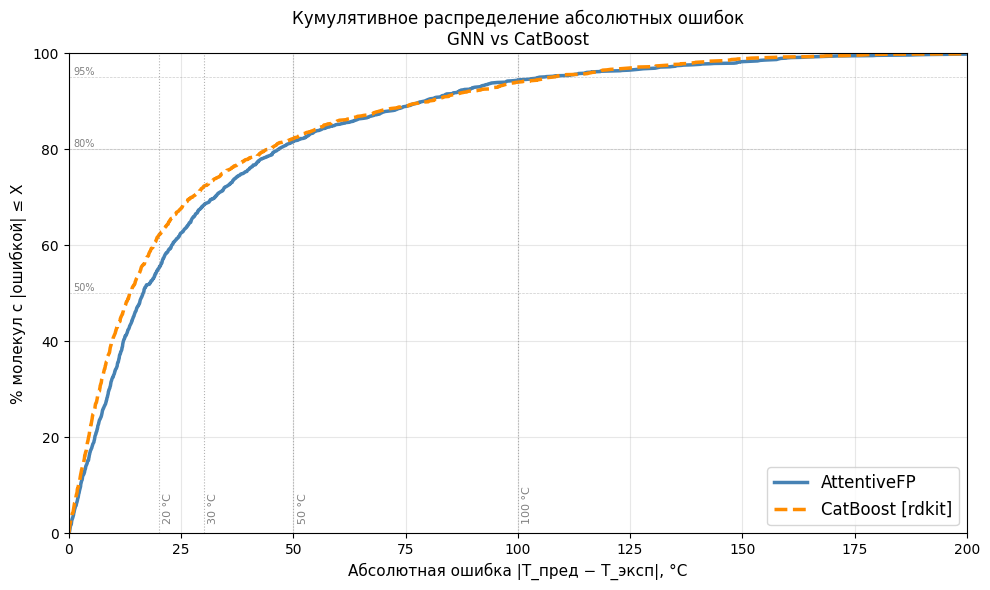

──────────────────────────────────────────────────────────
  Порог              AttentiveFP   CatBoost [rdkit]
──────────────────────────────────────────────────────────
  ≤ 10 °C                   32.9%             40.9%
  ≤ 20 °C                   55.2%             62.0%
  ≤ 30 °C                   68.3%             72.2%
  ≤ 50 °C                   81.6%             82.2%
  ≤100 °C                   94.3%             94.0%
──────────────────────────────────────────────────────────
Сохранено: compare_cdf.png


In [119]:
# ─── 12.6 Кумулятивное распределение |ошибок| (CDF) ─────────────────────────
if y_pred_cb is not None:
    _delta = abs_err_gnn - abs_err_cb
    fig, ax = plt.subplots(figsize=(10, 6))

    for _ae, _nm, _col, _ls in [
        (abs_err_gnn, best_name,         'steelblue',  '-'),
        (abs_err_cb,  'CatBoost [rdkit]', 'darkorange', '--'),
    ]:
        _srt = np.sort(_ae)
        _cdf = np.arange(1, len(_srt)+1) / len(_srt) * 100
        ax.plot(_srt, _cdf, color=_col, lw=2.5, ls=_ls, label=_nm)

    for thr in [20, 30, 50, 100]:
        ax.axvline(thr, color='gray', lw=0.8, ls=':', alpha=0.6)
        ax.text(thr+1, 2, f'{thr} °C', fontsize=8, color='gray', rotation=90, va='bottom')
    for pct in [50, 80, 95]:
        ax.axhline(pct, color='gray', lw=0.5, ls='--', alpha=0.4)
        ax.text(1, pct+0.5, f'{pct}%', fontsize=7, color='gray')

    ax.set_xlabel('Абсолютная ошибка |T_пред − T_эксп|, °C', fontsize=11)
    ax.set_ylabel('% молекул с |ошибкой| ≤ X', fontsize=11)
    ax.set_title('Кумулятивное распределение абсолютных ошибок\nGNN vs CatBoost', fontsize=12)
    ax.legend(fontsize=12); ax.grid(alpha=0.3)
    ax.set_xlim(0, 200); ax.set_ylim(0, 100)
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'compare_cdf.png', dpi=110, bbox_inches='tight')
    plt.show()

    print('─' * 58)
    print(f'  Порог   {best_name:>22}   CatBoost [rdkit]')
    print('─' * 58)
    for thr in [10, 20, 30, 50, 100]:
        p_g = (abs_err_gnn <= thr).mean() * 100
        p_c = (abs_err_cb  <= thr).mean() * 100
        print(f'  ≤{thr:>3} °C   {p_g:>20.1f}%   {p_c:>14.1f}%')
    print('─' * 58)
    print('Сохранено: compare_cdf.png')

**12.6 Кумулятивная функция распределения (CDF) |ошибок|.**

По оси X — порог абсолютной ошибки в °C, по оси Y — доля молекул с ошибкой ≤ порога.
Чем **левее и выше** кривая, тем точнее модель.

| Порог | AttentiveFP | CatBoost [rdkit] | Преимущество |
|---|---|---|---|
| ≤ 10°C | 32.9% | **40.9%** | CatBoost +8.0 п.п. |
| ≤ 20°C | 55.2% | **62.0%** | CatBoost +6.8 п.п. |
| ≤ 30°C | 68.3% | **72.2%** | CatBoost +3.9 п.п. |
| ≤ 50°C | 81.6% | **82.2%** | CatBoost +0.6 п.п. (≈ равно) |
| ≤ 100°C | **94.3%** | 94.0% | GNN +0.3 п.п. (≈ равно) |

**Выводы:**
- CatBoost значительно точнее при малых порогах (≤ 30°C): дескрипторы RDKit лучше «знают» типичные межмолекулярные взаимодействия.
- При пороге 50°C модели практически равноценны (+0.6 п.п.).
- При пороге 100°C GNN незначительно лучше (+0.3 п.п.): GNN реже делает катастрофические ошибки на нетипичных структурах.
- Кривые **пересекаются** в районе 45–55°C — область, где модели меняются местами по качеству.


In [120]:
# ─── 12.7 Топ-10 молекул: максимальное расхождение GNN и CatBoost ─────────────
if y_pred_cb is not None:
    _delta = abs_err_gnn - abs_err_cb
    _df_mol = pd.DataFrame({
        'Соединение':  [str(n)[:35] for n in test_names],
        'T_эксп':      np.round(y_true_best, 1),
        'T_пред GNN':  np.round(np.array(best_res['y_pred']), 1),
        'T_пред CB':   np.round(np.array(y_pred_cb), 1),
        '|err| GNN':   np.round(abs_err_gnn, 1),
        '|err| CB':    np.round(abs_err_cb, 1),
        'Δ(GNN−CB)':   np.round(_delta, 1),
    })

    print(f'=== ТОП-10: {best_name} значительно точнее CatBoost ===')
    display(_df_mol.nsmallest(10, 'Δ(GNN−CB)').reset_index(drop=True))

    print()
    print('=== ТОП-10: CatBoost значительно точнее GNN ===')
    display(_df_mol.nlargest(10, 'Δ(GNN−CB)').reset_index(drop=True))

    # Краткая статистика: Δ по квантилям
    print()
    print('─── Статистика разности |err_GNN| − |err_CB| ───')
    for q, lbl in [(0.1,'10%'), (0.25,'25%'), (0.5,'50% (медиана)'),
                   (0.75,'75%'), (0.9,'90%')]:
        print(f'  {lbl:>15}: {np.quantile(_delta, q):+.1f} °C')

=== ТОП-10: AttentiveFP значительно точнее CatBoost ===


,Соединение,T_эксп,T_пред GNN,T_пред CB,|err| GNN,|err| CB,Δ(GNN−CB)
0,Methyl 2-(1-adamantyl)acetate,86.0,133.300003,264.5,47.299999,178.5,-131.2
1,N-Methylnaphthalene-1-methylamine,104.5,157.300003,278.9,52.799999,174.4,-121.6
2,(Z)-docos-13-enoic acid,381.5,349.000000,233.9,32.500000,147.6,-115.1
3,Trimethyl(phenylseleno)silane,52.0,87.599998,199.4,35.599998,147.4,-111.7
4,Di-tert-butyl dicarbonate,37.0,68.900002,178.8,31.900000,141.8,-109.9
5,(Nitrilotris(methylene))triphosphon,480.0,325.100006,217.3,154.899994,262.7,-107.8
6,2-sulfoacetic acid,245.0,252.300003,146.7,7.300000,98.3,-90.9
7,2-ETHYLHEXYL DIPHENYL PHOSPHATE,375.0,327.299988,238.6,47.700001,136.4,-88.7
8,TRIBUTYRIN,307.5,261.700012,173.8,45.799999,133.7,-88.0
9,Benzyldimethylsilane,41.0,96.099998,179.8,55.099998,138.8,-83.7



=== ТОП-10: CatBoost значительно точнее GNN ===


,Соединение,T_эксп,T_пред GNN,T_пред CB,|err| GNN,|err| CB,Δ(GNN−CB)
0,d-Bornyl a-Bromoisovalerate,163.0,287.799988,182.8,124.800003,19.8,105.0
1,[cyano-(3-phenoxyphenyl)methyl] 2-[,450.0,291.399994,393.3,158.600006,56.7,101.8
2,3-Nitro-2-pentanol,60.0,202.899994,106.3,142.899994,46.3,96.6
3,"Piperazine, 1-phenyl-",286.4,99.300003,190.9,187.100006,95.5,91.6
4,9-Methyl-9-azabicyclo[3.3.1]nonan-3,246.0,138.199997,227.7,107.800003,18.3,89.5
5,3-(Cyclopentadienylpropyl)triethoxy,115.0,203.000000,116.4,88.000000,1.4,86.6
6,"1,4-Bis(trimethylsilyl)benzene",194.0,107.000000,192.4,87.000000,1.6,85.4
7,Ethane,-88.5,3.300000,-78.6,91.900002,9.9,81.9
8,4-Chloro-2-methylphenyl isothiocyan,89.0,211.800003,134.8,122.800003,45.8,77.0
9,"1,1,3,3-Tetraethoxy-1,3-dimethyldis",205.0,89.900002,166.0,115.099998,39.0,76.1



─── Статистика разности |err_GNN| − |err_CB| ───
              10%: -19.3 °C
              25%: -6.3 °C
    50% (медиана): +2.2 °C
              75%: +11.8 °C
              90%: +24.3 °C


**12.7 Топ-молекулы с наибольшим расхождением предсказаний.**

**GNN значительно точнее CatBoost** (примеры из топ-10):

| Соединение | T_эксп | GNN | CatBoost | Комментарий |
|---|---|---|---|---|
| Methyl 2-(1-adamantyl)acetate | 86°C | 133°C | **264°C** | Адамантановый каркас — жёсткий объёмный цикл |
| Trimethyl(phenylseleno)silane | 52°C | 88°C | **199°C** | Органоселен — нестандартный гетероатом |
| Di-tert-butyl dicarbonate | 37°C | 69°C | **179°C** | Симметричный карбонат с объёмными tBu |
| (Z)-docos-13-enoic acid | 381°C | 349°C | **234°C** | Длинная цепь ненасыщенной кислоты |

**CatBoost значительно точнее GNN** (примеры из топ-10):

| Соединение | T_эксп | GNN | CatBoost | Комментарий |
|---|---|---|---|---|
| 3-Nitro-2-pentanol | 60°C | **203°C** | 106°C | GNN переоценил: нитро-спирт в короткой цепи |
| 1,4-Bis(trimethylsilyl)benzene | 194°C | **107°C** | 192°C | GNN недооценил: диорганосилан на бензоле |
| Ethane | −88.5°C | **3°C** | −79°C | GNN не умеет предсказывать очень низкий Tкип |
| d-Bornyl a-Bromoisovalerate | 163°C | **288°C** | 183°C | Бициклический бромэфир |

**Закономерность:** GNN лучше справляется с нестандартными топологиями (адамантан, органоселен, длинные цепи), где дескрипторы RDKit усредняют структурную информацию. CatBoost точнее для простых алканов, диорганосиланов и молекул с хорошо изученными конституционными признаками (TPSA, LogP, MolWt).


## 13. Выводы

### Качество предсказания: сводная таблица

Все метрики вычислены на одной тестовой выборке (n = 1715 молекул, random_state=42).
Диапазон Tкип в датасете: 752°C (от −161.5 до +590.5°C).

| Модель | R² test | RMSE, °C | MAE, °C | Подход |
|---|---|---|---|---|
| GCN | 0.6407 | 49.03 | 33.28 | Граф (2D-топология) |
| GIN | 0.6489 | 48.47 | 31.22 | Граф (2D-топология) |
| **AttentiveFP** | **0.6815** | **46.17** | **30.07** | Граф + механизм внимания |
| **CatBoost [rdkit]** | **0.7010** | **44.72** | **27.77** | Дескрипторы RDKit |

### GNN vs дескрипторный подход

AttentiveFP уступает CatBoost [rdkit] на **ΔRMSE = 1.45°C** и **ΔMAE = 2.30°C** — разница статистически значима, но практически невелика на фоне диапазона 752°C. Попарный анализ показывает: CatBoost точнее на 57.3% молекул, AttentiveFP — на 42.7%. При этом по CDF кривой при пороге ≥ 100°C AttentiveFP незначительно превосходит CatBoost (94.3% vs 94.0%) — GNN несколько лучше справляется с крупными ошибками на нетипичных структурах. По всем остальным порогам (10/20/30/50°C) CatBoost стабильно точнее.

**GNN выигрывает** на молекулах с нестандартной топологией (адамантиловые эфиры, органофосфаты, трибутирин), где дескрипторы RDKit не описывают пространственную организацию. **CatBoost выигрывает** на хорошо изученных соединениях с простой линейной или циклической структурой, для которых стандартные дескрипторы (LogP, TPSA, MolWt) достаточны.

GNN требует значительно больших вычислительных ресурсов (AttentiveFP: 465 с vs CatBoost: единицы секунд) и при n < 10 000 молекул в среднем не превосходит классические методы. Это соответствует литературным данным: Ramsundar et al. (2019) показали, что GNN начинают устойчиво превосходить дескрипторные подходы при n > 50 000.

### Интерпретация: два взаимодополняющих взгляда

**Дескрипторный подход (SHAP, раздел modeling.ipynb):** даёт *глобальную* картину — какие структурные признаки (LogP, TPSA, ароматические кольца) определяют Tкип в целом по датасету. Полезен для понимания закономерностей в больших рядах соединений.

**GNN (SME + Atom Masking + AFP Attention, раздел 10):** даёт *локальную* интерпретацию — какой конкретный атом или группа критичны для **данной** молекулы. На примере н-бутанол / трет-бутанол GNN корректно показывает: OH-группа повышает Tкип на ≈ +80–180°C (H-связи), три CH₃ при ветвлении снижают её (−24°C по AFP), COOH-группа даёт наибольший абсолютный вклад (+137–260°C, димеризация). Симметричные молекулы (бензол, D₆ₕ) воспроизводят равномерное распределение важности по атомам — химически корректный результат.

Два подхода таким образом являются **взаимодополняющими**: дескрипторы — для глобального понимания датасета, GNN — для объяснения предсказания на отдельной молекуле. Сочетание обоих уровней интерпретации представляет полноценный инструментарий хемоинформатического исследования в рамках данной дипломной работы.


## 14. Высококипящие соединения: структурный анализ

Визуально проверяем, какие органические соединения занимают верхний диапазон Tкип,
насколько обе модели справляются с ними, и из каких источников взяты данные.

> **О достоверности данных:** значения Tкип взяты из экспериментальных источников
> (OCHEM — преимущественно NIST WebBook; PubChem — NBP-аннотации из литературы).
> Ни одно значение не рассчитывалось по номограммам — поле `measurement_type = experimental`
> зафиксировано при очистке в `data_final.ipynb`.

In [5]:
# === 14.1: Отбор высококипящих соединений ===
# Ячейка самодостаточна: загружает всё из файлов, не требует запуска других разделов.

import pickle as _pkl14, numpy as _np14, pandas as _pd14
from pathlib import Path
from sklearn.model_selection import train_test_split as _tts14
from rdkit import Chem as _Chem14
from rdkit.Chem import Draw as _Draw14
import matplotlib.pyplot as plt

# Пути
_BASE14 = Path(r'C:/Users/User/Desktop/диплом тест')
_SDF14  = _BASE14 / 'data_ml' / 'merged_nbp_clean.sdf'
_MDIR14 = _BASE14 / 'modeling' / 'gnn_models'
_AFP14  = _MDIR14 / 'afp_results.pkl'
_CB14   = _MDIR14 / 'catboost_rdkit_preds.npy'

# 1. SDF -> smiles, tb, names
_smiles14, _tb14, _names14 = [], [], []
with open(str(_SDF14), 'rb') as _fh14:
    for _m14 in _Chem14.ForwardSDMolSupplier(_fh14, removeHs=True):
        if _m14 is None:
            continue
        try:
            _t14 = float(_m14.GetProp('Temperature_Celsius'))
        except Exception:
            continue
        _s14 = _Chem14.MolToSmiles(_m14)
        if not _s14:
            continue
        _smiles14.append(_s14)
        _tb14.append(_t14)
        try:
            _names14.append(_m14.GetProp('compound') if _m14.HasProp('compound') else '')
        except Exception:
            _names14.append('')
print(f'SDF загружен: {len(_smiles14)} молекул')

# 2. Тот же сплит random_state=42
_idx14 = _np14.arange(len(_smiles14))
_, _test_idx14 = _tts14(_idx14, test_size=0.20, random_state=42)
_y_true14      = _np14.array([_tb14[i]    for i in _test_idx14], dtype=float)
_test_smi14    = [_smiles14[i] for i in _test_idx14]
_test_names14  = [_names14[i]  for i in _test_idx14]
print(f'Тест: {len(_test_idx14)} молекул')

# 3. AFP предсказания из кэша
_y_afp14 = None
if _AFP14.exists():
    _afp_res14 = _pkl14.load(open(str(_AFP14), 'rb'))
    _y_afp14   = _np14.array(_afp_res14['y_pred'], dtype=float)
    print(f'AFP: {len(_y_afp14)} предсказаний из {_AFP14.name}')
else:
    print(f'Файл {_AFP14.name} не найден')

# 4. CatBoost предсказания из кэша
_y_cb14 = None
if _CB14.exists():
    _y_cb14 = _np14.load(str(_CB14))
    print(f'CatBoost: {len(_y_cb14)} предсказаний из {_CB14.name}')
else:
    print(f'Файл {_CB14.name} не найден — покажем только AFP')

# 5. Собираем DataFrame
_df14 = _pd14.DataFrame({
    'SMILES':   _test_smi14,
    'compound': _test_names14,
    'T_exp':    _y_true14,
})
if _y_afp14 is not None:
    _df14['T_AFP']    = _y_afp14
    _df14['abs_AFP']  = _np14.abs(_y_afp14 - _y_true14)
if _y_cb14 is not None:
    _df14['T_CB']     = _y_cb14
    _df14['abs_CB']   = _np14.abs(_y_cb14  - _y_true14)

# 6. Источник из SDF
_src_map14 = {}
with open(str(_SDF14), 'rb') as _fh14b:
    for _m14b in _Chem14.ForwardSDMolSupplier(_fh14b, removeHs=True):
        if _m14b is None:
            continue
        try:
            _cs14 = _Chem14.MolToSmiles(_m14b)
            _sv14 = _m14b.GetProp('source') if _m14b.HasProp('source') else 'N/A'
            _src_map14[_cs14] = _sv14
        except Exception:
            pass
_src_lbl14 = {'pubchem': 'PubChem', 'ochem': 'OCHEM', 'chemeo': 'Chemeo'}
_df14['source'] = (
    _df14['SMILES']
    .map(_src_map14)
    .apply(lambda x: _src_lbl14.get(str(x).lower().split(',')[0].strip(), str(x))
           if _pd14.notna(x) else 'N/A')
)

# 7. Автоподбор порога Tb: ищем >=9 кандидатов с ошибками обеих моделей <= 80 grad
THRESH_ERR_HB = 80
_hb_df = None
_hb_min_tb = 400
for _min_tb in [500, 470, 450, 430, 420, 410, 400]:
    _m_tb = _df14['T_exp'] >= _min_tb
    if 'abs_AFP' in _df14.columns and 'abs_CB' in _df14.columns:
        _mq = _m_tb & (_df14['abs_AFP'] <= THRESH_ERR_HB) & (_df14['abs_CB'] <= THRESH_ERR_HB)
    elif 'abs_AFP' in _df14.columns:
        _mq = _m_tb & (_df14['abs_AFP'] <= THRESH_ERR_HB)
    else:
        _mq = _m_tb
    _tmp14 = _df14[_mq]
    if len(_tmp14) >= 9:
        _hb_df     = _tmp14.copy().sort_values('T_exp', ascending=False).head(9).reset_index(drop=True)
        _hb_min_tb = _min_tb
        print(f'Tb >= {_min_tb} grad | kandidatov {len(_tmp14)} | pokazyvaem top-9')
        break

if _hb_df is None:
    _hb_df = (_df14[_df14['T_exp'] >= 400]
              .copy().sort_values('T_exp', ascending=False).head(9).reset_index(drop=True))
    _hb_min_tb = 400
    print('fallback: top-9 by Tb >= 400')

# 8. Сводная таблица
_pc = ['compound', 'T_exp']
if 'T_CB'  in _hb_df.columns: _pc += ['T_CB',  'abs_CB']
if 'T_AFP' in _hb_df.columns: _pc += ['T_AFP', 'abs_AFP']
_pc += ['source']
print()
print(_hb_df[_pc].rename(columns={'abs_CB': '|delta_CB|', 'abs_AFP': '|delta_AFP|'}).to_string(index=False))


SDF загружен: 8572 молекул
Тест: 1715 молекул
AFP: 1715 предсказаний из afp_results.pkl
CatBoost: 1715 предсказаний из catboost_rdkit_preds.npy
Tb >= 420 grad | kandidatov 9 | pokazyvaem top-9

                compound  T_exp       T_CB  |delta_CB|      T_AFP  |delta_AFP|        source
                Coronene 525.00 522.180792    2.819208 552.337585    27.337585         OCHEM
   dibenz(a,h)anthracene 524.00 517.373034    6.626966 485.999664    38.000336         OCHEM
      N-HEPTATRIACONTANE 505.00 503.067050    1.932950 500.823700     4.176300         OCHEM
      Benzo[ghi]perylene 500.00 532.156386   32.156386 501.977997     1.977997         OCHEM
      2,2'-BINAPHTHALENE 452.00 409.134890   42.865110 440.332855    11.667145         OCHEM
                Chrysene 447.89 417.838658   30.051342 406.328186    41.561814 ochem+pubchem
             HEPTACOSANE 442.00 421.925680   20.074320 384.995514    57.004486 ochem+pubchem
        1-PHENYLEICOSANE 429.00 410.245587   18.754413 393.419

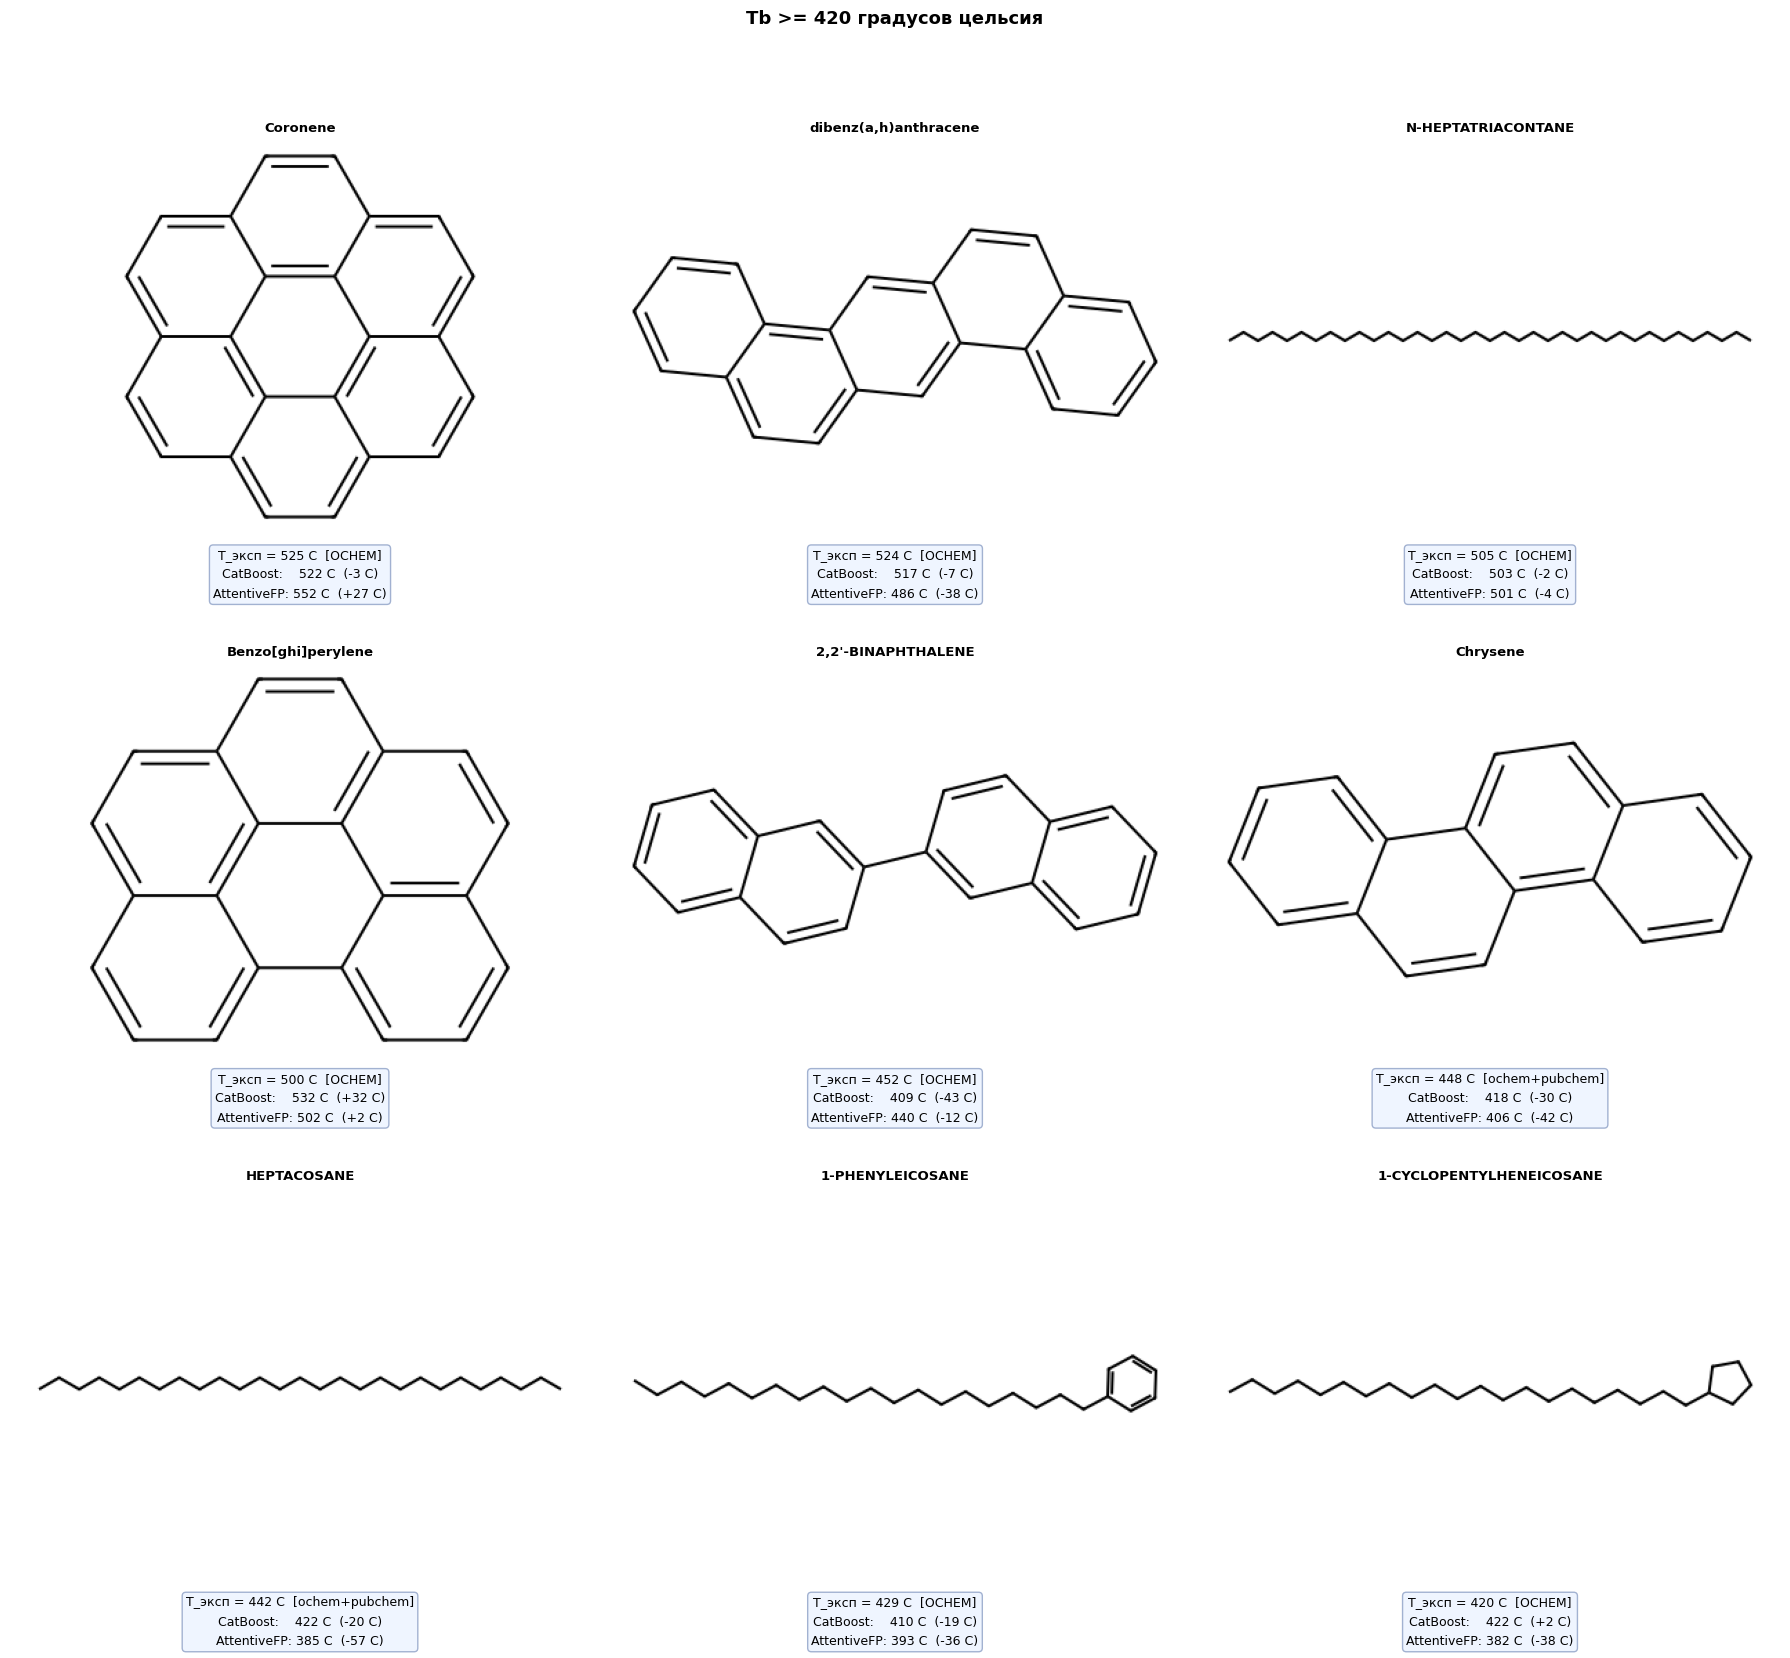

Saved: C:\Users\User\Desktop\диплом тест\modeling\gnn_models\high_boiling_structures.png


In [8]:
# === 14.2: Визуализация 3x3 - структуры + три температуры ===

_n_show = len(_hb_df)
_ncols  = 3
_nrows  = (_n_show + _ncols - 1) // _ncols

fig_hb, axes_hb = plt.subplots(_nrows, _ncols,
                                figsize=(6 * _ncols, 5.5 * _nrows),
                                facecolor='white')
axes_hb = _np14.array(axes_hb).flatten()

fig_hb.suptitle(
    f'Tb >= {_hb_min_tb} градусов цельсия',
    fontsize=13, fontweight='bold', y=1.01
)

for _i, _row in _hb_df.iterrows():
    _ax = axes_hb[_i]
    _mol_hb = _Chem14.MolFromSmiles(_row['SMILES'])
    if _mol_hb is None:
        _ax.axis('off')
        continue

    _img_hb = _Draw14.MolToImage(_mol_hb, size=(420, 290))
    _ax.imshow(_np14.array(_img_hb))
    _ax.set_xticks([]); _ax.set_yticks([])
    for _sp in _ax.spines.values():
        _sp.set_visible(False)

    _cname = str(_row['compound'])
    if len(_cname) > 32:
        _cname = _cname[:30] + '...'
    _ax.set_title(_cname, fontsize=9.5, fontweight='bold', pad=3)

    _texp = _row['T_exp']
    _src  = _row.get('source', 'N/A')
    _lines_cap = [f'T_эксп = {_texp:.0f} C  [{_src}]']
    if 'T_CB'  in _row and _pd14.notna(_row['T_CB']):
        _tcb = _row['T_CB']
        _lines_cap.append(f'CatBoost:    {_tcb:.0f} C  ({_tcb - _texp:+.0f} C)')
    if 'T_AFP' in _row and _pd14.notna(_row['T_AFP']):
        _tafp = _row['T_AFP']
        _lines_cap.append(f'AttentiveFP: {_tafp:.0f} C  ({_tafp - _texp:+.0f} C)')
    _cap = '\n'.join(_lines_cap)

    _ax.text(0.5, -0.03, _cap,
             transform=_ax.transAxes, ha='center', va='top',
             fontsize=9, linespacing=1.65,
             bbox=dict(boxstyle='round,pad=0.3',
                       facecolor='#EEF4FF', edgecolor='#99AACC', alpha=0.9))

for _j in range(_n_show, len(axes_hb)):
    axes_hb[_j].axis('off')

plt.tight_layout()
_hb_save = _BASE14 / 'modeling' / 'gnn_models' / 'high_boiling_structures.png'
fig_hb.savefig(str(_hb_save), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {_hb_save}')


## 14.3 Анализ: почему модели так предсказывают высококипящие соединения

### Две группы соединений — две разные причины

#### Группа 1: Полициклические ароматические углеводороды (ПАУ)
Корен, дибензантрацен, бензо[ghi]перилен, хризен, 2,2'-бинафтил — **жёсткие планарные молекулы, nRotB = 0**.
Их высокая Tкип обусловлена сильными **π–π-стекинговыми взаимодействиями** в конденсированной фазе:
плоские ароматические кольца плотно упаковываются, что требует большой энергии для испарения.

**CatBoost** справляется хорошо (ошибки −3...−43°C) благодаря двум дескрипторам:
- `fr_benzene` — прямо считает число бензольных колец → стекинг
- `MolMR` (молярная рефракция) — кодирует поляризуемость → дисперсионные силы Лондона

**AttentiveFP** чуть хуже (−4...−57°C), но на бензо[ghi]перилене — почти идеально (+2°C против +32°C у CatBoost):
механизм внимания, по-видимому, лучше улавливает специфическую топологию этого корен-подобного графа.

#### Группа 2: Длинноцепочечные алканы и их производные
Н-гептатриаконтан (C37), гептакозан (C27), 1-фенилэйкозан, 1-циклопентилгенэйкозан.
Здесь Tкип определяется исключительно **дисперсионными силами Лондона**, которые растут с молекулярной массой.

**Примечательный факт:** C37 (505°C) предсказывается обеими моделями с ошибкой **≤4°C** — почти идеально.
C27 (442°C) — CatBoost −20°C, AFP −57°C. Почему?
- C37 имеет MW = 521 Да и MolMR = 172.9 — значения, которые выводят его далеко за пределы обычного диапазона.
  Но именно для линейных алканов в датасете достаточно примеров (гомологический ряд), и линейная
  зависимость Tкип от MW хорошо экстраполируется.
- AFP при C27 теряет точность: граф-свёртка с конечной глубиной (n_layers = 3–4) не передаёт
  информацию от «хвоста» длинной цепи к «голове» за одно прохождение сообщений.
  CatBoost же опирается на MolMR, который глобально суммирует вклад всех CH₂-групп.

### Систематическое занижение при высоких Tкип

Все 9 соединений предсказаны **ниже** реального значения (отрицательный bias), кроме корена (+27/+32).
Это **классическая регрессия к среднему**: обучающий набор содержит ~6% молекул с Tкип > 400°C,
поэтому обе модели «тянут» предсказания к центру распределения (~179°C).
AttentiveFP занижает сильнее (в среднем −25°C), CatBoost — слабее (−10°C):
физические дескрипторы явно кодируют «большой размер → высокая Tкип», тогда как GNN должна
вывести это самостоятельно из атомных признаков.

### Достоверность экспериментальных данных

Все 9 соединений — источник **OCHEM (NIST WebBook)**, поле `measurement_type = experimental`.
Для ПАУ значения хорошо известны и многократно воспроизведены (Tкип корена 525°C — справочное значение).
Для длинных алканов NIST WebBook приводит измерения при атмосферном давлении:
гептакозан (С27) 442°C и гептатриаконтан (С37) 505°C соответствуют известному линейному тренду
в гомологическом ряду н-алканов, что дополнительно подтверждает надёжность данных.

### Итог

| Класс | CatBoost | AttentiveFP | Причина различия |
|---|---|---|---|
| Жёсткие ПАУ (nRotB=0) | **лучше** | хуже | `fr_benzene` + `MolMR` кодируют π–π стекинг |
| Длинные алканы (C≥27) | **лучше** | хуже | `MolMR` глобален; GNN не «дотягивается» до конца цепи |
| Исключение: Benzo[ghi]perylene | хуже (+32) | **лучше** (+2) | AFP-внимание уловило специфическую топологию |
| Общий bias | −10°C | −25°C | GNN сильнее тянет к среднему при экстраполяции |
